# Project: Energy & Development

## Research Question

What is the impact of investment, nonrenewable energy consumption, access to electricity, and electricity demand on renewable energy consumption?

### Data

### Variables

## Data Cleaning

### Imports, cleans, and merges World Development Indicators with Our World in Data.

In [70]:
# Import pandas library
import pandas as pd

# Read the WDI and OWID CSV files
wdi = pd.read_csv('data1/WDI.csv.csv')
owid = pd.read_csv('data1/OWID.csv.csv')

# Filter the OWID data for the years 2016 to 2020
owid = owid[owid["year"].isin([2016, 2017, 2018, 2019, 2020])]

# Rename the OWID columns to match the WDI columns
owid = owid.rename(columns={"country": "Country Name", "iso_code": "Country Code", "year": "Time"})

# Merge the WDI and OWID data on the common columns
merged = pd.merge(wdi, owid[["Country Name", "Country Code", "Time", "electricity_demand", "energy_per_capita", "renewables_energy_per_capita"]], on=["Country Name", "Country Code", "Time"], how="left")

# Name the merged dataset as Development_raw
Development_raw = merged

# Replace the '..' inputs with ''
Development_raw = Development_raw.replace('..', '')

# Convert the Development_raw dataset into a CSV file
Development_raw.to_csv("data1/Development_raw.csv", index=False)

# Print the first 5 rows of the Development_raw dataset
print(Development_raw.head())

  Country Name Country Code    Time Time Code  \
0  Afghanistan          AFG  2016.0    YR2016   
1  Afghanistan          AFG  2017.0    YR2017   
2  Afghanistan          AFG  2018.0    YR2018   
3  Afghanistan          AFG  2019.0    YR2019   
4  Afghanistan          AFG  2020.0    YR2020   

  Gross fixed capital formation (current US$) [NE.GDI.FTOT.CD]  \
0                                                                
1                                                                
2                                                                
3                                                                
4                                                                

  Access to electricity (% of population) [EG.ELC.ACCS.ZS]  \
0                                               97.7         
1                                               97.7         
2                                        93.43087769         
3                                               97.7        

### Cleans, preprocesses, and saves Development_raw data as Development_clean CSV

In [71]:
# Import pandas library
import pandas as pd

# Read the Development_raw CSV file
Development_raw = pd.read_csv("data1/Development_raw.csv")

# Drop the Time Code and Country Code columns from the dataset
Development_raw = Development_raw.drop(["Time Code", "Country Code"], axis=1)

# Name the modified dataset as Development_clean
Development_clean = Development_raw

# Convert the Development_clean dataset into a CSV file
Development_clean.to_csv("data1/### Cleans, preprocesses, and saves Development_raw data as Development_clean CSVDevelopment_clean.csv", index=False)

# Print the first 5 rows of the Development_clean dataset
print(Development_clean.head())

  Country Name    Time  \
0  Afghanistan  2016.0   
1  Afghanistan  2017.0   
2  Afghanistan  2018.0   
3  Afghanistan  2019.0   
4  Afghanistan  2020.0   

   Gross fixed capital formation (current US$) [NE.GDI.FTOT.CD]  \
0                                                NaN              
1                                                NaN              
2                                                NaN              
3                                                NaN              
4                                                NaN              

   Access to electricity (% of population) [EG.ELC.ACCS.ZS]  \
0                                          97.700000          
1                                          97.700000          
2                                          93.430878          
3                                          97.700000          
4                                          97.700000          

   Trade (% of GDP) [NE.TRD.GNFS.ZS]  \
0                    

### Calculates country mean sand saves as Development_clean CSV

In [72]:
Development_mean = Development_clean
# Replace the NaN inputs with 0
Development_mean = Development_mean.dropna()
Development_mean.head()
# Chain the operations to find the average for each variable for each country
Development_mean = (
    Development_clean.groupby(["Country Name"], as_index=False)
    .mean()
    .drop(0)
    .reset_index(drop=True)
)

# Convert the 'Development_mean' dataset into a CSV file
Development_mean.to_csv("data1/Development_clean.csv", index=False)

# Print the first 5 rows of the 'Development_mean' dataset
print(Development_mean.head())

     Country Name    Time  \
0         Albania  2018.0   
1         Algeria  2018.0   
2  American Samoa  2018.0   
3         Andorra  2018.0   
4          Angola  2018.0   

   Gross fixed capital formation (current US$) [NE.GDI.FTOT.CD]  \
0                                       3.315557e+09              
1                                       6.613429e+10              
2                                                NaN              
3                                                NaN              
4                                       1.284342e+10              

   Access to electricity (% of population) [EG.ELC.ACCS.ZS]  \
0                                          99.956000          
1                                          99.564046          
2                                                NaN          
3                                         100.000000          
4                                          44.514120          

   Trade (% of GDP) [NE.TRD.GNFS.ZS]  \
0  

### Renames variables and saves the modified dataset as Development_clean CSV

In [73]:
# Rename the variables as follows
Development_clean = Development_clean.rename(columns={
    "Country Name": "Country",
    "Time": "Year",
    "Gross fixed capital formation (current US$) [NE.GDI.FTOT.CD]": "GFCF",
    "Access to electricity (% of population) [EG.ELC.ACCS.ZS]": "AE",
    "Trade (% of GDP) [NE.TRD.GNFS.ZS]": "TRD",
    "Broad money (% of GDP) [FM.LBL.BMNY.GD.ZS]": "BM",
    "Foreign direct investment, net inflows (% of GDP) [BX.KLT.DINV.WD.GD.ZS]": "FDI",
    "GDP per capita (current US$) [NY.GDP.PCAP.CD]": "GDP_pc",
    "Population, total [SP.POP.TOTL]": "POP",
    "electricity_demand": "ED",
    "energy_per_capita": "E_pc",
    "renewables_energy_per_capita": "RE_pc"
})

# Convert the Development_clean dataset into a CSV file
Development_clean.to_csv("data1/Development_clean.csv", index=False)

# Print the first 5 rows of the Development_clean dataset
print(Development_clean.head())

       Country    Year  GFCF         AE  TRD         BM       FDI      GDP_pc  \
0  Afghanistan  2016.0   NaN  97.700000  NaN  37.222819  0.519388  520.251955   
1  Afghanistan  2017.0   NaN  97.700000  NaN  36.861261  0.272719  530.149863   
2  Afghanistan  2018.0   NaN  93.430878  NaN  36.607494  0.648439  502.057099   
3  Afghanistan  2019.0   NaN  97.700000  NaN  34.959214  0.123804  500.522981   
4  Afghanistan  2020.0   NaN  97.700000  NaN  37.209463  0.064389  516.866797   

          POP    ED     E_pc  RE_pc  
0  34636207.0  5.54  862.791    NaN  
1  35643418.0  5.88  829.312    NaN  
2  36686784.0  6.16  924.251    NaN  
3  37769499.0  5.98  802.613    NaN  
4  38972230.0  5.95  702.888    NaN  


### Converts selected variables to numeric type, adds 7 derived variables

In [74]:
# Convert to a numeric type
Development_clean["GFCF"] = pd.to_numeric(Development_clean["GFCF"], errors="coerce")
Development_clean["TRD"] = pd.to_numeric(Development_clean["TRD"], errors="coerce")
Development_clean["BM"] = pd.to_numeric(Development_clean["BM"], errors="coerce")
Development_clean["FDI"] = pd.to_numeric(Development_clean["FDI"], errors="coerce")
Development_clean["ED"] = pd.to_numeric(Development_clean["ED"], errors="coerce")
Development_clean["AE"] = pd.to_numeric(Development_clean["AE"], errors="coerce")
Development_clean["GDP_pc"] = pd.to_numeric(Development_clean["GDP_pc"], errors="coerce")
Development_clean["POP"] = pd.to_numeric(Development_clean["POP"], errors="coerce")
Development_clean["E_pc"] = pd.to_numeric(Development_clean["E_pc"], errors="coerce")
Development_clean["RE_pc"] = pd.to_numeric(Development_clean["RE_pc"], errors="coerce")

# Add 7 more transformed variables as follows
Development_clean["GFCF_pc"] = Development_clean["GFCF"] / Development_clean["POP"]
Development_clean["TRD_pc"] = Development_clean["TRD"] * Development_clean["GDP_pc"]
Development_clean["BM_pc"] = Development_clean["BM"] * Development_clean["GDP_pc"]
Development_clean["FDI_pc"] = Development_clean["FDI"] * Development_clean["GDP_pc"]
Development_clean["ED_pc"] = Development_clean["ED"] / Development_clean["POP"]
Development_clean["AE_pc"] = Development_clean["AE"] / 100
Development_clean["NRE_pc"] = Development_clean["E_pc"] - Development_clean["RE_pc"]

# Print the first 5 rows of the Development_clean dataset
print(Development_clean.head())

       Country    Year  GFCF         AE  TRD         BM       FDI      GDP_pc  \
0  Afghanistan  2016.0   NaN  97.700000  NaN  37.222819  0.519388  520.251955   
1  Afghanistan  2017.0   NaN  97.700000  NaN  36.861261  0.272719  530.149863   
2  Afghanistan  2018.0   NaN  93.430878  NaN  36.607494  0.648439  502.057099   
3  Afghanistan  2019.0   NaN  97.700000  NaN  34.959214  0.123804  500.522981   
4  Afghanistan  2020.0   NaN  97.700000  NaN  37.209463  0.064389  516.866797   

          POP    ED     E_pc  RE_pc  GFCF_pc  TRD_pc         BM_pc  \
0  34636207.0  5.54  862.791    NaN      NaN     NaN  19365.244175   
1  35643418.0  5.88  829.312    NaN      NaN     NaN  19541.992613   
2  36686784.0  6.16  924.251    NaN      NaN     NaN  18379.052191   
3  37769499.0  5.98  802.613    NaN      NaN     NaN  17497.890153   
4  38972230.0  5.95  702.888    NaN      NaN     NaN  19232.336175   

       FDI_pc         ED_pc     AE_pc  NRE_pc  
0  270.212368  1.599482e-07  0.977000     Na

### Reorders variables and saves the modified dataset as Development_clean CSV

In [75]:
# Rearrange the 17 variables in the following sequence
Development_clean = Development_clean[["Country", "Year", "RE_pc", "GFCF_pc", "NRE_pc", "AE_pc", "ED_pc", "E_pc", "TRD_pc", "BM_pc", "FDI_pc", "GDP_pc", "GFCF", "ED", "AE", "TRD", "BM", "FDI", "POP"]]

# Convert the Development_clean dataset into a CSV file
Development_clean.to_csv("data1/Development_clean.csv", index=False)

# Print the first 5 rows of the Development_clean dataset
print(Development_clean.head())

       Country    Year  RE_pc  GFCF_pc  NRE_pc     AE_pc         ED_pc  \
0  Afghanistan  2016.0    NaN      NaN     NaN  0.977000  1.599482e-07   
1  Afghanistan  2017.0    NaN      NaN     NaN  0.977000  1.649673e-07   
2  Afghanistan  2018.0    NaN      NaN     NaN  0.934309  1.679079e-07   
3  Afghanistan  2019.0    NaN      NaN     NaN  0.977000  1.583288e-07   
4  Afghanistan  2020.0    NaN      NaN     NaN  0.977000  1.526728e-07   

      E_pc  TRD_pc         BM_pc      FDI_pc      GDP_pc  GFCF    ED  \
0  862.791     NaN  19365.244175  270.212368  520.251955   NaN  5.54   
1  829.312     NaN  19541.992613  144.581804  530.149863   NaN  5.88   
2  924.251     NaN  18379.052191  325.553490  502.057099   NaN  6.16   
3  802.613     NaN  17497.890153   61.966810  500.522981   NaN  5.98   
4  702.888     NaN  19232.336175   33.280487  516.866797   NaN  5.95   

          AE  TRD         BM       FDI         POP  
0  97.700000  NaN  37.222819  0.519388  34636207.0  
1  97.700000  Na

### Calculates country mean sand saves as Development_clean CSV

In [76]:
# Load or create your 'Development_clean' DataFrame

# Chain the operations to find the average for each variable for each country
Development_mean = (
    Development_clean.groupby("Country", as_index=False)
    .mean()
    .drop(0)  # Drop the first row by index
    .reset_index(drop=True)  # Reset the index after dropping the row
)

# Convert the 'Development_mean' dataset into a CSV file
Development_mean.to_csv("data1/Development_clean.csv", index=False)

# Print the first 5 rows of the 'Development_mean' dataset
print(Development_mean.head())


          Country    Year  RE_pc      GFCF_pc      NRE_pc     AE_pc  \
0         Albania  2018.0    NaN  1158.907214         NaN  0.999560   
1         Algeria  2018.0  39.73  1581.559717  15484.8874  0.995640   
2  American Samoa  2018.0    NaN          NaN         NaN       NaN   
3         Andorra  2018.0    NaN          NaN         NaN  1.000000   
4          Angola  2018.0    NaN   413.638483         NaN  0.445141   

          ED_pc        E_pc        TRD_pc          BM_pc        FDI_pc  \
0  2.640585e-06  12795.8734  3.600495e+05  405114.999176  38739.696587   
1  1.712263e-06  15524.6174  2.106558e+05  325452.647473   3283.109475   
2  3.347911e-06  29747.2820  2.188196e+06            NaN           NaN   
3           NaN         NaN           NaN            NaN           NaN   
4  4.172533e-07   3518.6848  1.165556e+05   69814.277606 -12799.647348   

         GDP_pc          GFCF      ED          AE         TRD         BM  \
0   4936.400069  3.315557e+09   7.556   99.956000   

### Filters out countries with 0 mean for specified variables

In [77]:
# Drop the countries that have 0 mean for the first 2 variables
Development_clean = Development_mean[(Development_mean["GFCF_pc"] != 0) & (Development_mean["RE_pc"] != 0)]

# Reset the index of the Development_mean dataset
Development_clean = Development_clean.reset_index(drop=True) 

#Replace year = 2018 to year = 2016 to 2020
Development_clean['Year'] = Development_clean['Year'].replace(2018.0, '2016-2020')

# Convert the Development_mean dataset into a CSV file
Development_clean.to_csv("data1/Development_clean.csv", index=False)

# Print the first 5 rows of the Development_mean dataset
print(Development_clean.head())

          Country       Year  RE_pc      GFCF_pc      NRE_pc     AE_pc  \
0         Albania  2016-2020    NaN  1158.907214         NaN  0.999560   
1         Algeria  2016-2020  39.73  1581.559717  15484.8874  0.995640   
2  American Samoa  2016-2020    NaN          NaN         NaN       NaN   
3         Andorra  2016-2020    NaN          NaN         NaN  1.000000   
4          Angola  2016-2020    NaN   413.638483         NaN  0.445141   

          ED_pc        E_pc        TRD_pc          BM_pc        FDI_pc  \
0  2.640585e-06  12795.8734  3.600495e+05  405114.999176  38739.696587   
1  1.712263e-06  15524.6174  2.106558e+05  325452.647473   3283.109475   
2  3.347911e-06  29747.2820  2.188196e+06            NaN           NaN   
3           NaN         NaN           NaN            NaN           NaN   
4  4.172533e-07   3518.6848  1.165556e+05   69814.277606 -12799.647348   

         GDP_pc          GFCF      ED          AE         TRD         BM  \
0   4936.400069  3.315557e+09   7.

### Add and Convert Electricity Demand per Capita to Megawatts in 'Development_clean' DataFrame.

In [78]:
# Add a new variable ED_MW_PC
Development_clean['ED_ÎœW_PC'] = Development_clean['ED_pc']

# Convert ED_GW_PC to Megawatts
Development_clean['ED_ÎœW_PC'] = Development_clean['ED_ÎœW_PC'] * 1e6

# Print the first 5 rows of the modified dataset
print(Development_clean.head())

          Country       Year  RE_pc      GFCF_pc      NRE_pc     AE_pc  \
0         Albania  2016-2020    NaN  1158.907214         NaN  0.999560   
1         Algeria  2016-2020  39.73  1581.559717  15484.8874  0.995640   
2  American Samoa  2016-2020    NaN          NaN         NaN       NaN   
3         Andorra  2016-2020    NaN          NaN         NaN  1.000000   
4          Angola  2016-2020    NaN   413.638483         NaN  0.445141   

          ED_pc        E_pc        TRD_pc          BM_pc        FDI_pc  \
0  2.640585e-06  12795.8734  3.600495e+05  405114.999176  38739.696587   
1  1.712263e-06  15524.6174  2.106558e+05  325452.647473   3283.109475   
2  3.347911e-06  29747.2820  2.188196e+06            NaN           NaN   
3           NaN         NaN           NaN            NaN           NaN   
4  4.172533e-07   3518.6848  1.165556e+05   69814.277606 -12799.647348   

         GDP_pc          GFCF      ED          AE         TRD         BM  \
0   4936.400069  3.315557e+09   7.

### Selects and displays specific variables from the Development_clean dataset

In [80]:
#filtering variables
Primary_variables = Development_clean.filter(['Country', 'Year', 'RE_pc','GFCF_pc','NRE_pc', 'AE_pc','ED_ÎœW_PC'])
Primary_variables.head()

,Country,Year,RE_pc,GFCF_pc,NRE_pc,AE_pc,ED_ÎœW_PC
0,Albania,2016-2020,NaN,1158.907214,NaN,0.999560,2.640585
1,Algeria,2016-2020,39.73,1581.559717,15484.8874,0.995640,1.712263
2,American Samoa,2016-2020,NaN,NaN,NaN,NaN,3.347911
3,Andorra,2016-2020,NaN,NaN,NaN,1.000000,NaN
4,Angola,2016-2020,NaN,413.638483,NaN,0.445141,0.417253


## Data Transformation & Graphical Representation

### Transforming variables into logarithm form

In [81]:
import numpy as np

# Adding DataFrame
Primary_variables = Development_clean.filter(['Country', 'Year', 'RE_pc', 'GFCF_pc', 'NRE_pc', 'AE_pc', 'ED_ÎœW_PC'])

# List of variables to take the logarithm of
variables_with_log = ['RE_pc', 'GFCF_pc', 'NRE_pc', 'AE_pc', 'ED_ÎœW_PC']

# Adding log-transformed variables with 'l' prefix
new_names = ['l' + var for var in variables_with_log]
Primary_variables[new_names] = Primary_variables[variables_with_log].apply(lambda x: np.log(x))

# 'Country' and 'Year' remain unchanged
Primary_variables.head()

,Country,Year,RE_pc,GFCF_pc,NRE_pc,AE_pc,ED_ÎœW_PC,lRE_pc,lGFCF_pc,lNRE_pc,lAE_pc,lED_ÎœW_PC
0,Albania,2016-2020,NaN,1158.907214,NaN,0.999560,2.640585,NaN,7.055233,NaN,-0.000440,0.971000
1,Algeria,2016-2020,39.73,1581.559717,15484.8874,0.995640,1.712263,3.682107,7.366167,9.64762,-0.004369,0.537816
2,American Samoa,2016-2020,NaN,NaN,NaN,NaN,3.347911,NaN,NaN,NaN,NaN,1.208337
3,Andorra,2016-2020,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN
4,Angola,2016-2020,NaN,413.638483,NaN,0.445141,0.417253,NaN,6.024992,NaN,-0.809364,-0.874062


### Adding CSV file which includes country and respective regions which will make it easier for us to look at regional variation by subsetting the data by region. 

In [82]:
regions = pd.read_csv('data1/all.csv')
regions.head(20)

,Country,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,Afghanistan,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,NaN,142.0,34.0,NaN
1,Ã…land Islands,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,NaN,150.0,154.0,NaN
2,Albania,AL,ALB,8,ISO 3166-2:AL,Europe,Southern Europe,NaN,150.0,39.0,NaN
3,Algeria,DZ,DZA,12,ISO 3166-2:DZ,Africa,Northern Africa,NaN,2.0,15.0,NaN
4,American Samoa,AS,ASM,16,ISO 3166-2:AS,Oceania,Polynesia,NaN,9.0,61.0,NaN
5,Andorra,AD,AND,20,ISO 3166-2:AD,Europe,Southern Europe,NaN,150.0,39.0,NaN
6,Angola,AO,AGO,24,ISO 3166-2:AO,Africa,Sub-Saharan Africa,Middle Africa,2.0,202.0,17.0
7,Anguilla,AI,AIA,660,ISO 3166-2:AI,Americas,Latin America and the Caribbean,Caribbean,19.0,419.0,29.0
8,Antarctica,AQ,ATA,10,ISO 3166-2:AQ,NaN,NaN,NaN,NaN,NaN,NaN
9,Antigua and Barbuda,AG,ATG,28,ISO 3166-2:AG,Americas,Latin America and the Caribbean,Caribbean,19.0,419.0,29.0


In [83]:
regions.tail(20)

,Country,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
229,Turks and Caicos Islands,TC,TCA,796,ISO 3166-2:TC,Americas,Latin America and the Caribbean,Caribbean,19.0,419.0,29.0
230,Tuvalu,TV,TUV,798,ISO 3166-2:TV,Oceania,Polynesia,NaN,9.0,61.0,NaN
231,Uganda,UG,UGA,800,ISO 3166-2:UG,Africa,Sub-Saharan Africa,Eastern Africa,2.0,202.0,14.0
232,Ukraine,UA,UKR,804,ISO 3166-2:UA,Europe,Eastern Europe,NaN,150.0,151.0,NaN
233,United Arab Emirates,AE,ARE,784,ISO 3166-2:AE,Asia,Western Asia,NaN,142.0,145.0,NaN
234,United Kingdom,GB,GBR,826,ISO 3166-2:GB,Europe,Northern Europe,NaN,150.0,154.0,NaN
235,United States,US,USA,840,ISO 3166-2:US,Americas,Northern America,NaN,19.0,21.0,NaN
236,United States Minor Outlying Islands,UM,UMI,581,ISO 3166-2:UM,Oceania,Micronesia,NaN,9.0,57.0,NaN
237,Uruguay,UY,URY,858,ISO 3166-2:UY,Americas,Latin America and the Caribbean,South America,19.0,419.0,5.0
238,Uzbekistan,UZ,UZB,860,ISO 3166-2:UZ,Asia,Central Asia,NaN,142.0,143.0,NaN


### Filtering country and region

In [84]:
regions = regions.filter(['Country','region', 'sub-region'])
regions.head(250)

,Country,region,sub-region
0,Afghanistan,Asia,Southern Asia
1,Ã…land Islands,Europe,Northern Europe
2,Albania,Europe,Southern Europe
3,Algeria,Africa,Northern Africa
4,American Samoa,Oceania,Polynesia
...,...,...,...
244,Wallis and Futuna,Oceania,Polynesia
245,Western Sahara,Africa,Northern Africa
246,Yemen,Asia,Western Asia
247,Zambia,Africa,Sub-Saharan Africa


### merging our actual data(Primary_variables) and regions

In [85]:
Primary_variables = pd.merge(Primary_variables, regions, on='Country', how='inner')
Primary_variables.head(250)

,Country,Year,RE_pc,GFCF_pc,NRE_pc,AE_pc,ED_ÎœW_PC,lRE_pc,lGFCF_pc,lNRE_pc,lAE_pc,lED_ÎœW_PC,region,sub-region
0,Albania,2016-2020,NaN,1158.907214,NaN,0.999560,2.640585,NaN,7.055233,NaN,-0.000440,0.971000,Europe,Southern Europe
1,Algeria,2016-2020,39.73,1581.559717,15484.8874,0.995640,1.712263,3.682107,7.366167,9.64762,-0.004369,0.537816,Africa,Northern Africa
2,American Samoa,2016-2020,NaN,NaN,NaN,NaN,3.347911,NaN,NaN,NaN,NaN,1.208337,Oceania,Polynesia
3,Andorra,2016-2020,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN,Europe,Southern Europe
4,Angola,2016-2020,NaN,413.638483,NaN,0.445141,0.417253,NaN,6.024992,NaN,-0.809364,-0.874062,Africa,Sub-Saharan Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,Vanuatu,2016-2020,NaN,867.674148,NaN,0.628040,0.228777,NaN,6.765816,NaN,-0.465151,-1.475009,Oceania,Melanesia
193,Viet Nam,2016-2020,NaN,975.277631,NaN,0.996800,NaN,NaN,6.882722,NaN,-0.003205,NaN,Asia,South-eastern Asia
194,Virgin Islands (U.S.),2016-2020,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN,Americas,Latin America and the Caribbean
195,Zambia,2016-2020,NaN,458.574703,NaN,0.407021,0.785330,NaN,6.128123,NaN,-0.898890,-0.241651,Africa,Sub-Saharan Africa


### Counting how many countries and respective variables left after all the cleaning 

In [86]:
Primary_variables.count()

Country       197
Year          197
RE_pc          62
GFCF_pc       165
NRE_pc         62
AE_pc         196
ED_ÎœW_PC      172
lRE_pc         62
lGFCF_pc      165
lNRE_pc        62
lAE_pc        196
lED_ÎœW_PC     172
region        197
sub-region    197
dtype: int64

### Checking how many countries are falling to which region and Sub-region

In [87]:
country_reg = Primary_variables.groupby('region').size()
print(country_reg)

region
Africa      53
Americas    37
Asia        43
Europe      46
Oceania     18
dtype: int64


In [88]:
country_sub = Primary_variables.groupby('sub-region').size()
print(country_sub)

sub-region
Australia and New Zealand           2
Central Asia                        5
Eastern Asia                        4
Eastern Europe                     10
Latin America and the Caribbean    33
Melanesia                           5
Micronesia                          6
Northern Africa                     5
Northern America                    4
Northern Europe                    12
Polynesia                           5
South-eastern Asia                 11
Southern Asia                       8
Southern Europe                    15
Sub-Saharan Africa                 48
Western Asia                       15
Western Europe                      9
dtype: int64


### Scatter plot of Renewable Energy Consumption to Gross Fixed Capital Formation for different regions without and with log variables

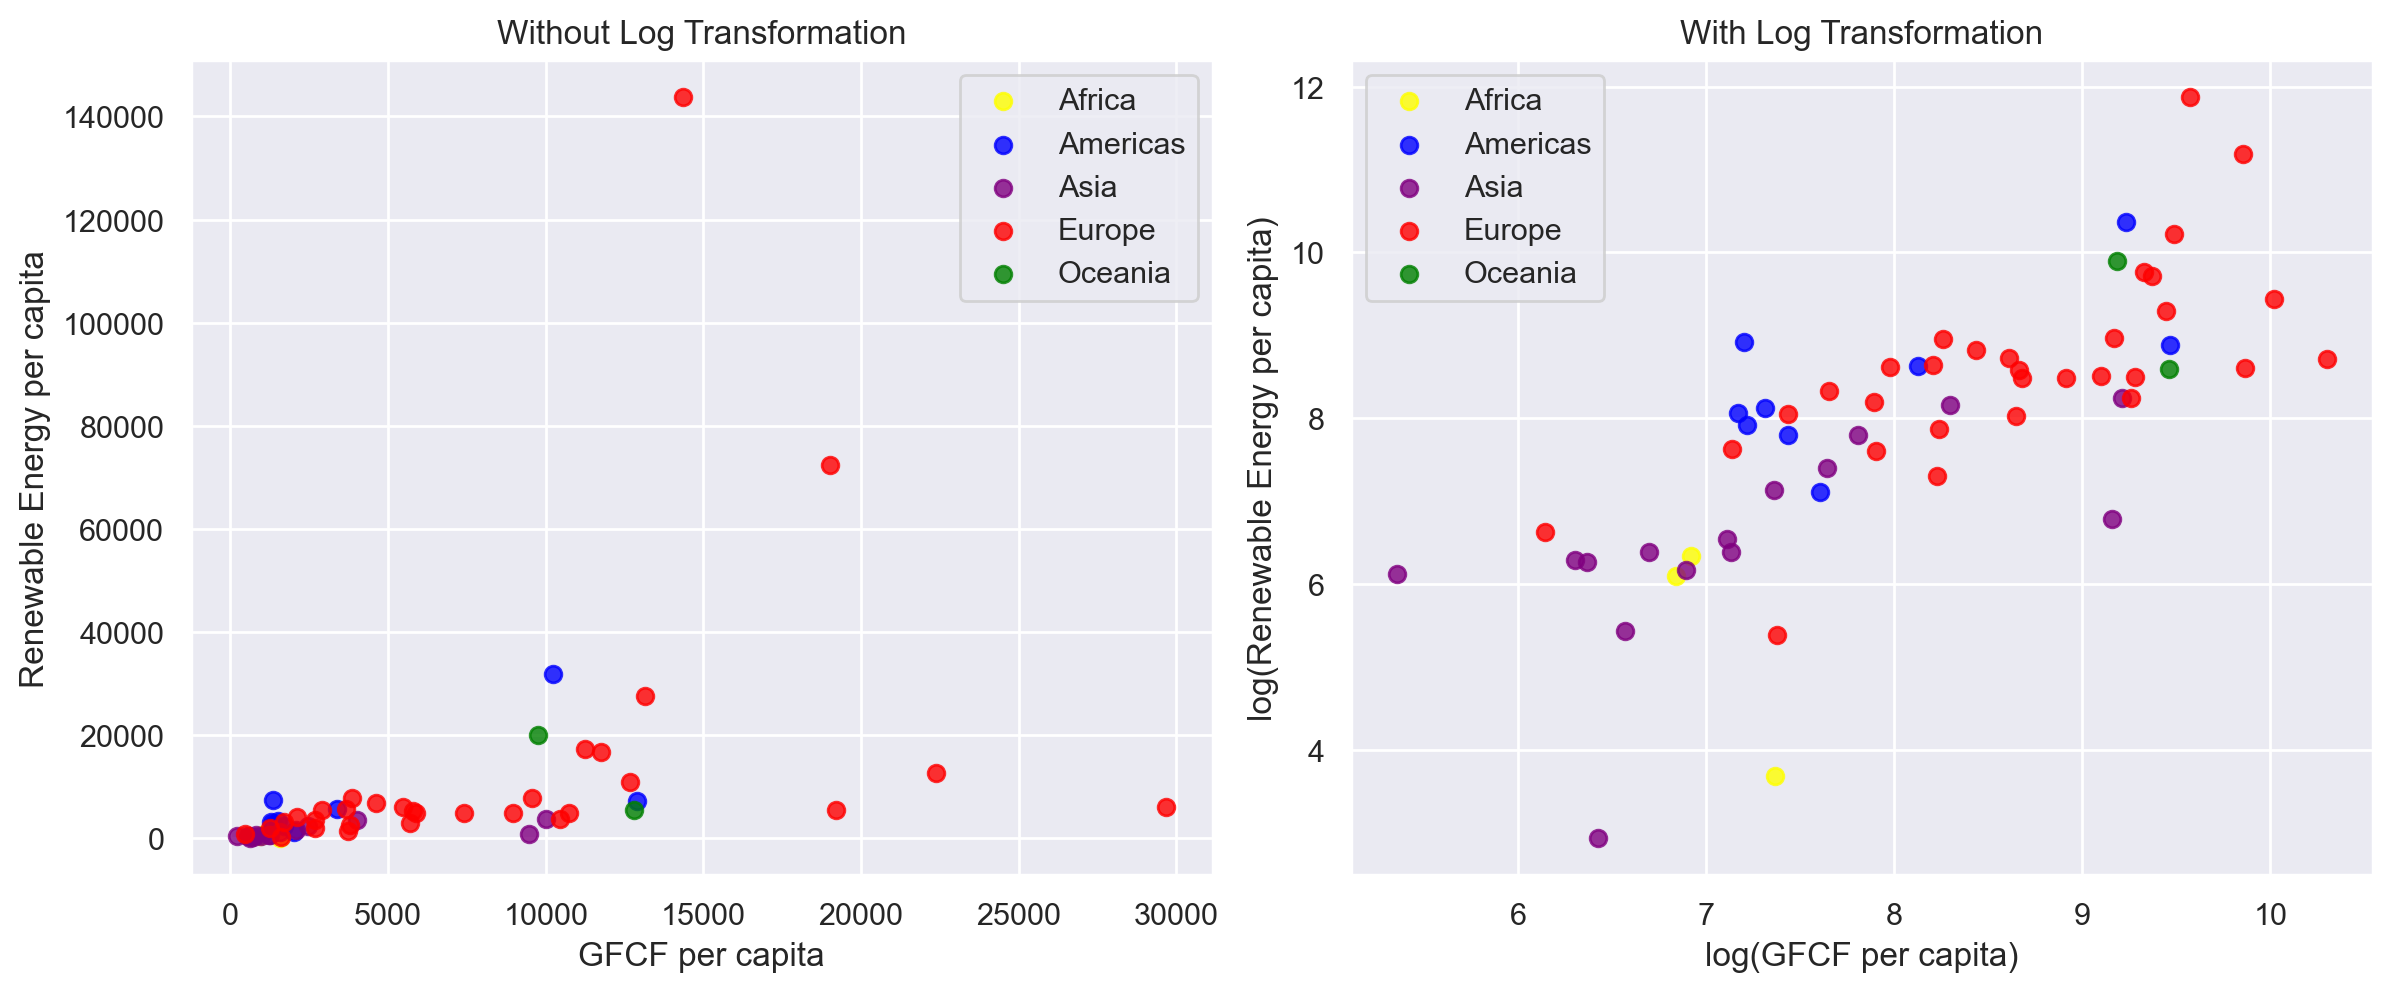

In [89]:
import matplotlib.pyplot as plt

region = Primary_variables['region']

# Define colors based on region
color_map = {'Africa': 'yellow', 'Americas': 'blue', 'Asia': 'purple', 'Europe': 'red', 'Oceania': 'green'}

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot without log transformation
axs[0].set_title('Without Log Transformation')
axs[0].set_xlabel('GFCF per capita')
axs[0].set_ylabel('Renewable Energy per capita')

for reg, col in color_map.items():
    reg_data = Primary_variables[Primary_variables['region'] == reg]
    axs[0].scatter(reg_data['GFCF_pc'], reg_data['RE_pc'], color=col, alpha=0.8, label=reg)

axs[0].legend()

# Plot with log-transformed data
axs[1].set_title('With Log Transformation')
axs[1].set_xlabel('log(GFCF per capita)')
axs[1].set_ylabel('log(Renewable Energy per capita)')

for reg, col in color_map.items():
    reg_data = Primary_variables[Primary_variables['region'] == reg]
    axs[1].scatter(reg_data['lGFCF_pc'], reg_data['lRE_pc'], color=col, alpha=0.8, label=reg)

axs[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

### Scatter plot of Renewable Energy Consumption to Nonrenewable Energy Consumption for different regions without and with log variables

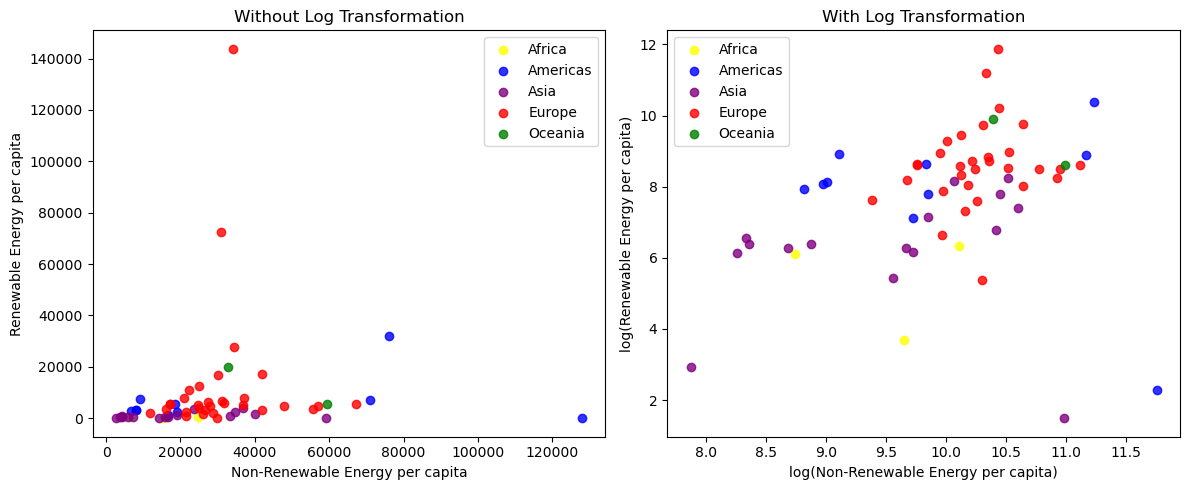

In [34]:
import matplotlib.pyplot as plt

region = Primary_variables['region']

# Define colors based on region
color_map = {'Africa': 'yellow', 'Americas': 'blue', 'Asia': 'purple', 'Europe': 'red', 'Oceania': 'green'}

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot without log transformation
axs[0].set_title('Without Log Transformation')
axs[0].set_xlabel('Non-Renewable Energy per capita')
axs[0].set_ylabel('Renewable Energy per capita')

for reg, col in color_map.items():
    reg_data = Primary_variables[Primary_variables['region'] == reg]
    axs[0].scatter(reg_data['NRE_pc'], reg_data['RE_pc'], color=col, alpha=0.8, label=reg)

axs[0].legend()

# Plot with log-transformed data
axs[1].set_title('With Log Transformation')
axs[1].set_xlabel('log(Non-Renewable Energy per capita)')
axs[1].set_ylabel('log(Renewable Energy per capita)')

for reg, col in color_map.items():
    reg_data = Primary_variables[Primary_variables['region'] == reg]
    axs[1].scatter(reg_data['lNRE_pc'], reg_data['lRE_pc'], color=col, alpha=0.8, label=reg)

axs[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

### Scatter plot of Renewable Energy Consumption to Access to Electricity for different regions without and with log variables

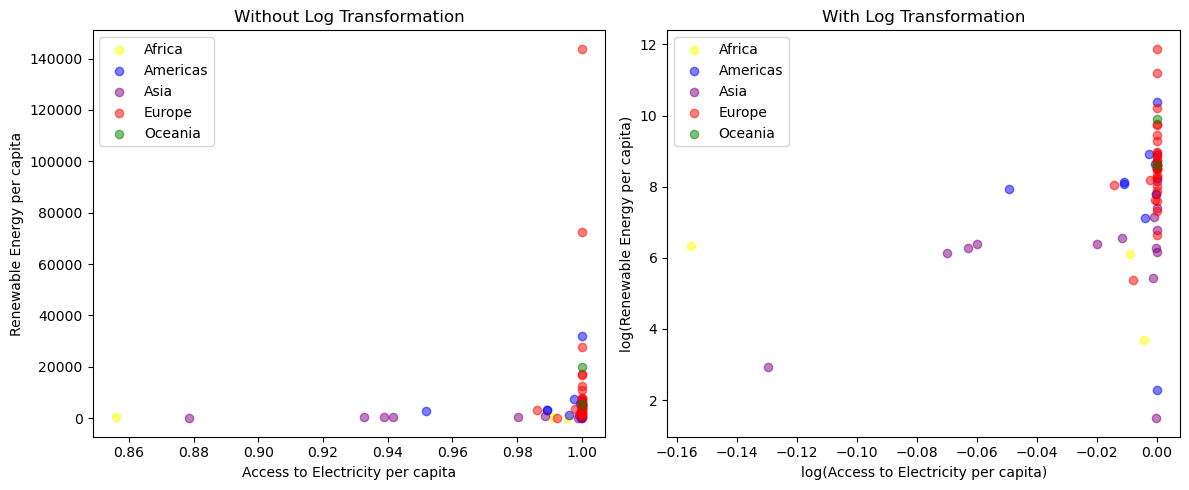

In [35]:
import matplotlib.pyplot as plt

region = Primary_variables['region']

# Define colors based on region
color_map = {'Africa': 'yellow', 'Americas': 'blue', 'Asia': 'purple', 'Europe': 'red', 'Oceania': 'green'}

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot without log transformation
axs[0].set_title('Without Log Transformation')
axs[0].set_xlabel('Access to Electricity per capita')
axs[0].set_ylabel('Renewable Energy per capita')

for reg, col in color_map.items():
    reg_data = Primary_variables[Primary_variables['region'] == reg]
    axs[0].scatter(reg_data['AE_pc'], reg_data['RE_pc'], color=col, alpha=0.5, label=reg)

axs[0].legend()

# Plot with log-transformed data
axs[1].set_title('With Log Transformation')
axs[1].set_xlabel('log(Access to Electricity per capita)')
axs[1].set_ylabel('log(Renewable Energy per capita)')

for reg, col in color_map.items():
    reg_data = Primary_variables[Primary_variables['region'] == reg]
    axs[1].scatter(reg_data['lAE_pc'], reg_data['lRE_pc'], color=col, alpha=0.5, label=reg)

axs[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

### Scatter plot of Renewable Energy Consumption to Electricity Demand for different regions without and with log variables

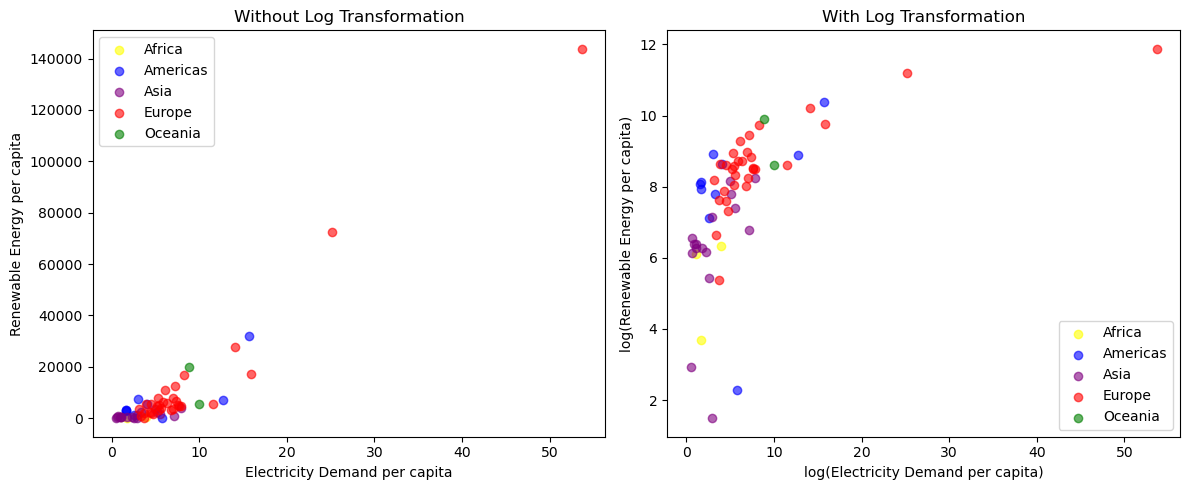

In [36]:
import matplotlib.pyplot as plt

region = Primary_variables['region']

# Define colors based on region
color_map = {'Africa': 'yellow', 'Americas': 'blue', 'Asia': 'purple', 'Europe': 'red', 'Oceania': 'green'}

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot without log transformation
axs[0].set_title('Without Log Transformation')
axs[0].set_xlabel('Electricity Demand per capita')
axs[0].set_ylabel('Renewable Energy per capita')

for reg, col in color_map.items():
    reg_data = Primary_variables[Primary_variables['region'] == reg]
    axs[0].scatter(reg_data['ED_ÎœW_PC'], reg_data['RE_pc'], color=col, alpha=0.6, label=reg)

axs[0].legend()

# Plot with log-transformed data
axs[1].set_title('With Log Transformation')
axs[1].set_xlabel('log(Electricity Demand per capita)')
axs[1].set_ylabel('log(Renewable Energy per capita)')

for reg, col in color_map.items():
    reg_data = Primary_variables[Primary_variables['region'] == reg]
    axs[1].scatter(reg_data['ED_ÎœW_PC'], reg_data['lRE_pc'], color=col, alpha=0.6, label=reg)

axs[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

### Scatter plot and fitted line of Renewable Energy Consumption to Gross Fixed Capital Formation

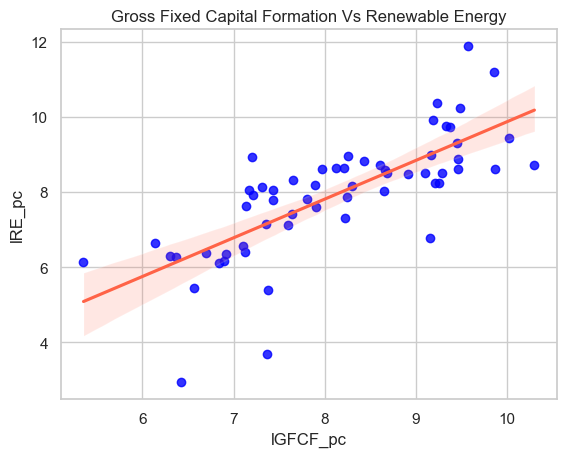

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# define lGFCF_pc and lRE_pc
lGFCF_pc = Primary_variables['lGFCF_pc']
lRE_pc = Primary_variables['lRE_pc']

# scatter plot with Seaborn
sns.set(style="whitegrid") 

# Scatter plot with regression line
sns.regplot(x=lGFCF_pc, y=lRE_pc, scatter_kws={'color': 'blue'}, line_kws={'color': 'tomato'})

# Label the axes
plt.xlabel('lGFCF_pc')
plt.ylabel('lRE_pc')

#adding title
plt.title('Gross Fixed Capital Formation Vs Renewable Energy', fontsize=12)

# Show the plot
plt.show()

### Scatter plot and fitted line of Renewable Energy Consumption to Nonrenewable Energy Consumption

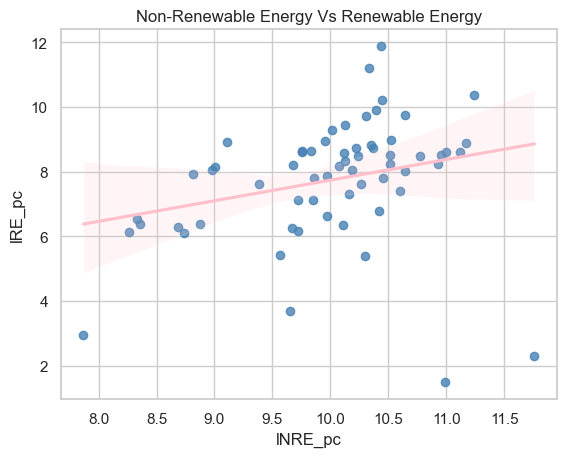

In [38]:
# define lNRE_pc and lRE_pc
lNRE_pc = Primary_variables['lNRE_pc']
lRE_pc = Primary_variables['lRE_pc']

# scatter plot with Seaborn
sns.set(style="whitegrid") 

# Scatter plot with regression line
sns.regplot(x=lNRE_pc, y=lRE_pc, scatter_kws={'color': 'steelblue'}, line_kws={'color': 'pink'})

# Label the axes
plt.xlabel('lNRE_pc')
plt.ylabel('lRE_pc')

#adding title
plt.title('Non-Renewable Energy Vs Renewable Energy', fontsize=12)

# Show the plot
plt.show()

### Scatter plot and fitted line of Renewable Energy Consumption to Access to Electricity

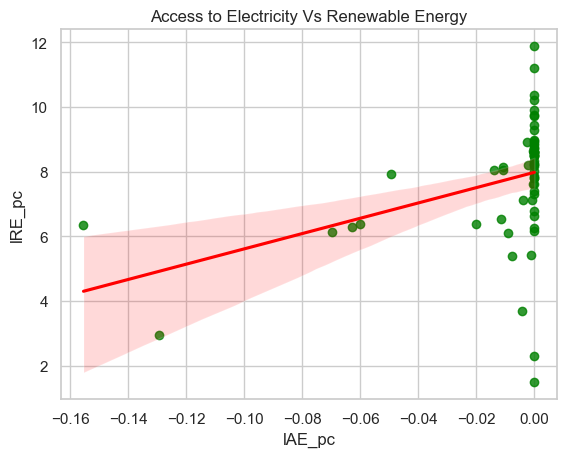

In [39]:
# define lAE_pc and lRE_pc
lAE_pc = Primary_variables['lAE_pc']
lRE_pc = Primary_variables['lRE_pc']

# scatter plot with Seaborn
sns.set(style="whitegrid") 

# Scatter plot with regression line
sns.regplot(x=lAE_pc, y=lRE_pc, scatter_kws={'color': 'green'}, line_kws={'color': 'red'})

# Label the axes
plt.xlabel('lAE_pc')
plt.ylabel('lRE_pc')

#adding title
plt.title('Access to Electricity Vs Renewable Energy', fontsize=12)

# Show the plot
plt.show()

### Scatter plot and fitted line of Renewable Energy Consumption to Electricity Demand

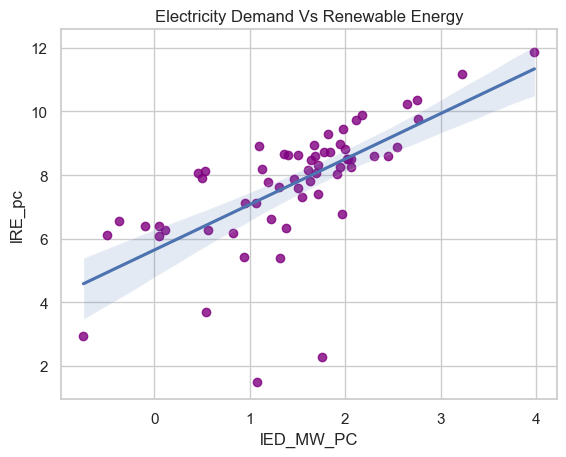

In [40]:
# define lED_pc and lRE_pc
lED_ÎœW_pc = Primary_variables['lED_ÎœW_PC']  # Corrected to 'lED_ÎœW_PC'
lRE_pc = Primary_variables['lRE_pc']

# scatter plot with Seaborn
sns.set(style="whitegrid") 

# Scatter plot with regression line
sns.regplot(x=lED_ÎœW_pc, y=lRE_pc, scatter_kws={'color': 'purple'}, line_kws={'color': 'b'})

# Label the axes
plt.xlabel('lED_ÎœW_PC')  # Corrected to 'lED_ÎœW_PC'
plt.ylabel('lRE_pc')

# adding title
plt.title('Electricity Demand Vs Renewable Energy', fontsize=12)

# Show the plot
plt.show()

### Histogram of Renewable Energy Consumption

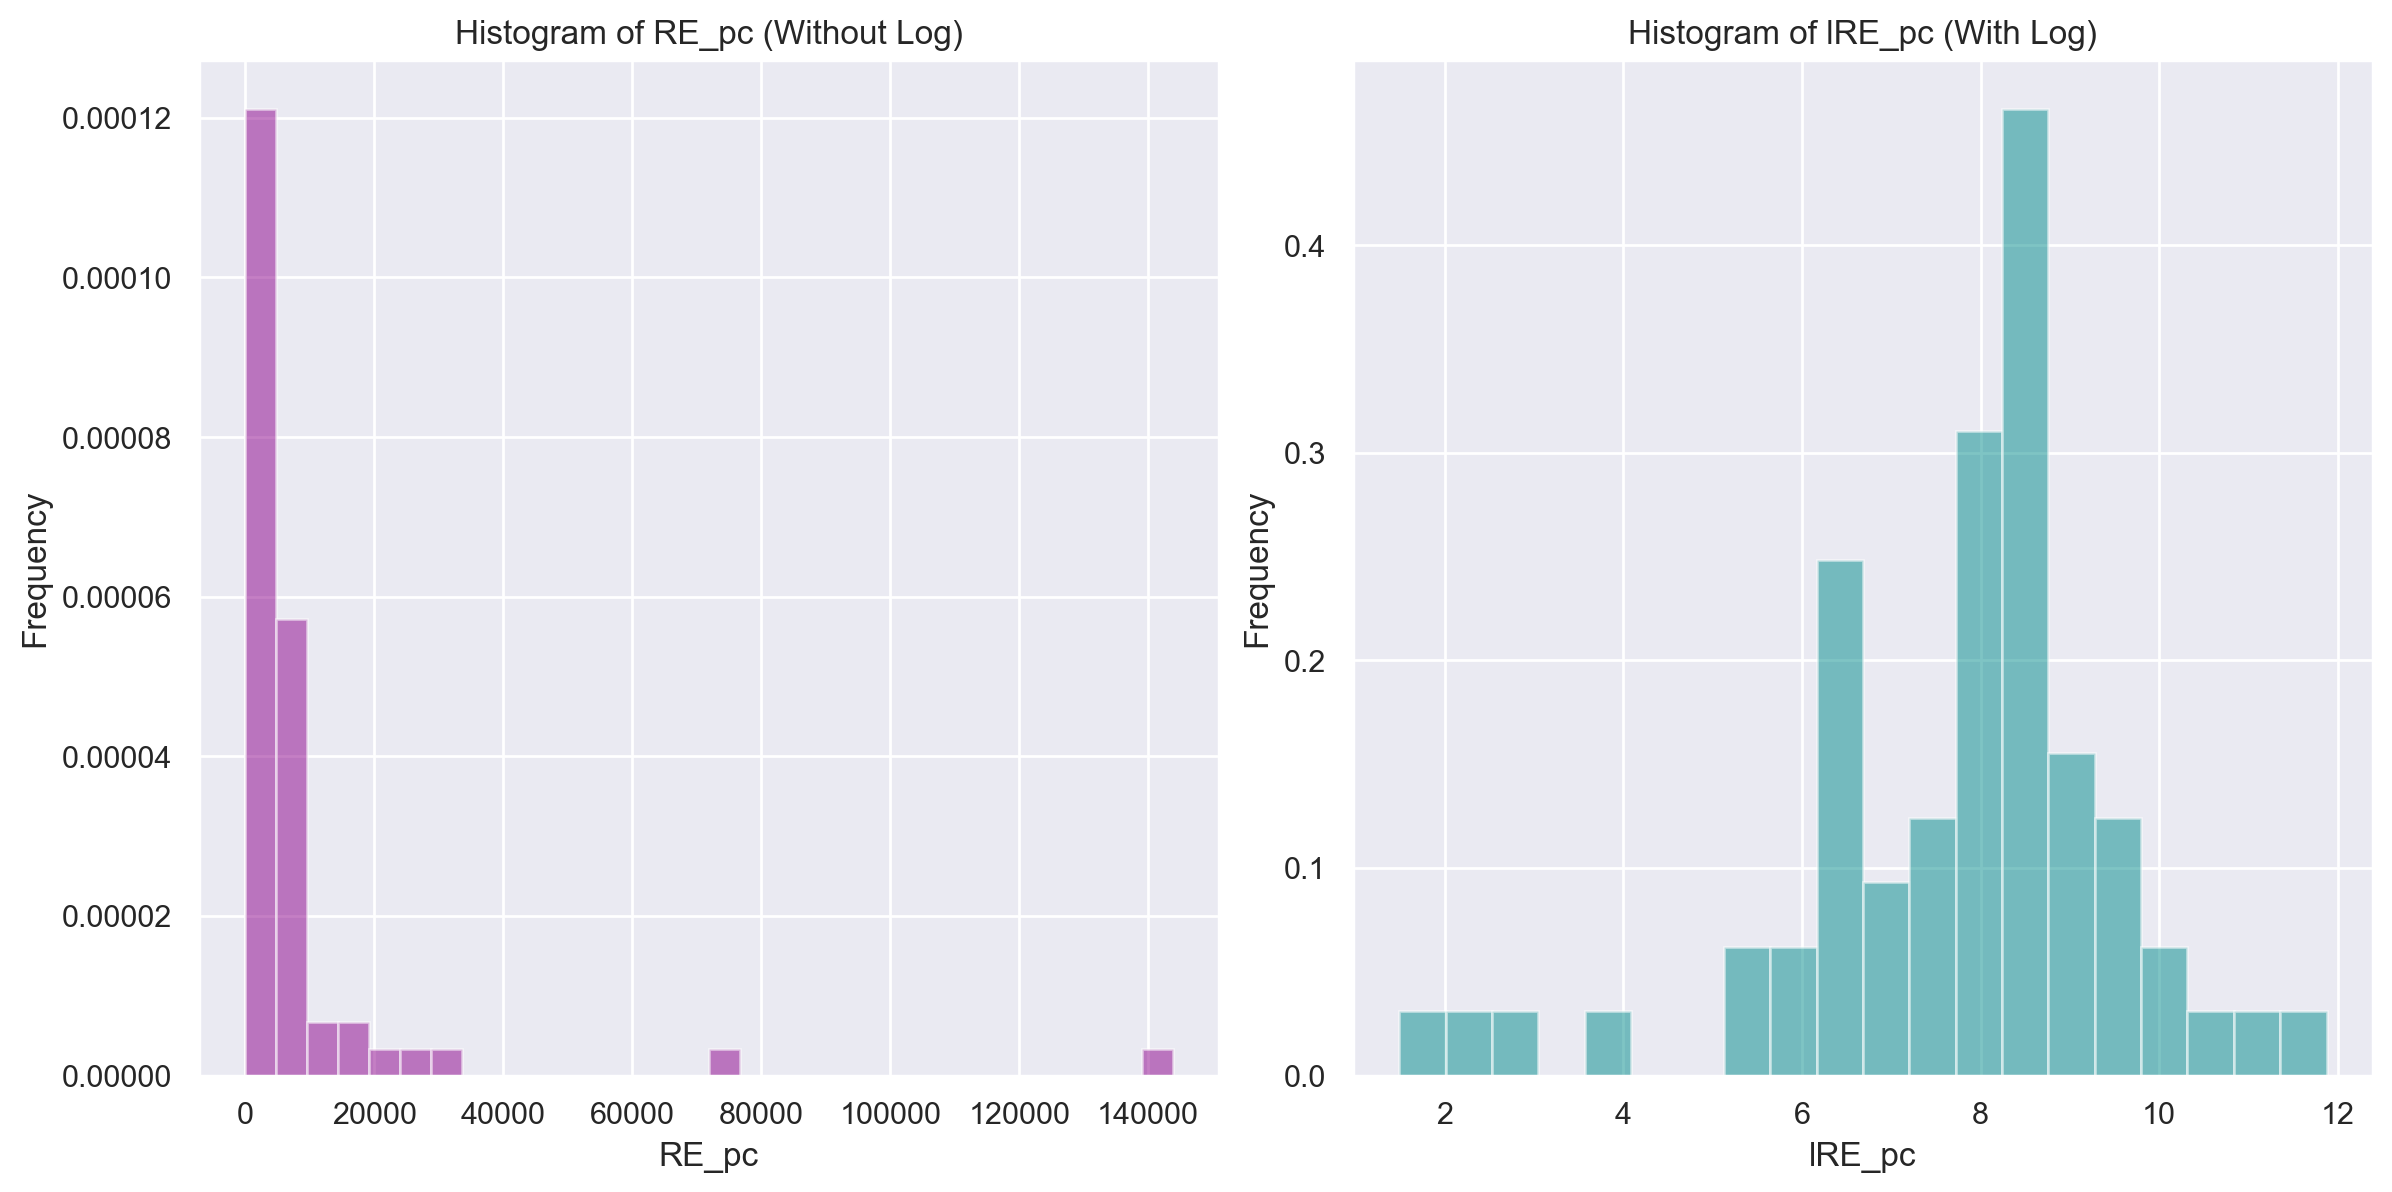

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Define RE_pc and lRE_pc
RE_pc = Primary_variables['RE_pc']
lRE_pc = Primary_variables['lRE_pc']

# Histogram without log transformation for RE_pc
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(RE_pc, bins=30, density=True, color='darkmagenta', alpha=0.5)
plt.xlabel('RE_pc')
plt.ylabel('Frequency')
plt.title('Histogram of RE_pc (Without Log)')

# Histogram with log transformation for lRE_pc
plt.subplot(1, 2, 2)
plt.hist(lRE_pc, bins=20, density=True, color='darkcyan', alpha=0.5)
plt.xlabel('lRE_pc')
plt.ylabel('Frequency')
plt.title('Histogram of lRE_pc (With Log)')

# Adjust layout
plt.tight_layout()

# Show the histograms
plt.show()

### Histrogram of Gross Fixed Capital Formation

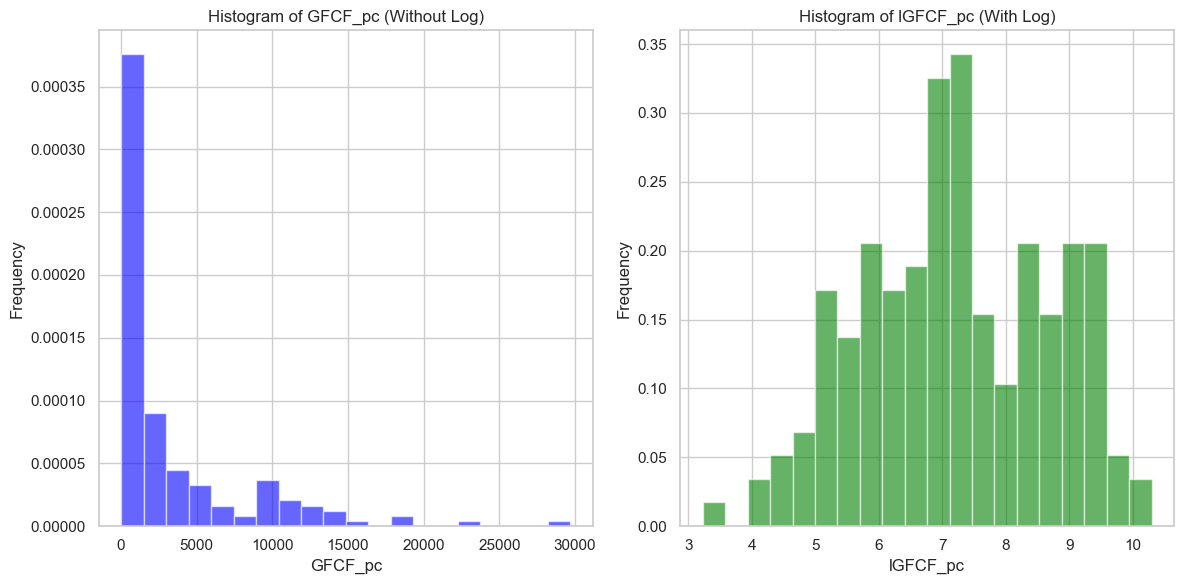

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Define GFCF_pc and lGFCF_pc
GFCF_pc = Primary_variables['GFCF_pc']
lGFCF_pc = Primary_variables['lGFCF_pc']

# Histogram without log transformation for GFCF_pc
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(GFCF_pc, bins=20, density=True, color='blue', alpha=0.6)
plt.xlabel('GFCF_pc')
plt.ylabel('Frequency')
plt.title('Histogram of GFCF_pc (Without Log)')

# Histogram with log transformation for lGFCF_pc
plt.subplot(1, 2, 2)
plt.hist(lGFCF_pc, bins=20, density=True, color='green', alpha=0.6)
plt.xlabel('lGFCF_pc')
plt.ylabel('Frequency')
plt.title('Histogram of lGFCF_pc (With Log)')

# Adjust layout
plt.tight_layout()

# Show the histograms
plt.show()

### Histogram of Nonrenewable Energy Consumption

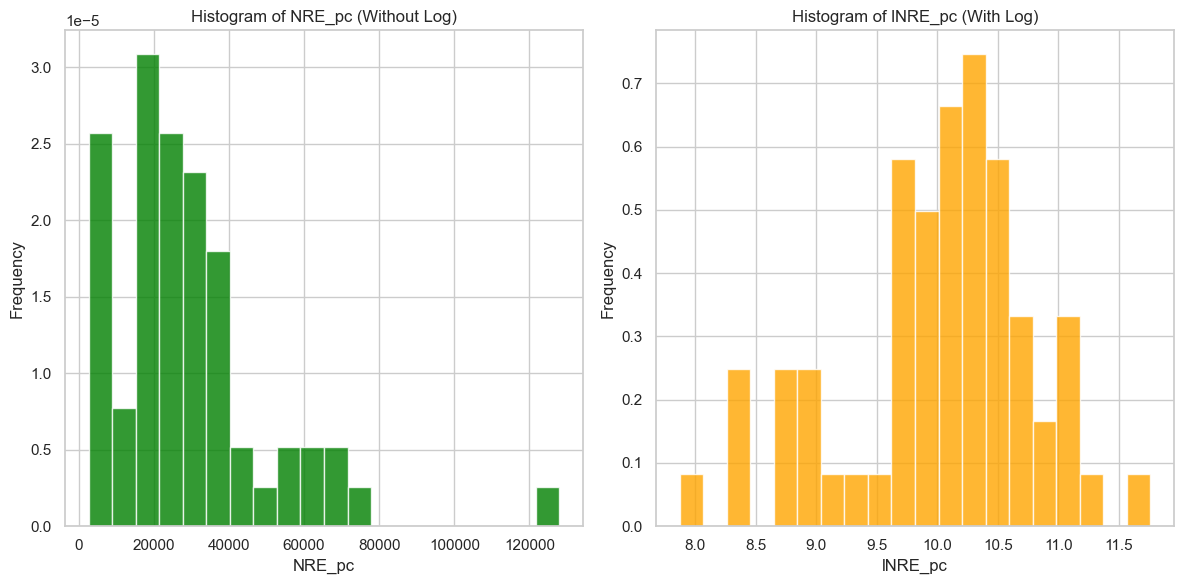

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Define NRE_pc and lNRE_pc
NRE_pc = Primary_variables['NRE_pc']
lNRE_pc = Primary_variables['lNRE_pc']

# Histogram without log transformation for NRE_pc
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(NRE_pc, bins=20, density=True, color='green', alpha=0.8)
plt.xlabel('NRE_pc')
plt.ylabel('Frequency')
plt.title('Histogram of NRE_pc (Without Log)')

# Histogram with log transformation for lNRE_pc
plt.subplot(1, 2, 2)
plt.hist(lNRE_pc, bins=20, density=True, color='orange', alpha=0.8)
plt.xlabel('lNRE_pc')
plt.ylabel('Frequency')
plt.title('Histogram of lNRE_pc (With Log)')

# Adjust layout
plt.tight_layout()

# Show the histograms
plt.show()

### Histogram of Access to Electricity

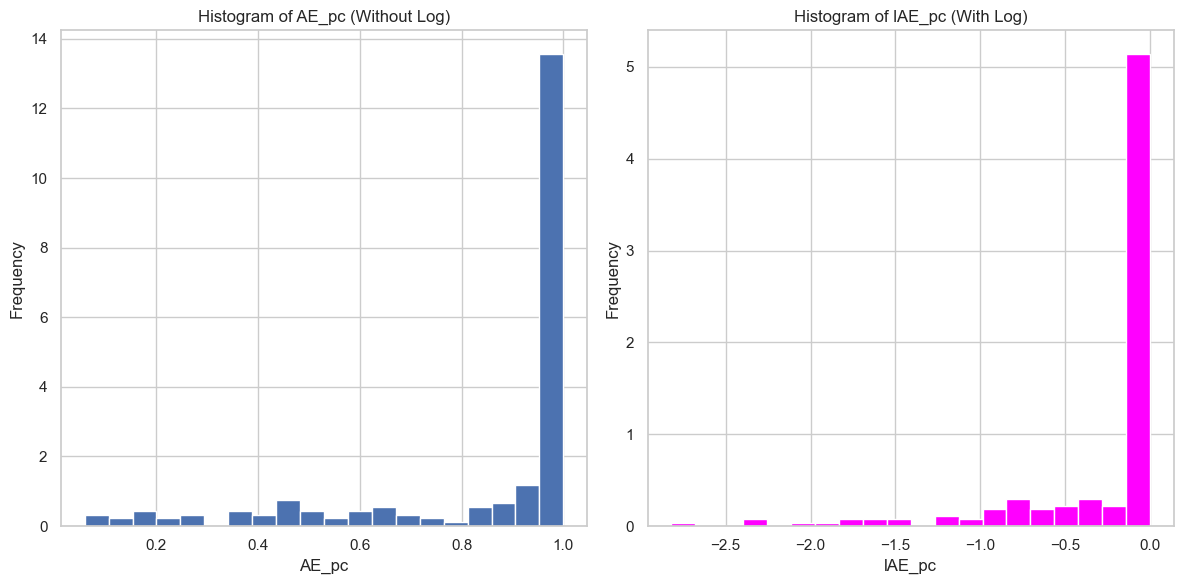

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Define AE_pc and lAE_pc
AE_pc = Primary_variables['AE_pc']
lAE_pc = Primary_variables['lAE_pc']

# Histogram without log transformation for AE_pc
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(AE_pc, bins=20, density=True, color='b', alpha=1)
plt.xlabel('AE_pc')
plt.ylabel('Frequency')
plt.title('Histogram of AE_pc (Without Log)')

# Histogram with log transformation for lAE_pc
plt.subplot(1, 2, 2)
plt.hist(lAE_pc, bins=20, density=True, color='magenta', alpha=1)
plt.xlabel('lAE_pc')
plt.ylabel('Frequency')
plt.title('Histogram of lAE_pc (With Log)')

# Adjust layout
plt.tight_layout()

# Show the histograms
plt.show()

### Histogram of Electricity Demand

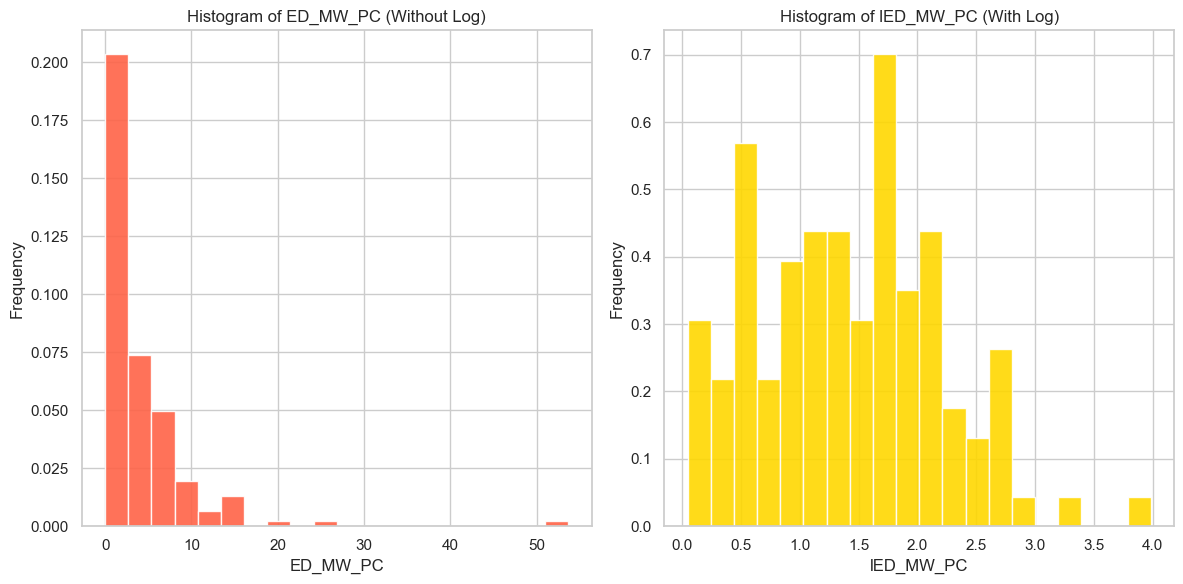

In [45]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

# Define ED_ÎœW_pc and lED_ÎœW_pc
ED_ÎœW_pc = Primary_variables['ED_ÎœW_PC']  # Corrected to 'ED_ÎœW_PC'
lED_ÎœW_pc = Primary_variables['lED_ÎœW_PC']

# Filter out negative or infinite values from lED_ÎœW_pc
lED_ÎœW_pc_valid = lED_ÎœW_pc[~np.isinf(lED_ÎœW_pc) & (lED_ÎœW_pc > 0)]

# Histogram without log transformation for ED_ÎœW_pc
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(ED_ÎœW_pc, bins=20, density=True, color='tomato', alpha=0.9)
plt.xlabel('ED_ÎœW_PC')  # Corrected to 'ED_ÎœW_PC'
plt.ylabel('Frequency')
plt.title('Histogram of ED_ÎœW_PC (Without Log)')

# Histogram with log transformation for lED_ÎœW_pc
plt.subplot(1, 2, 2)
plt.hist(lED_ÎœW_pc_valid, bins=20, density=True, color='gold', alpha=0.9)
plt.xlabel('lED_ÎœW_PC')
plt.ylabel('Frequency')
plt.title('Histogram of lED_ÎœW_PC (With Log)')

# Adjust layout
plt.tight_layout()

# Show the histograms
plt.show()


### Pair Plots showing the correlationships between and within variables

Index(['Country', 'Year', 'RE_pc', 'GFCF_pc', 'NRE_pc', 'AE_pc', 'ED_ÎœW_PC',
       'lRE_pc', 'lGFCF_pc', 'lNRE_pc', 'lAE_pc', 'lED_ÎœW_PC', 'region',
       'sub-region'],
      dtype='object')


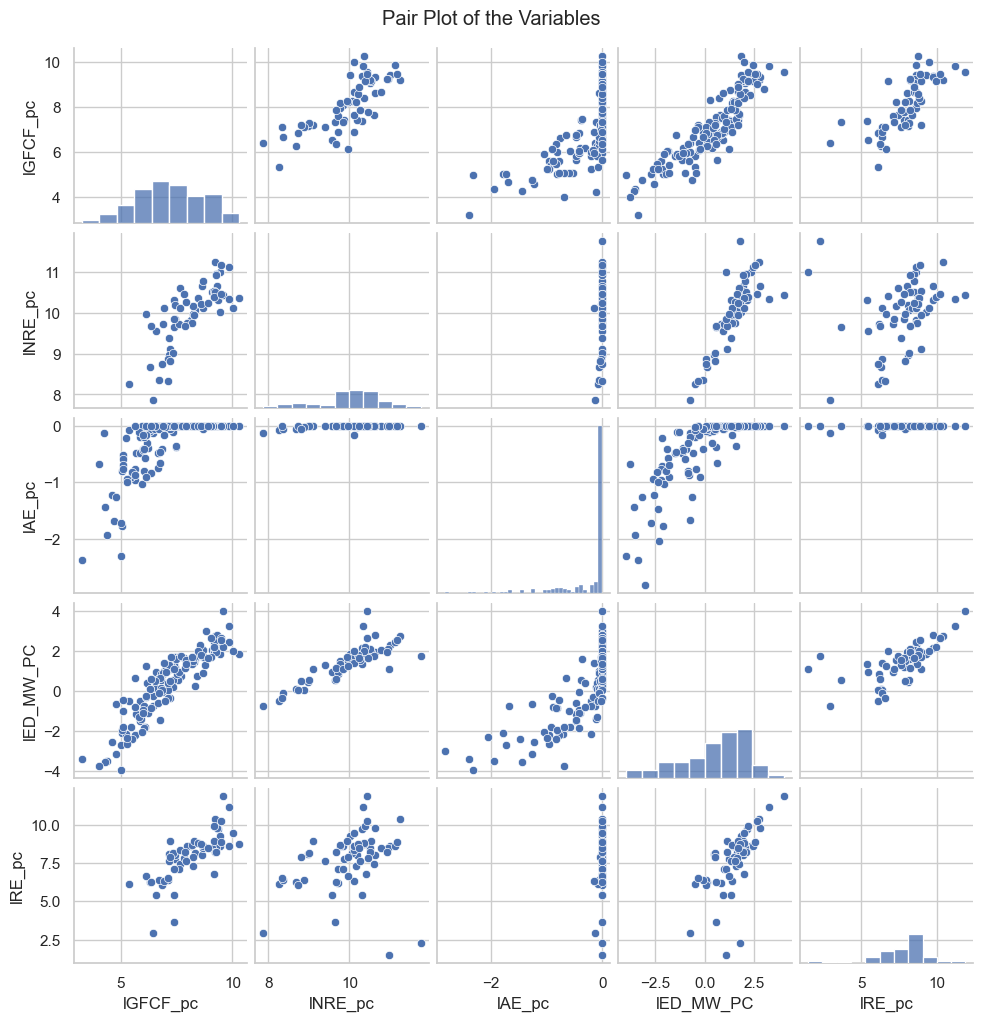

In [46]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import seaborn as sns
import matplotlib.pyplot as plt

# Verify the available columns
print(Primary_variables.columns)

# Assuming the correct column name is 'lED_ÎœW_PC' (with uppercase 'PC')
sns.pairplot(Primary_variables, vars=['lGFCF_pc', 'lNRE_pc', 'lAE_pc', 'lED_ÎœW_PC', 'lRE_pc'], height=2, kind='scatter')
plt.suptitle('Pair Plot of the Variables', y=1.02)
plt.show()

### Scatter plot of the GFCF_pc and RE_pc with all country names (without log)

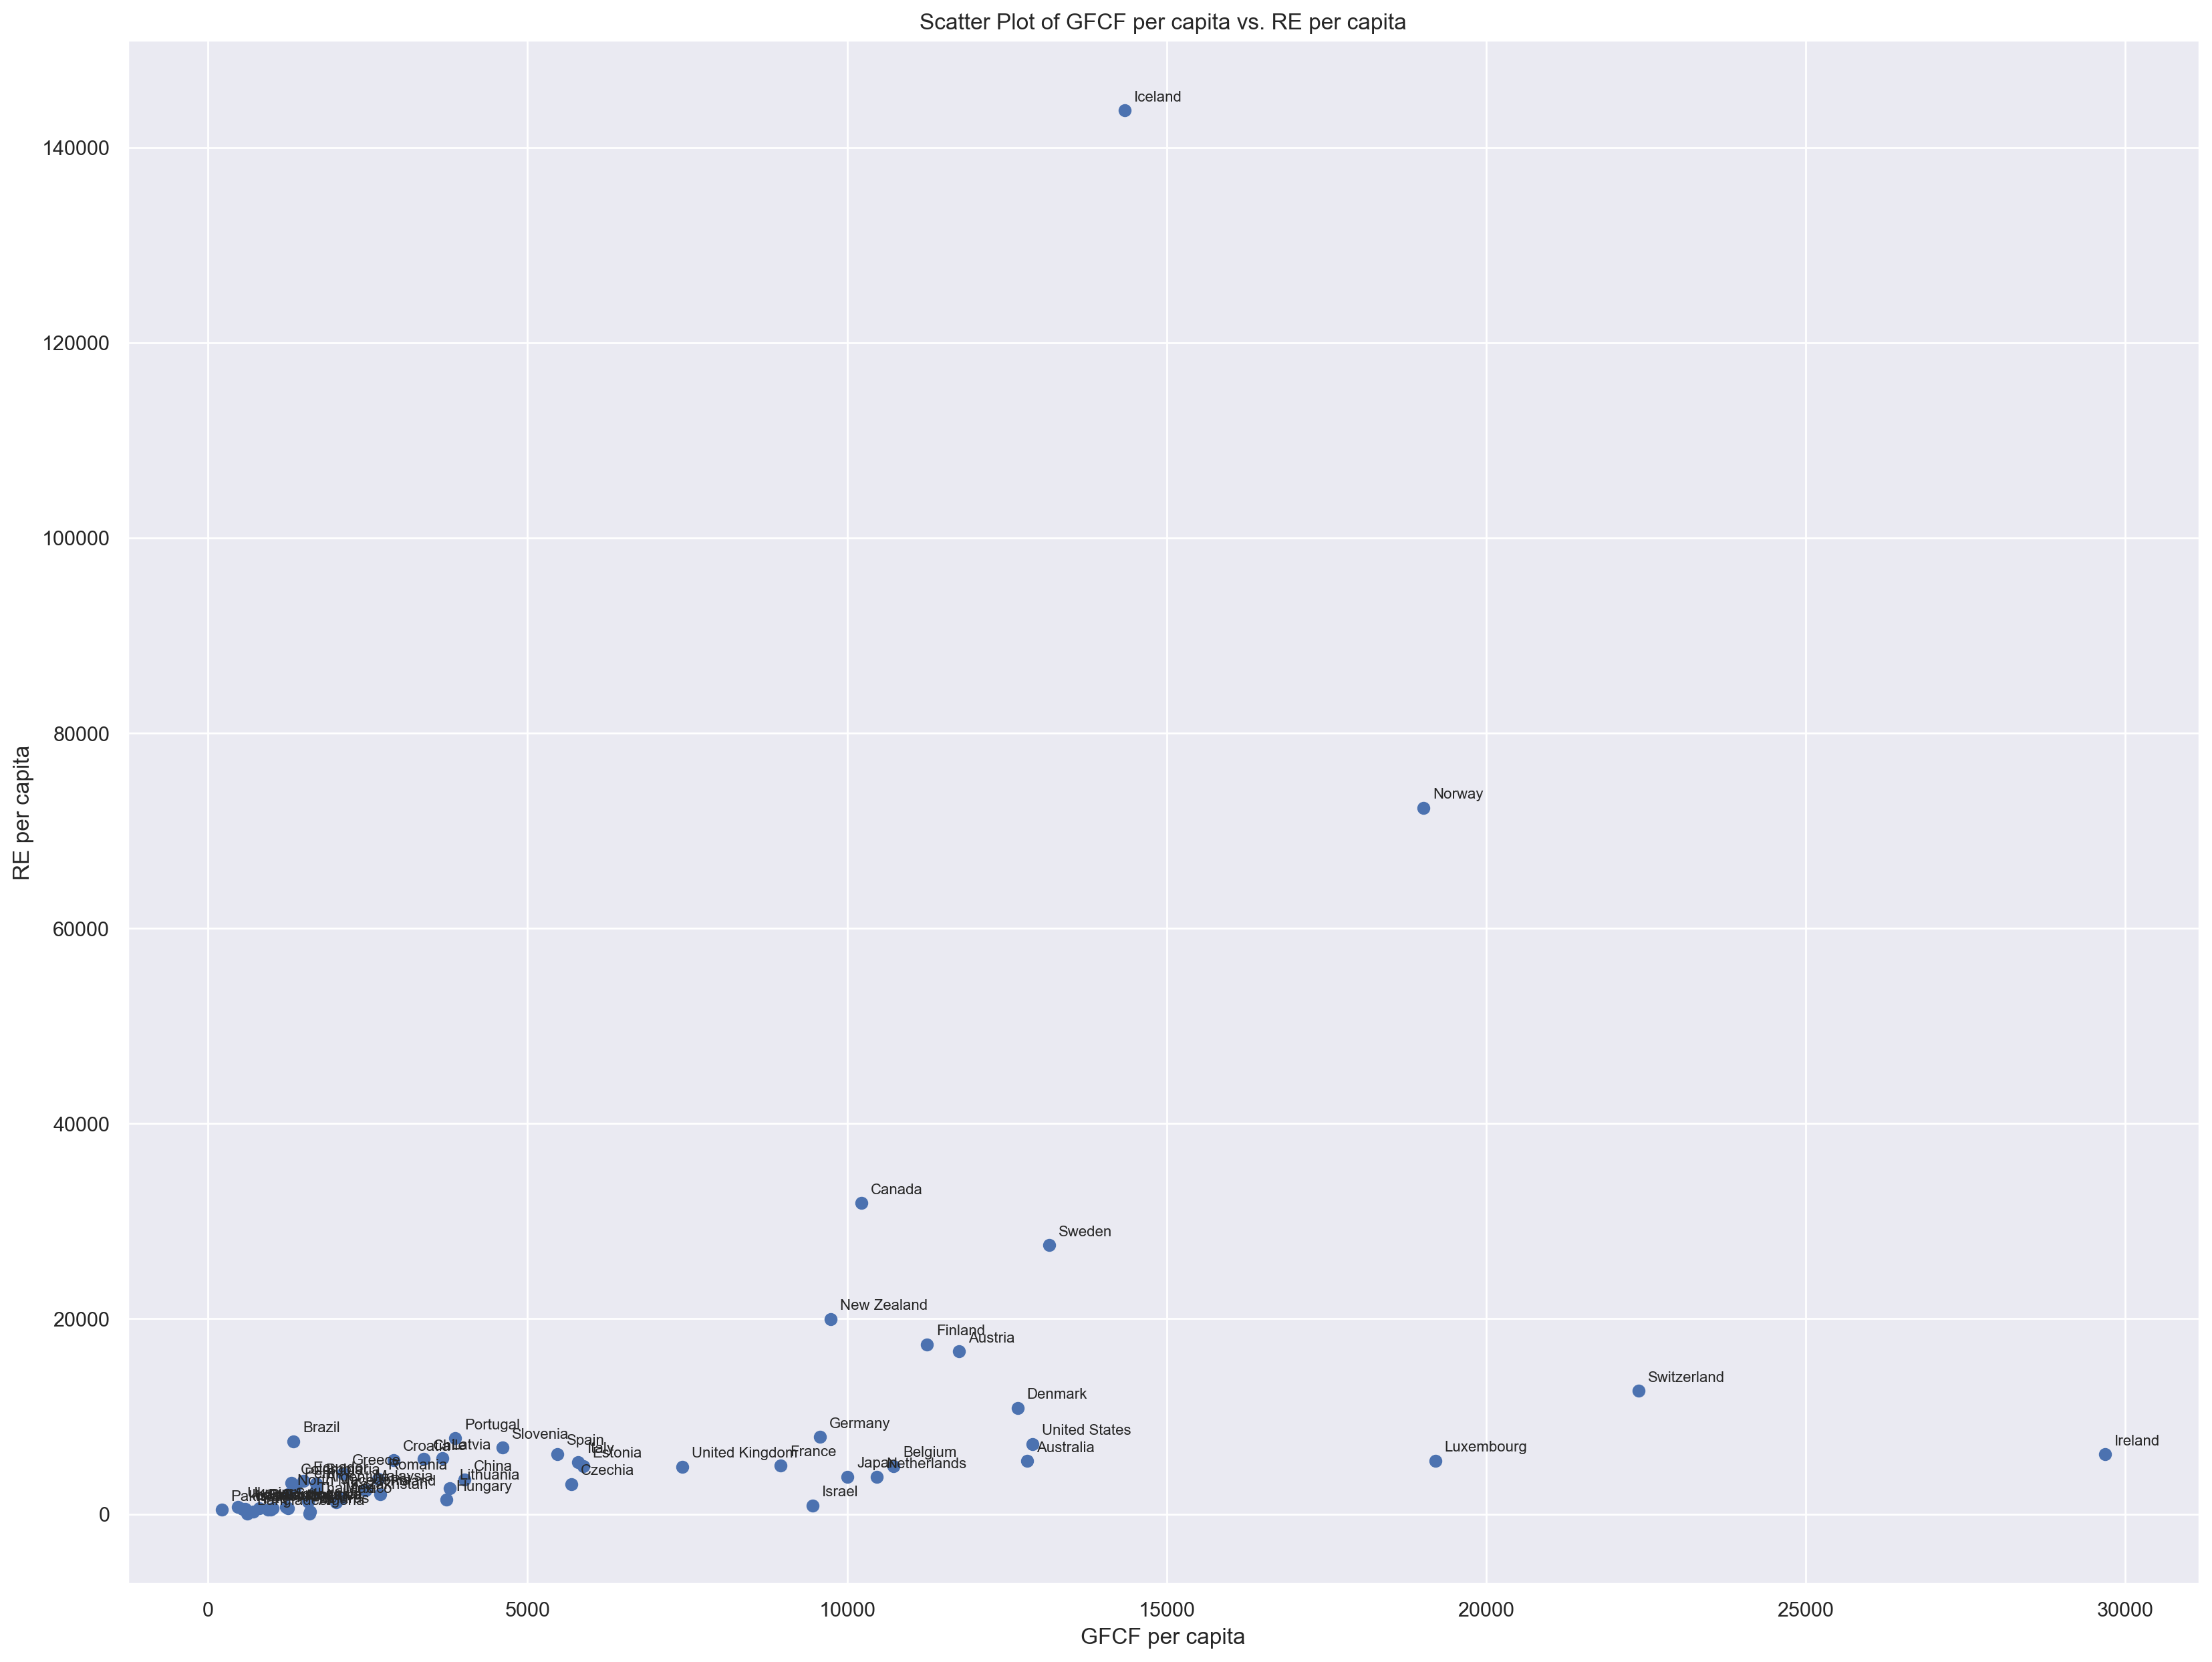

In [90]:
import matplotlib.pyplot as plt

# Adjust the default figure size and font size
plt.rcParams['figure.figsize'] = (20, 15)  # Increase the figure size
plt.rcParams['font.size'] = 8  # Decrease the font size

# Assuming Primary_variables is your DataFrame with columns 'GFCF_pc' and 'RE_pc'
plt.figure()

# Plot the data points
plt.scatter(Primary_variables['GFCF_pc'], Primary_variables['RE_pc'])

# Label the points by the associated country, with the label
for country in Primary_variables['Country']:
    plt.annotate(
        country,
        (Primary_variables['GFCF_pc'].loc[Primary_variables['Country'] == country].values[0],
         Primary_variables['RE_pc'].loc[Primary_variables['Country'] == country].values[0]),
        xytext=(5, 5),
        textcoords='offset points'
    )

# Label the axes
plt.xlabel('GFCF per capita')
plt.ylabel('RE per capita')

# Set the title
plt.title('Scatter Plot of GFCF per capita vs. RE per capita')

# Display the plot
plt.show()

### Scatter plot of the GFCF_pc and RE_pc with all country names (with log)

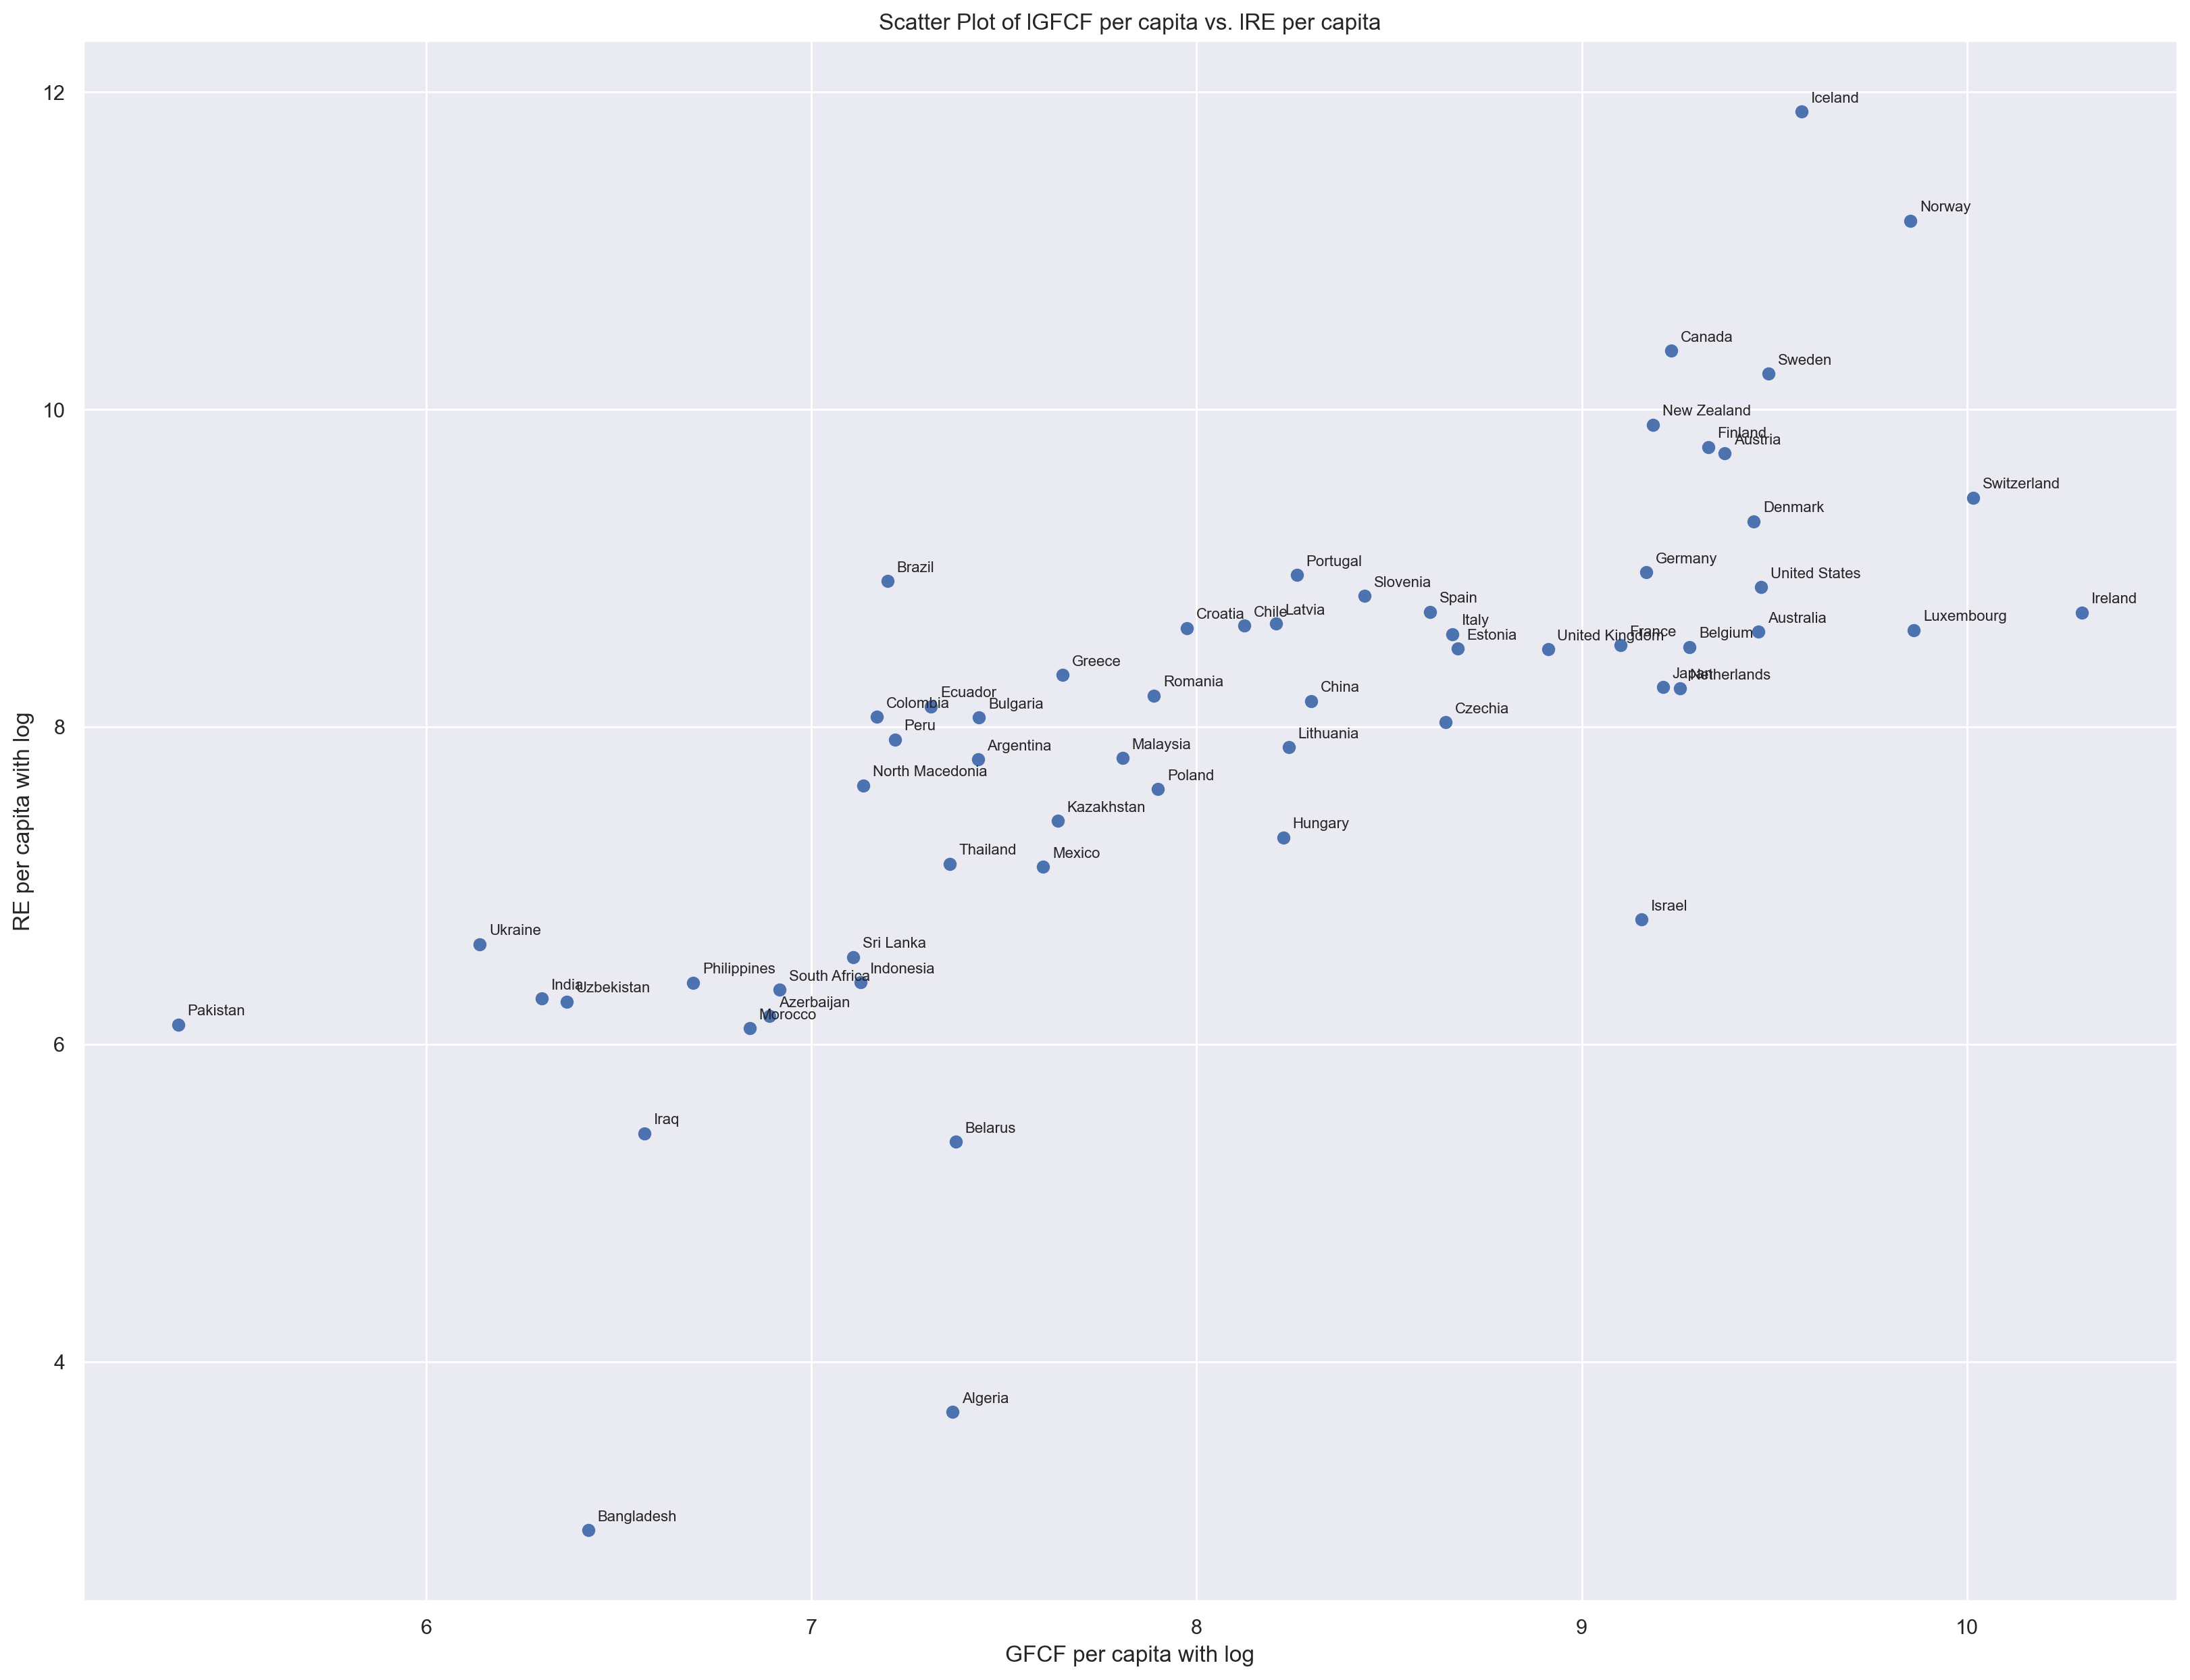

In [92]:
import matplotlib.pyplot as plt

# Adjust the default figure size and font size
plt.rcParams['figure.figsize'] = (20, 15)  # Increase the figure size
plt.rcParams['font.size'] = 8  # Decrease the font size

# Assuming Primary_variables is your DataFrame with columns 'GFCF_pc' and 'RE_pc'
plt.figure()

# Plot the data points
plt.scatter(Primary_variables['lGFCF_pc'], Primary_variables['lRE_pc'])

# Label the points by the associated country, with the label
for country in Primary_variables['Country']:
    plt.annotate(
        country,
        (Primary_variables['lGFCF_pc'].loc[Primary_variables['Country'] == country].values[0],
         Primary_variables['lRE_pc'].loc[Primary_variables['Country'] == country].values[0]),
        xytext=(5, 5),
        textcoords='offset points'
    )

# Label the axes
plt.xlabel('GFCF per capita with log')
plt.ylabel('RE per capita with log')

# Set the title
plt.title('Scatter Plot of lGFCF per capita vs. lRE per capita')

# Display the plot
plt.show()

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
rng = np.random.RandomState(0)

### Checking which variable is in which form of data

In [48]:
Primary_variables.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 197 entries, 0 to 196
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Country     197 non-null    object 
 1   Year        197 non-null    object 
 2   RE_pc       62 non-null     float64
 3   GFCF_pc     165 non-null    float64
 4   NRE_pc      62 non-null     float64
 5   AE_pc       196 non-null    float64
 6   ED_ÎœW_PC    172 non-null    float64
 7   lRE_pc      62 non-null     float64
 8   lGFCF_pc    165 non-null    float64
 9   lNRE_pc     62 non-null     float64
 10  lAE_pc      196 non-null    float64
 11  lED_ÎœW_PC   172 non-null    float64
 12  region      197 non-null    object 
 13  sub-region  197 non-null    object 
dtypes: float64(10), object(4)
memory usage: 23.1+ KB


### Descriptive summary of the data

In [49]:
Primary_variables.describe()

,RE_pc,GFCF_pc,NRE_pc,AE_pc,ED_ÎœW_PC,lRE_pc,lGFCF_pc,lNRE_pc,lAE_pc,lED_ÎœW_PC
count,62.000000,165.000000,62.000000,196.000000,172.000000,62.000000,165.000000,62.000000,196.000000,172.000000
mean,8289.918229,3482.367543,28850.729858,0.847245,3.969747,7.738235,7.205228,10.002743,-0.254539,-inf
std,20434.357335,4897.620791,21355.473984,0.256838,5.684016,1.894983,1.489396,0.793824,0.511571,NaN
min,4.426800,25.196385,2618.404800,0.059652,0.000000,1.487677,3.226701,7.870321,-2.819233,-inf
25%,788.784150,448.557307,16175.169450,0.814006,0.513040,6.668194,6.106036,9.691054,-0.205791,-0.668310
50%,3448.462200,1255.471869,24961.230400,0.997256,2.302041,8.145545,7.135267,10.125079,-0.002748,0.833769
75%,6024.042700,4086.873550,34585.493200,1.000000,5.411460,8.703034,8.315536,10.451183,0.000000,1.688518
max,143783.422000,29680.463977,127977.056000,1.000000,53.678363,11.876063,10.298244,11.759606,0.000000,3.983010


### We are trying to find the complex and non-linear relationships among the variables that's why we've tried both the Support Vector Regression (SVR) and Random Forest Regression from the Supervised Machine Learning. Moreover, K-Means Clustering is used from the unsupervised learning technique to identify the patterns or clusters in unlabeled data.

# Supervised Learning

## Support Vector Regression 

1. Choosing a class of model

In [122]:
from sklearn.svm import SVR

2. Choosing model hyperparameters

In [51]:
#SVR? we've used default C parameter and the default rbf kernel, so we our next step becomes:

In [123]:
model = SVR()

3. Arranging the data into a features matrix and target vector

In [124]:
X = Primary_variables[['GFCF_pc']].values
X.shape

(197, 1)

In [125]:
y = Primary_variables['RE_pc'].values
y.shape

(197,)

4. Splitting the data into a training set and a testing set

In [135]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = \
  train_test_split(X, y, test_size=0.3, random_state=1)

In [136]:
from sklearn.preprocessing import StandardScaler

sc_x = StandardScaler()
Xtrain_std = sc_x.fit_transform(Xtrain)
Xtest_std = sc_x.transform(Xtest)

sc_y = StandardScaler()
ytrain_std = sc_y.fit_transform(ytrain[:, np.newaxis]).flatten()
ytest_std = sc_y.transform(ytest[:, np.newaxis]).flatten()

5. Using the fit() method to fit the model to the training data 

In [137]:
from sklearn.impute import SimpleImputer

# Example for Xtrain_std
imputer_X = SimpleImputer(strategy='mean')
Xtrain_std = imputer_X.fit_transform(Xtrain_std)

# Example for ytrain_std
imputer_y = SimpleImputer(strategy='mean')
ytrain_std = imputer_y.fit_transform(ytrain_std.reshape(-1, 1)).flatten()

6. Using the predict() method to the test data

In [138]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
Xtest_std = imputer.fit_transform(Xtest_std)

7. Evaluating the accuracy of the model's predictions on the test data

In [139]:
from sklearn.svm import SVR

# Assuming you have an SVR model instance
model = SVR()

# Assuming you have already preprocessed your training data (Xtrain_std, ytrain_std)
model.fit(Xtrain_std, ytrain_std)

# Now, you can make predictions on your test data (Xtest_std)
ypred_std = model.predict(Xtest_std)


In [60]:
#SVR.score?

Running for the train data

In [140]:
model.score(Xtrain_std,ytrain_std)

0.045822550707520726

Running for the test data

In [141]:
#model.score(Xtest_std,ytest_std)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
Xtest_std = imputer.fit_transform(Xtest_std)


Creating and Examining a scatter plot of the training dataset and see how the SVR estimator fit to that set

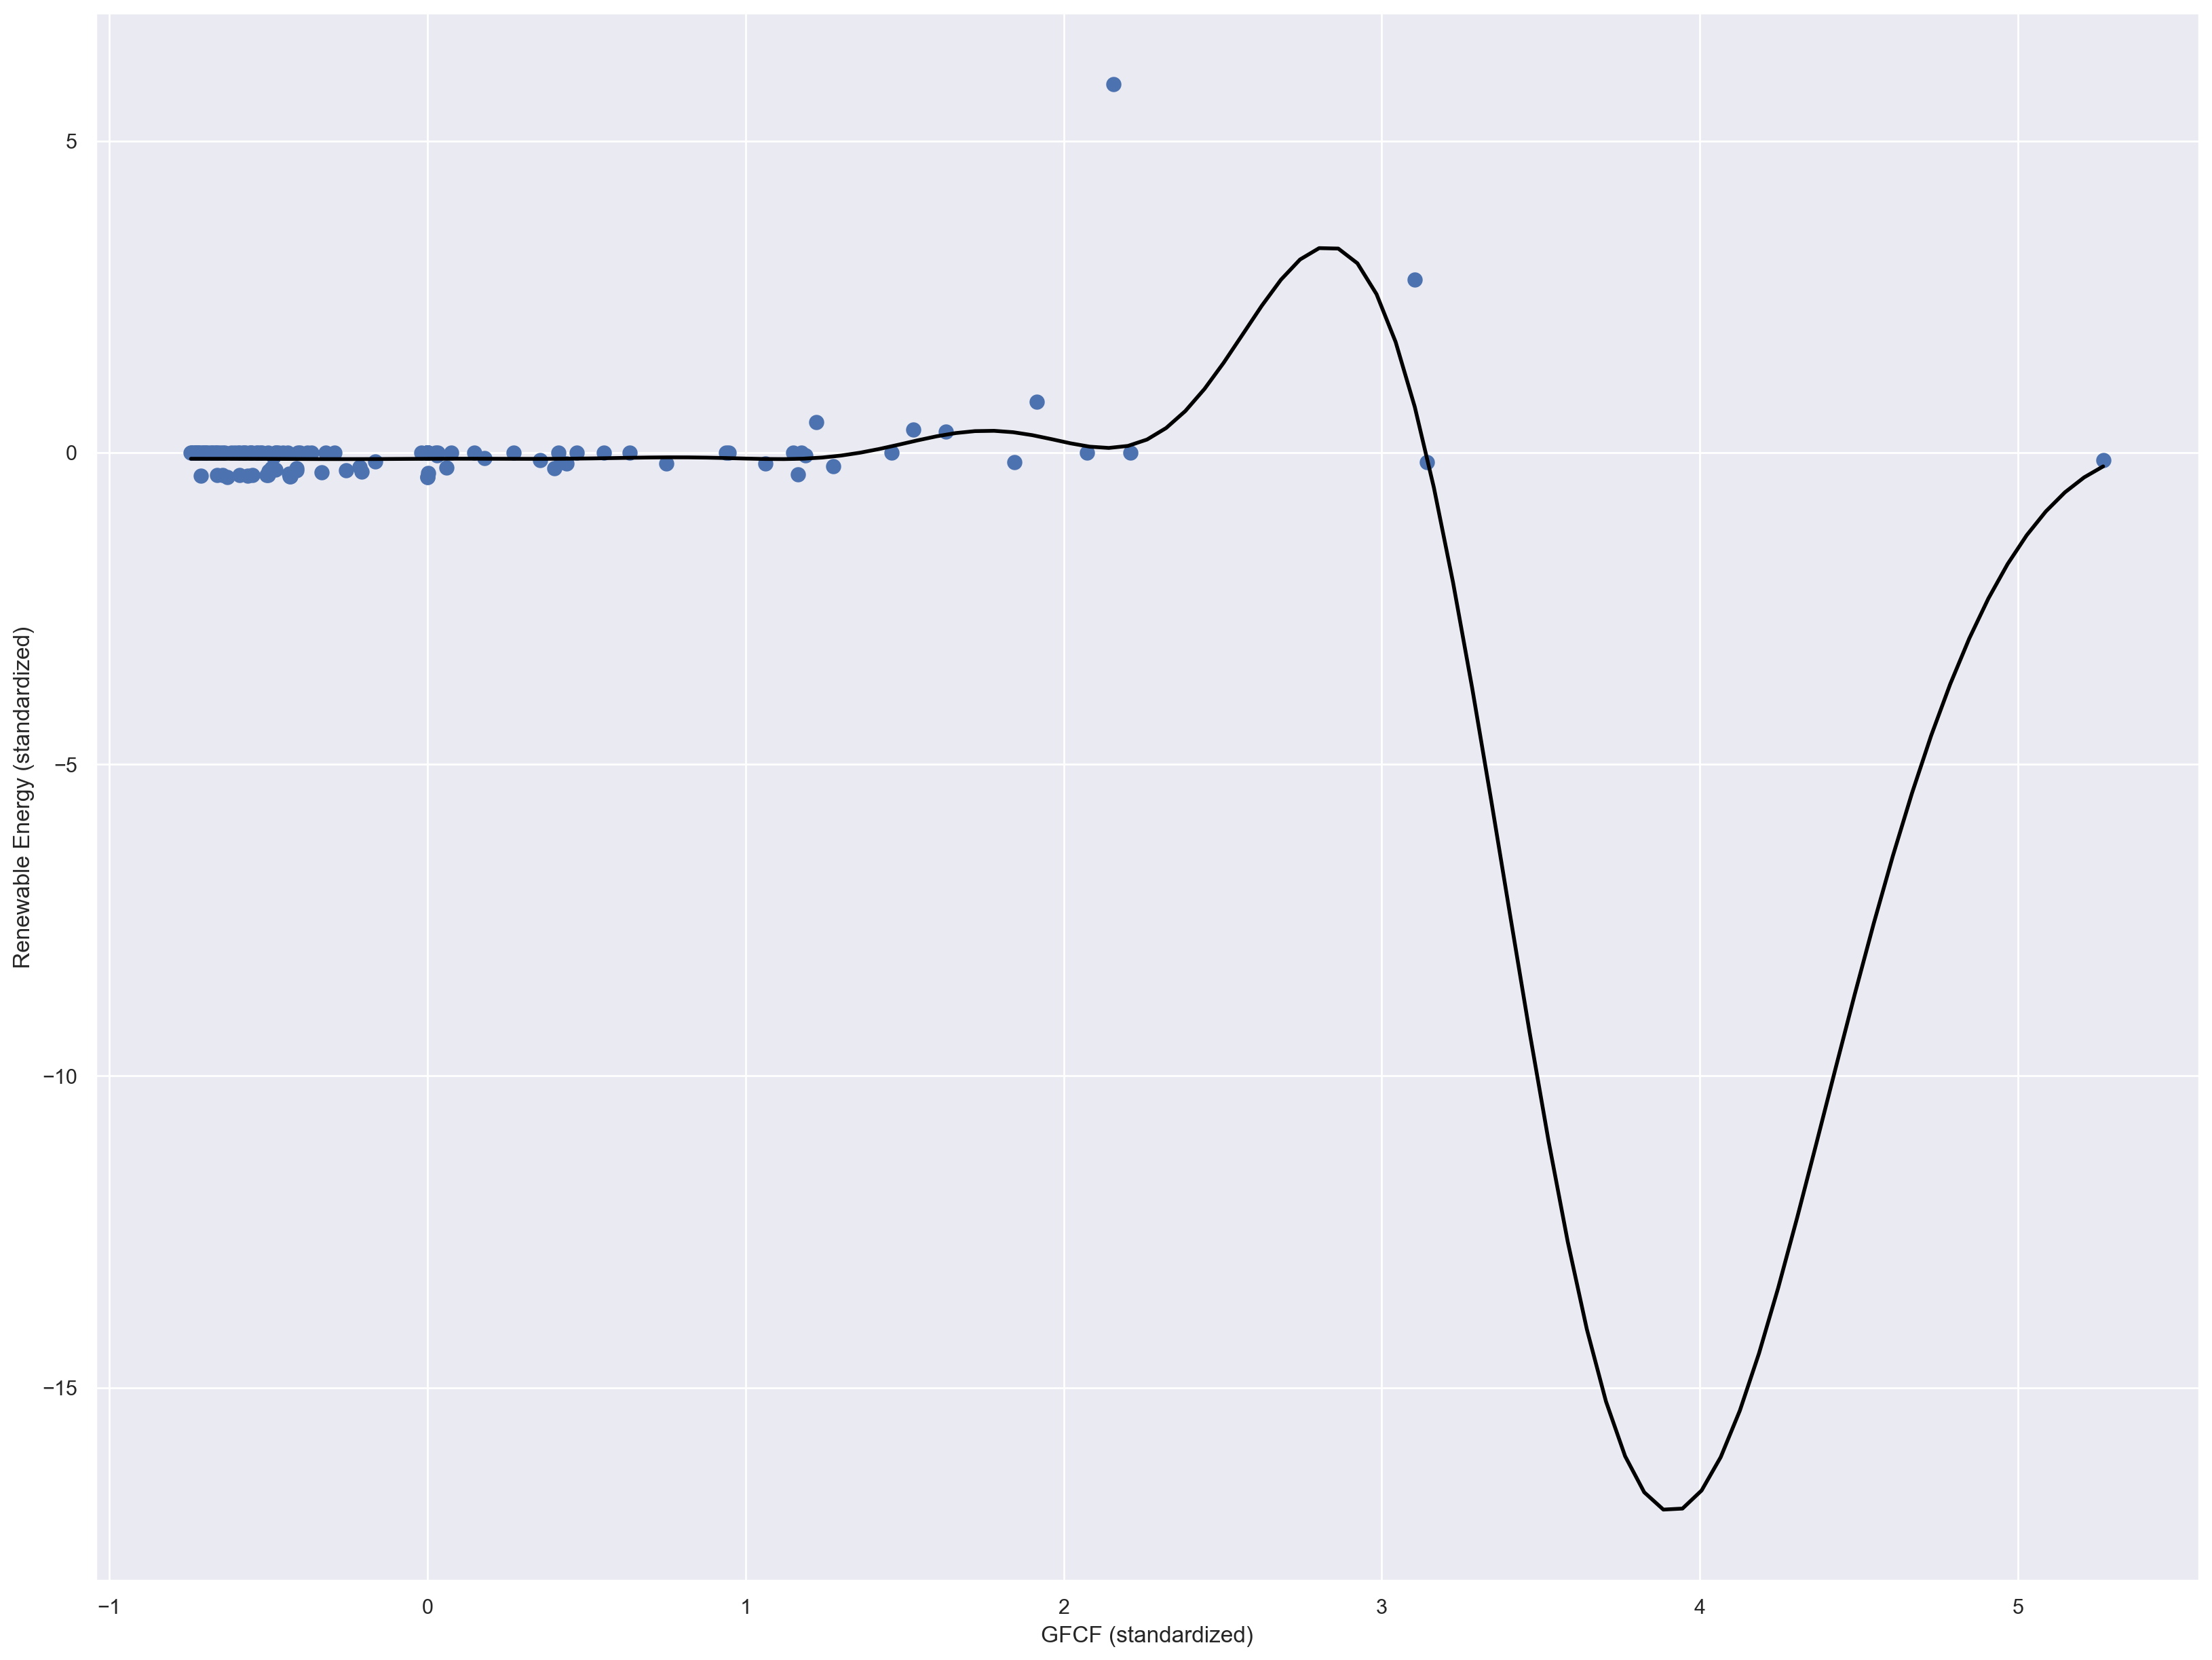

In [147]:
# Set a smaller figure size (adjust as needed)
#plt.figure(figsize=(8, 6))
plt.scatter(Xtrain_std, ytrain_std, s=50);
xVec = np.linspace(Xtrain_std.min(),Xtrain_std.max(),101)
yVec = model.predict(xVec[:, np.newaxis])
plt.plot(xVec, yVec, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');

Trying with different hyperparameters: Now value of C is 1000 rather than 1

R^2 on training data = 0.12
R^2 on filtered test data = -161.52


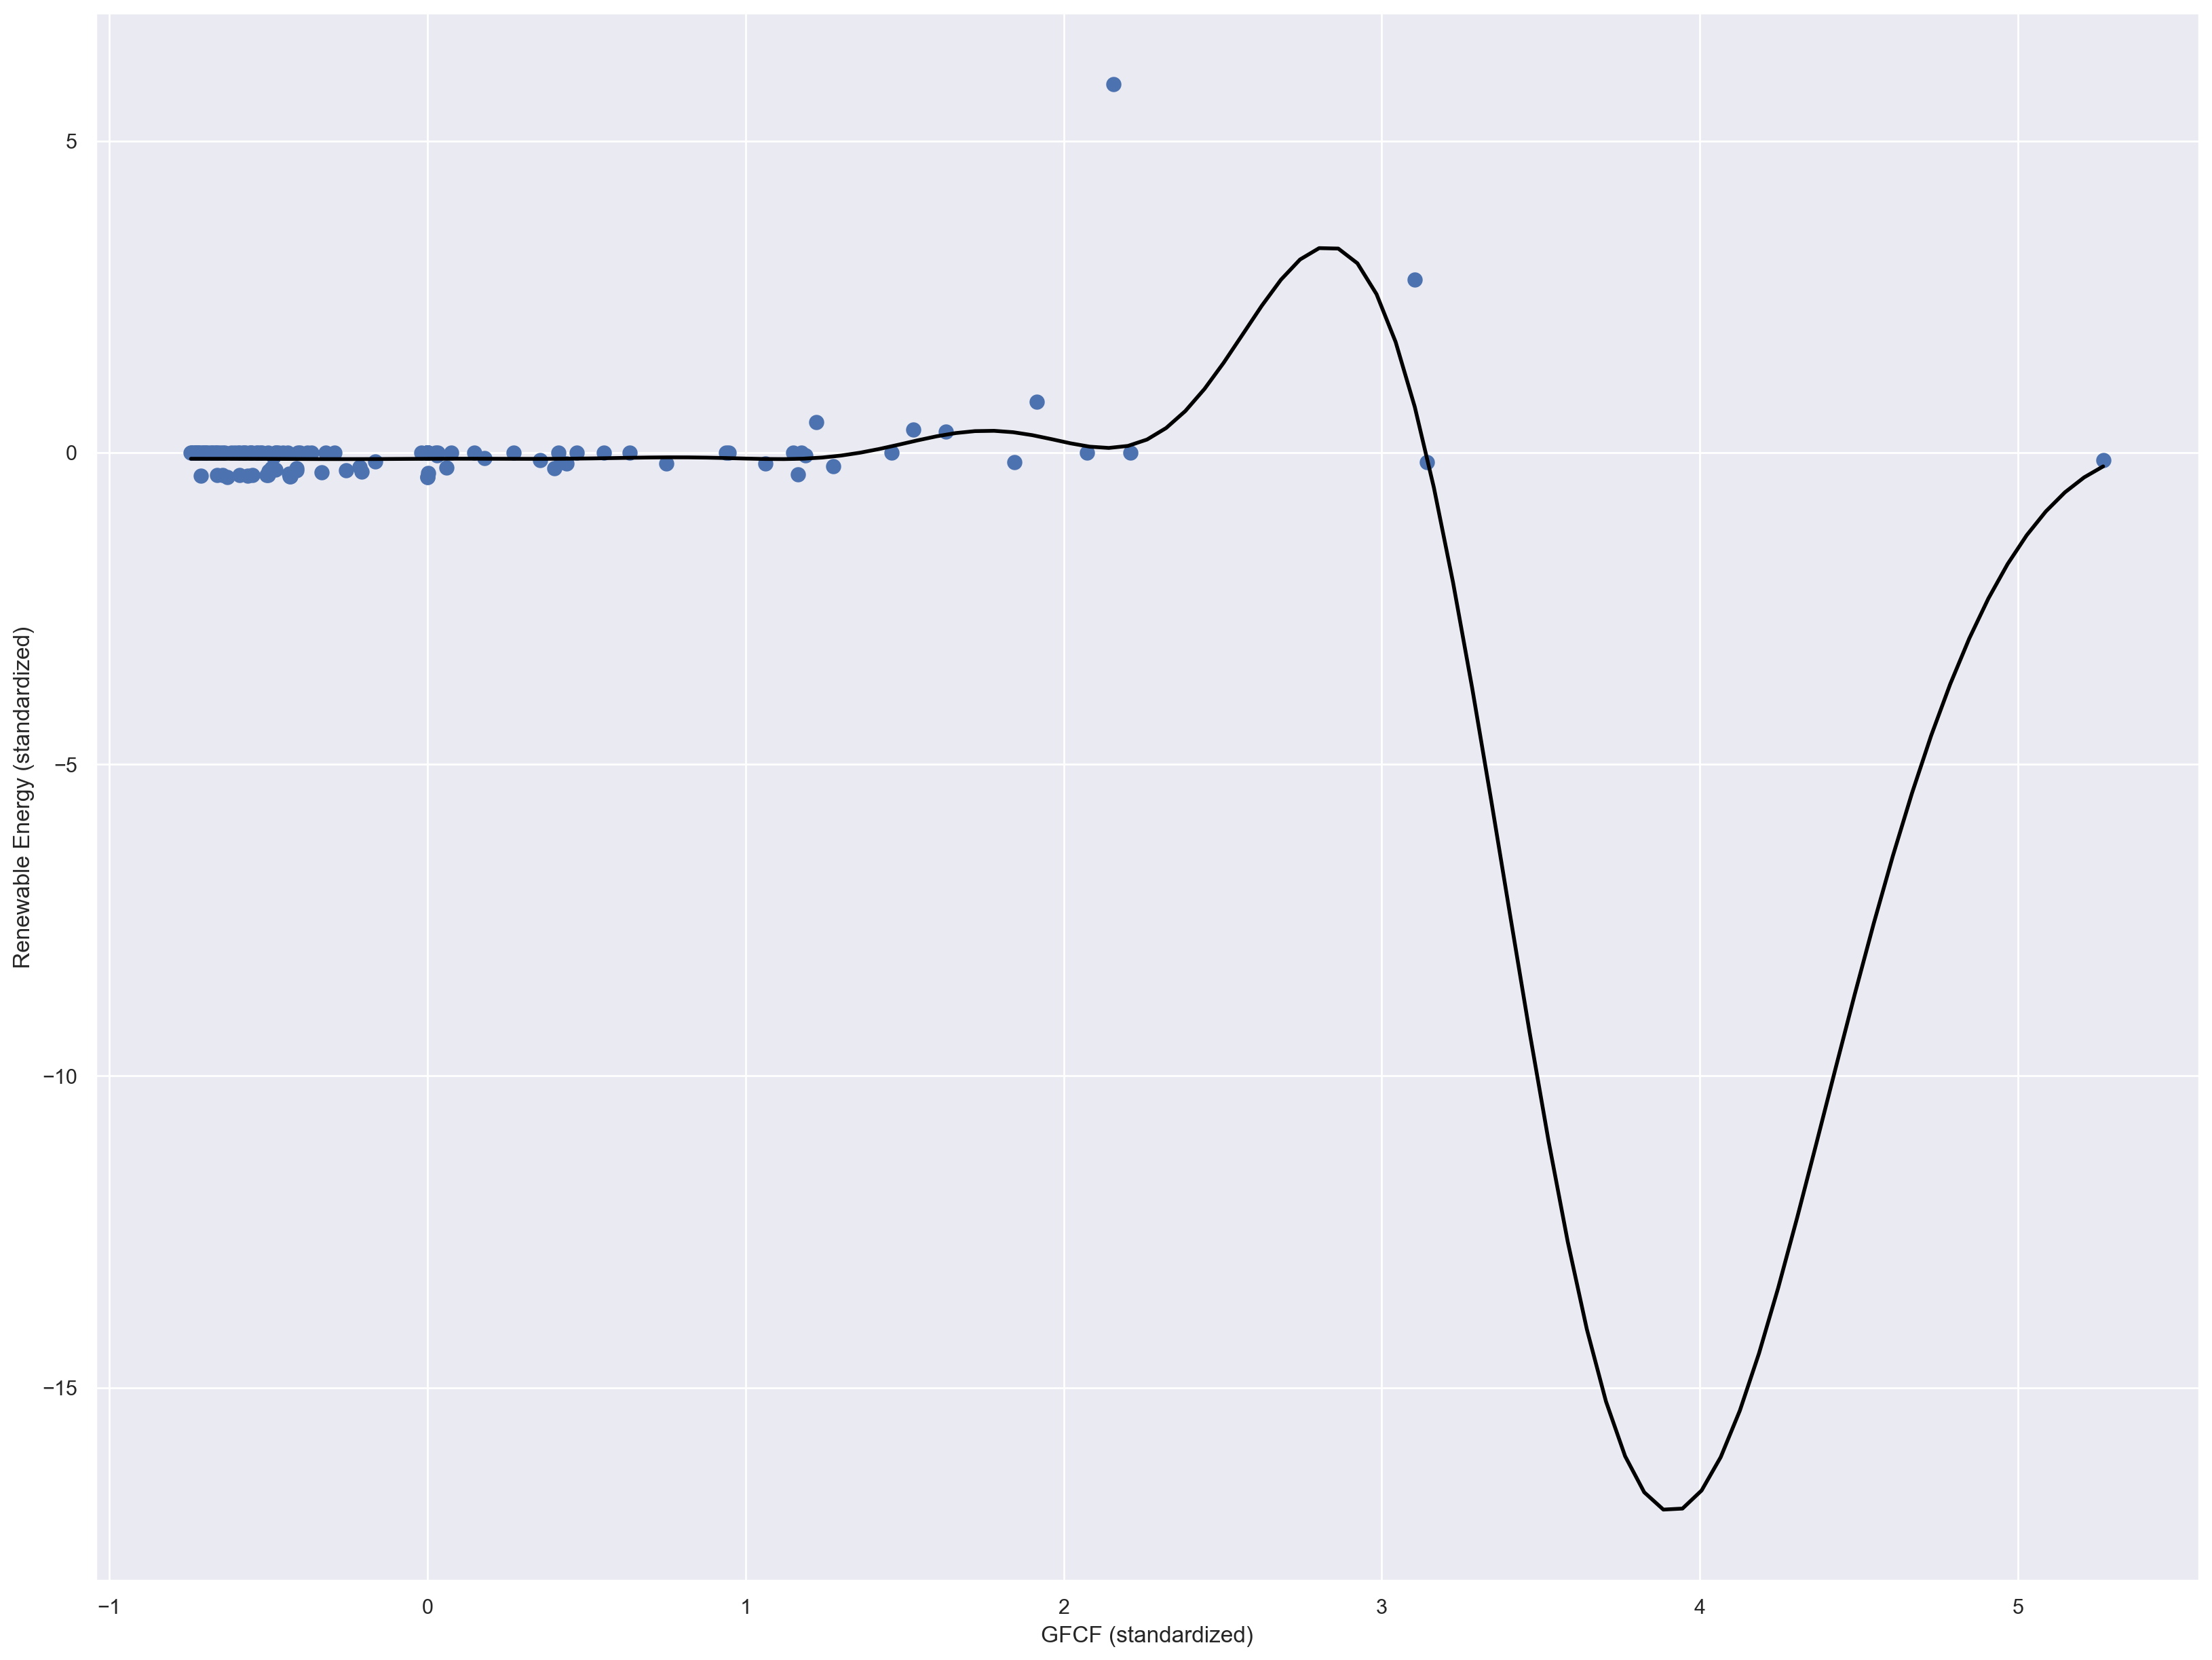

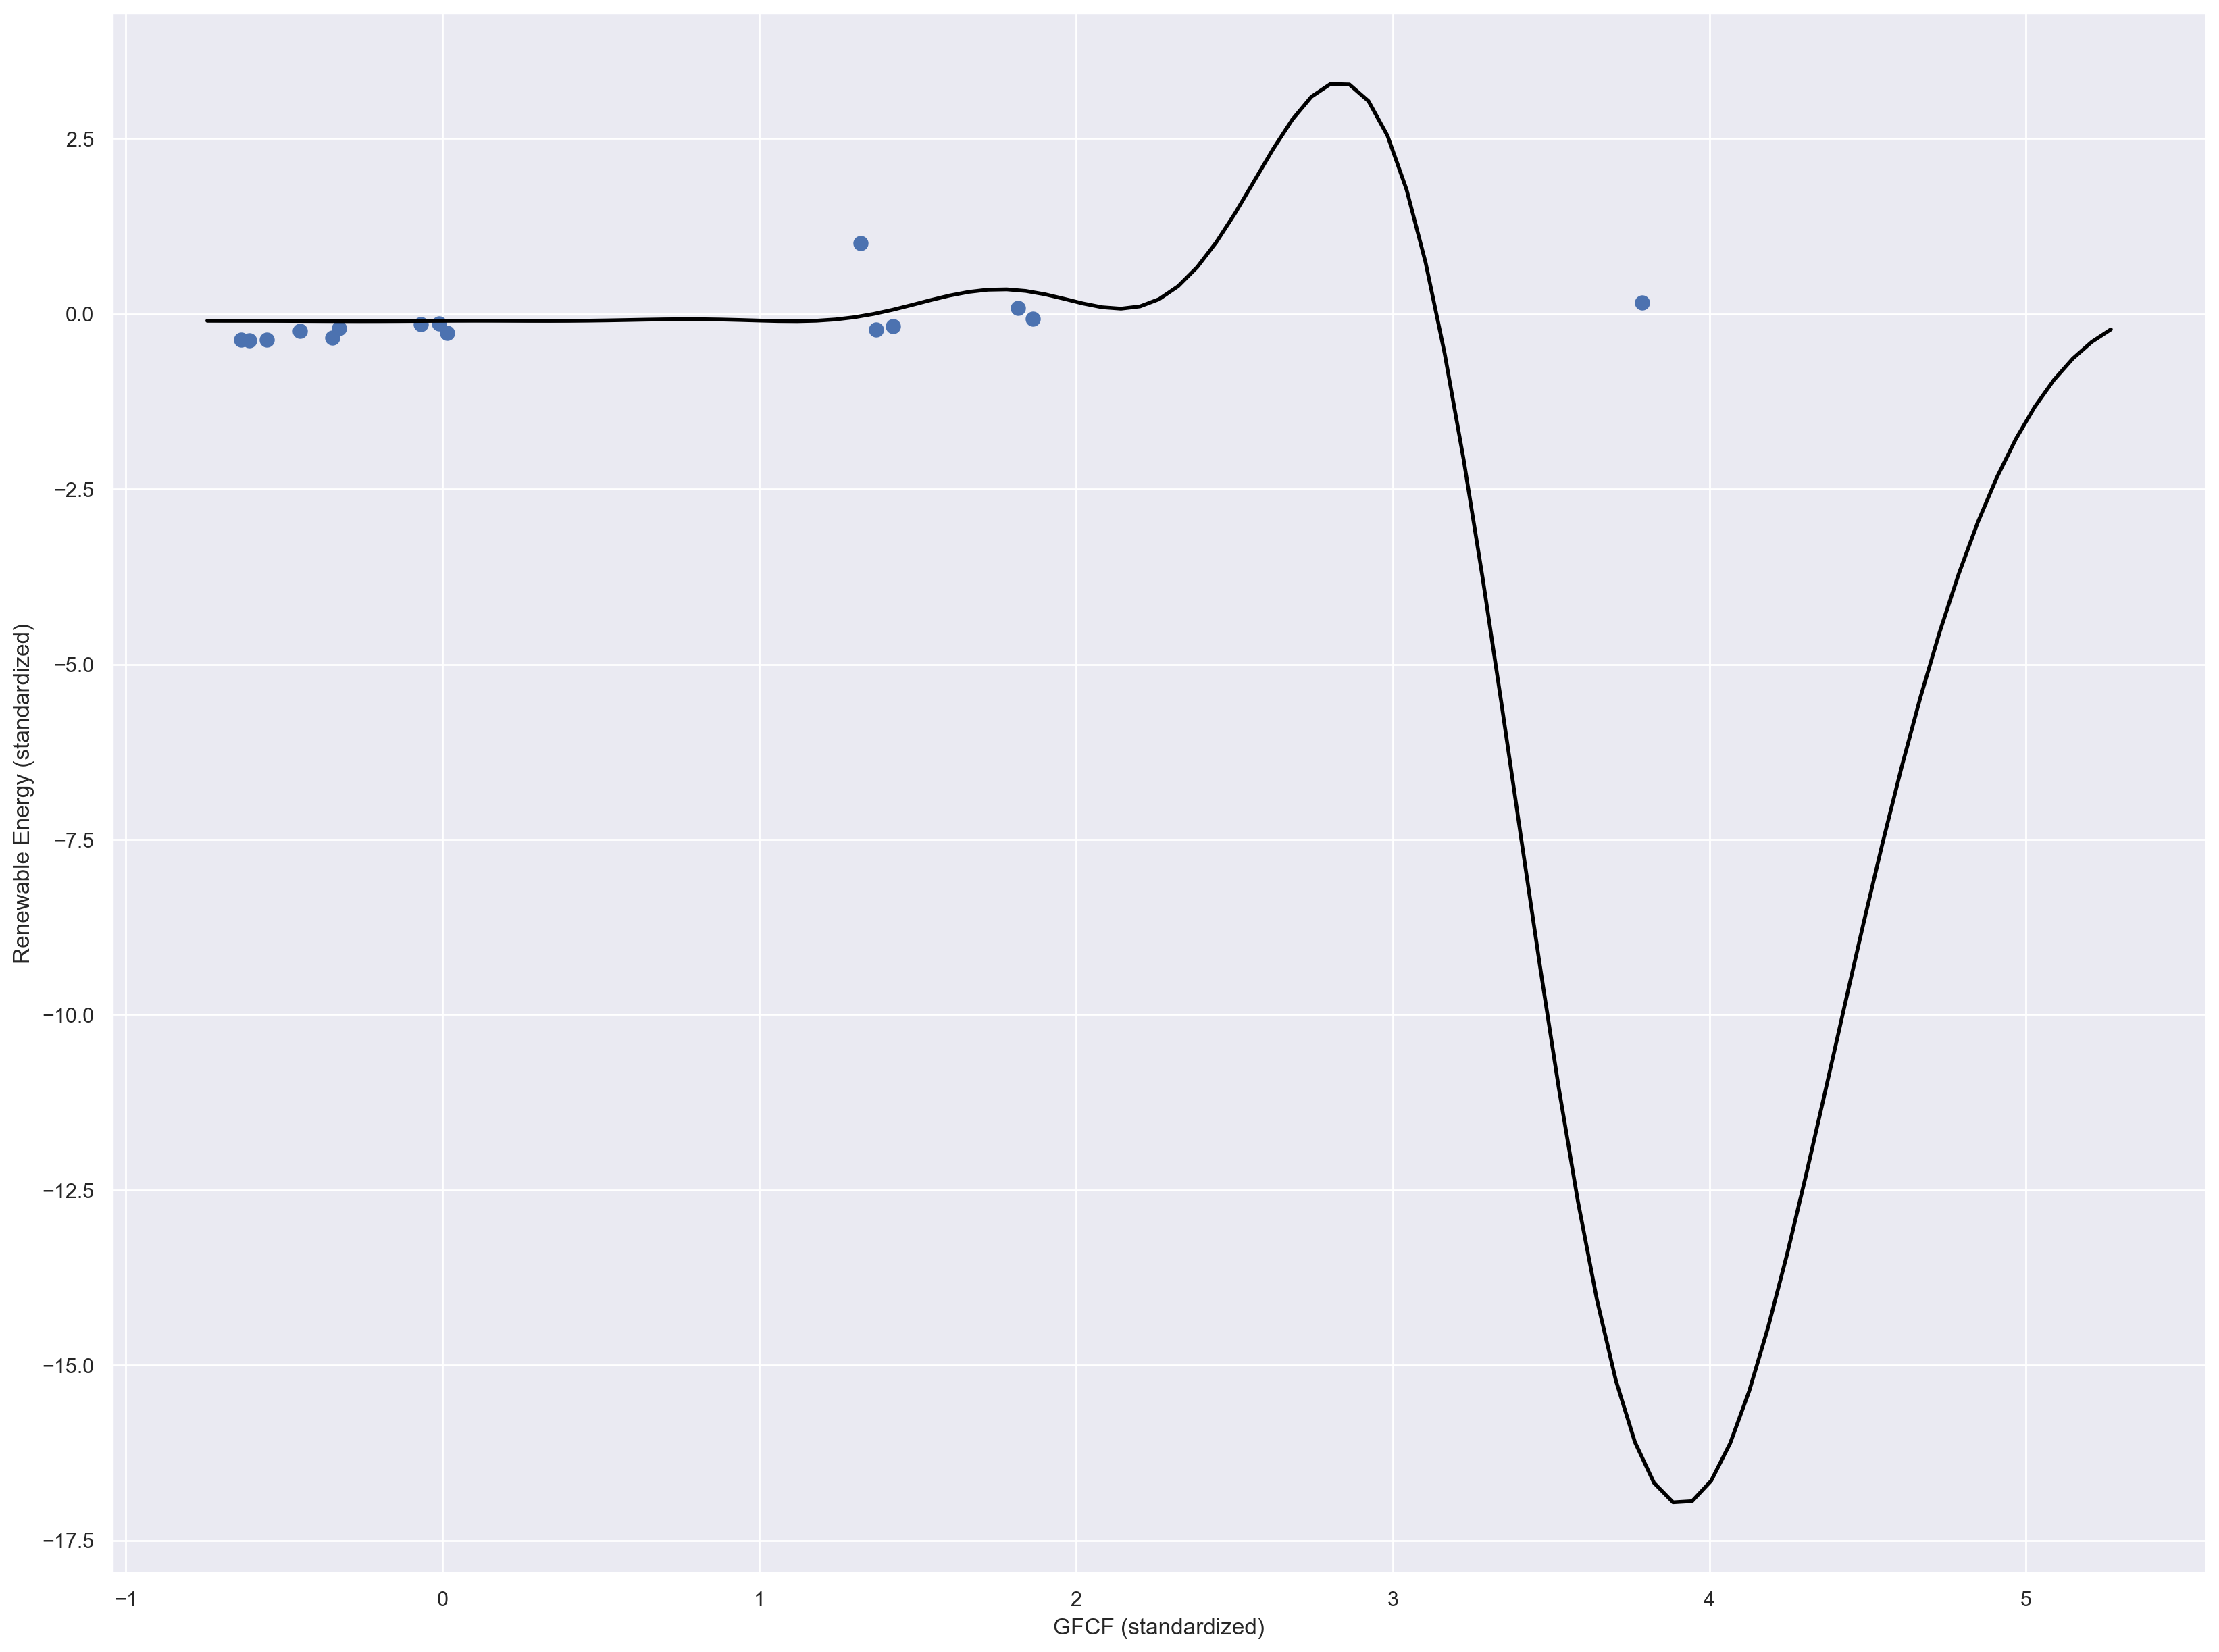

In [143]:
# Find indices of rows with NaN values in ytest_std
nan_indices = np.isnan(ytest_std)

# Remove corresponding rows from Xtest_std and ytest_std
Xtest_std_filtered = Xtest_std[~nan_indices]
ytest_std_filtered = ytest_std[~nan_indices]

# Model with new hyperparameter(s)
model = SVR(C=1000)

# Fit it to the training data
model.fit(Xtrain_std, ytrain_std)

# Apply the fit to the filtered test data
ypred_std_filtered = model.predict(Xtest_std_filtered)

# Evaluate the performance on the training data
print(f"R^2 on training data = {model.score(Xtrain_std, ytrain_std):.2f}")

# Evaluate the performance on the filtered test data
print(f"R^2 on filtered test data = {model.score(Xtest_std_filtered, ytest_std_filtered):.2f}")

# Show the fit on the training data
fig = plt.figure();
plt.scatter(Xtrain_std, ytrain_std, s=50);
xVec = np.linspace(Xtrain_std.min(), Xtrain_std.max(), 101)
yVec = model.predict(xVec[:, np.newaxis])
plt.plot(xVec, yVec, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');

# Show the fit on the filtered test data
fig = plt.figure();
plt.scatter(Xtest_std_filtered, ytest_std_filtered, s=50);
plt.plot(xVec, yVec, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');


Using a polynomial kernel rather than the default RBF one:

R^2 on training data = -0.03
R^2 on filtered test data = 0.01


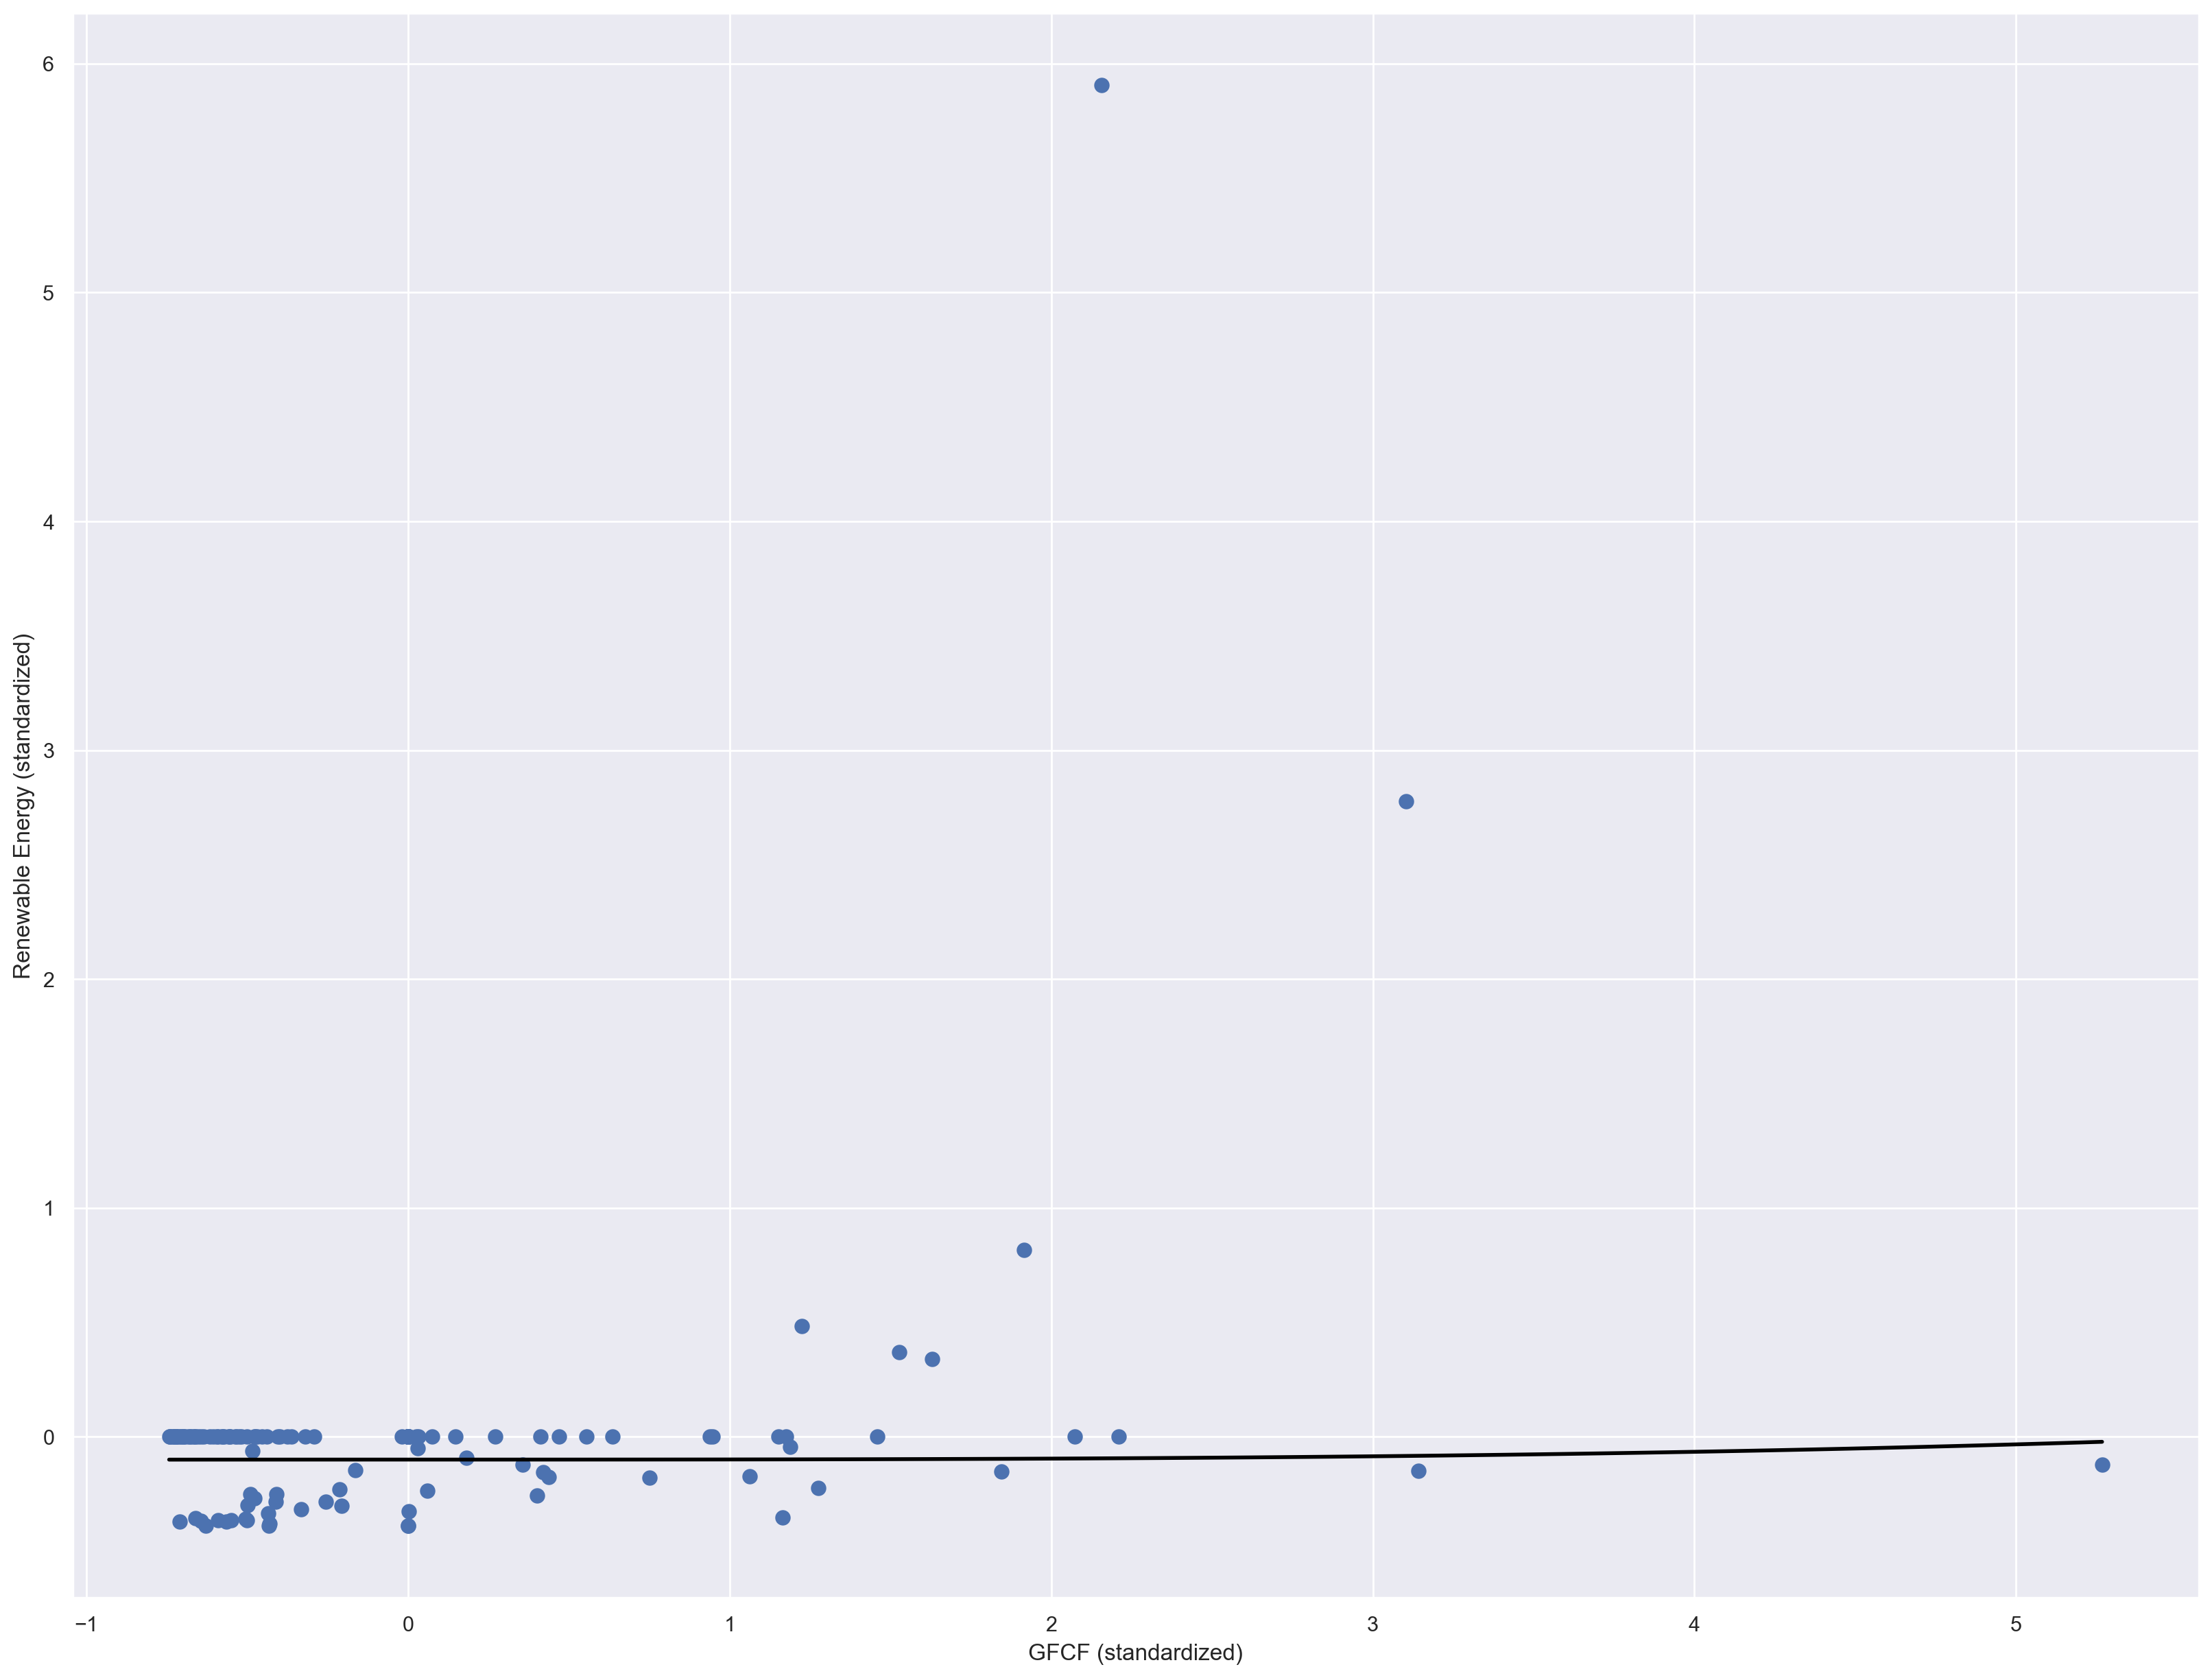

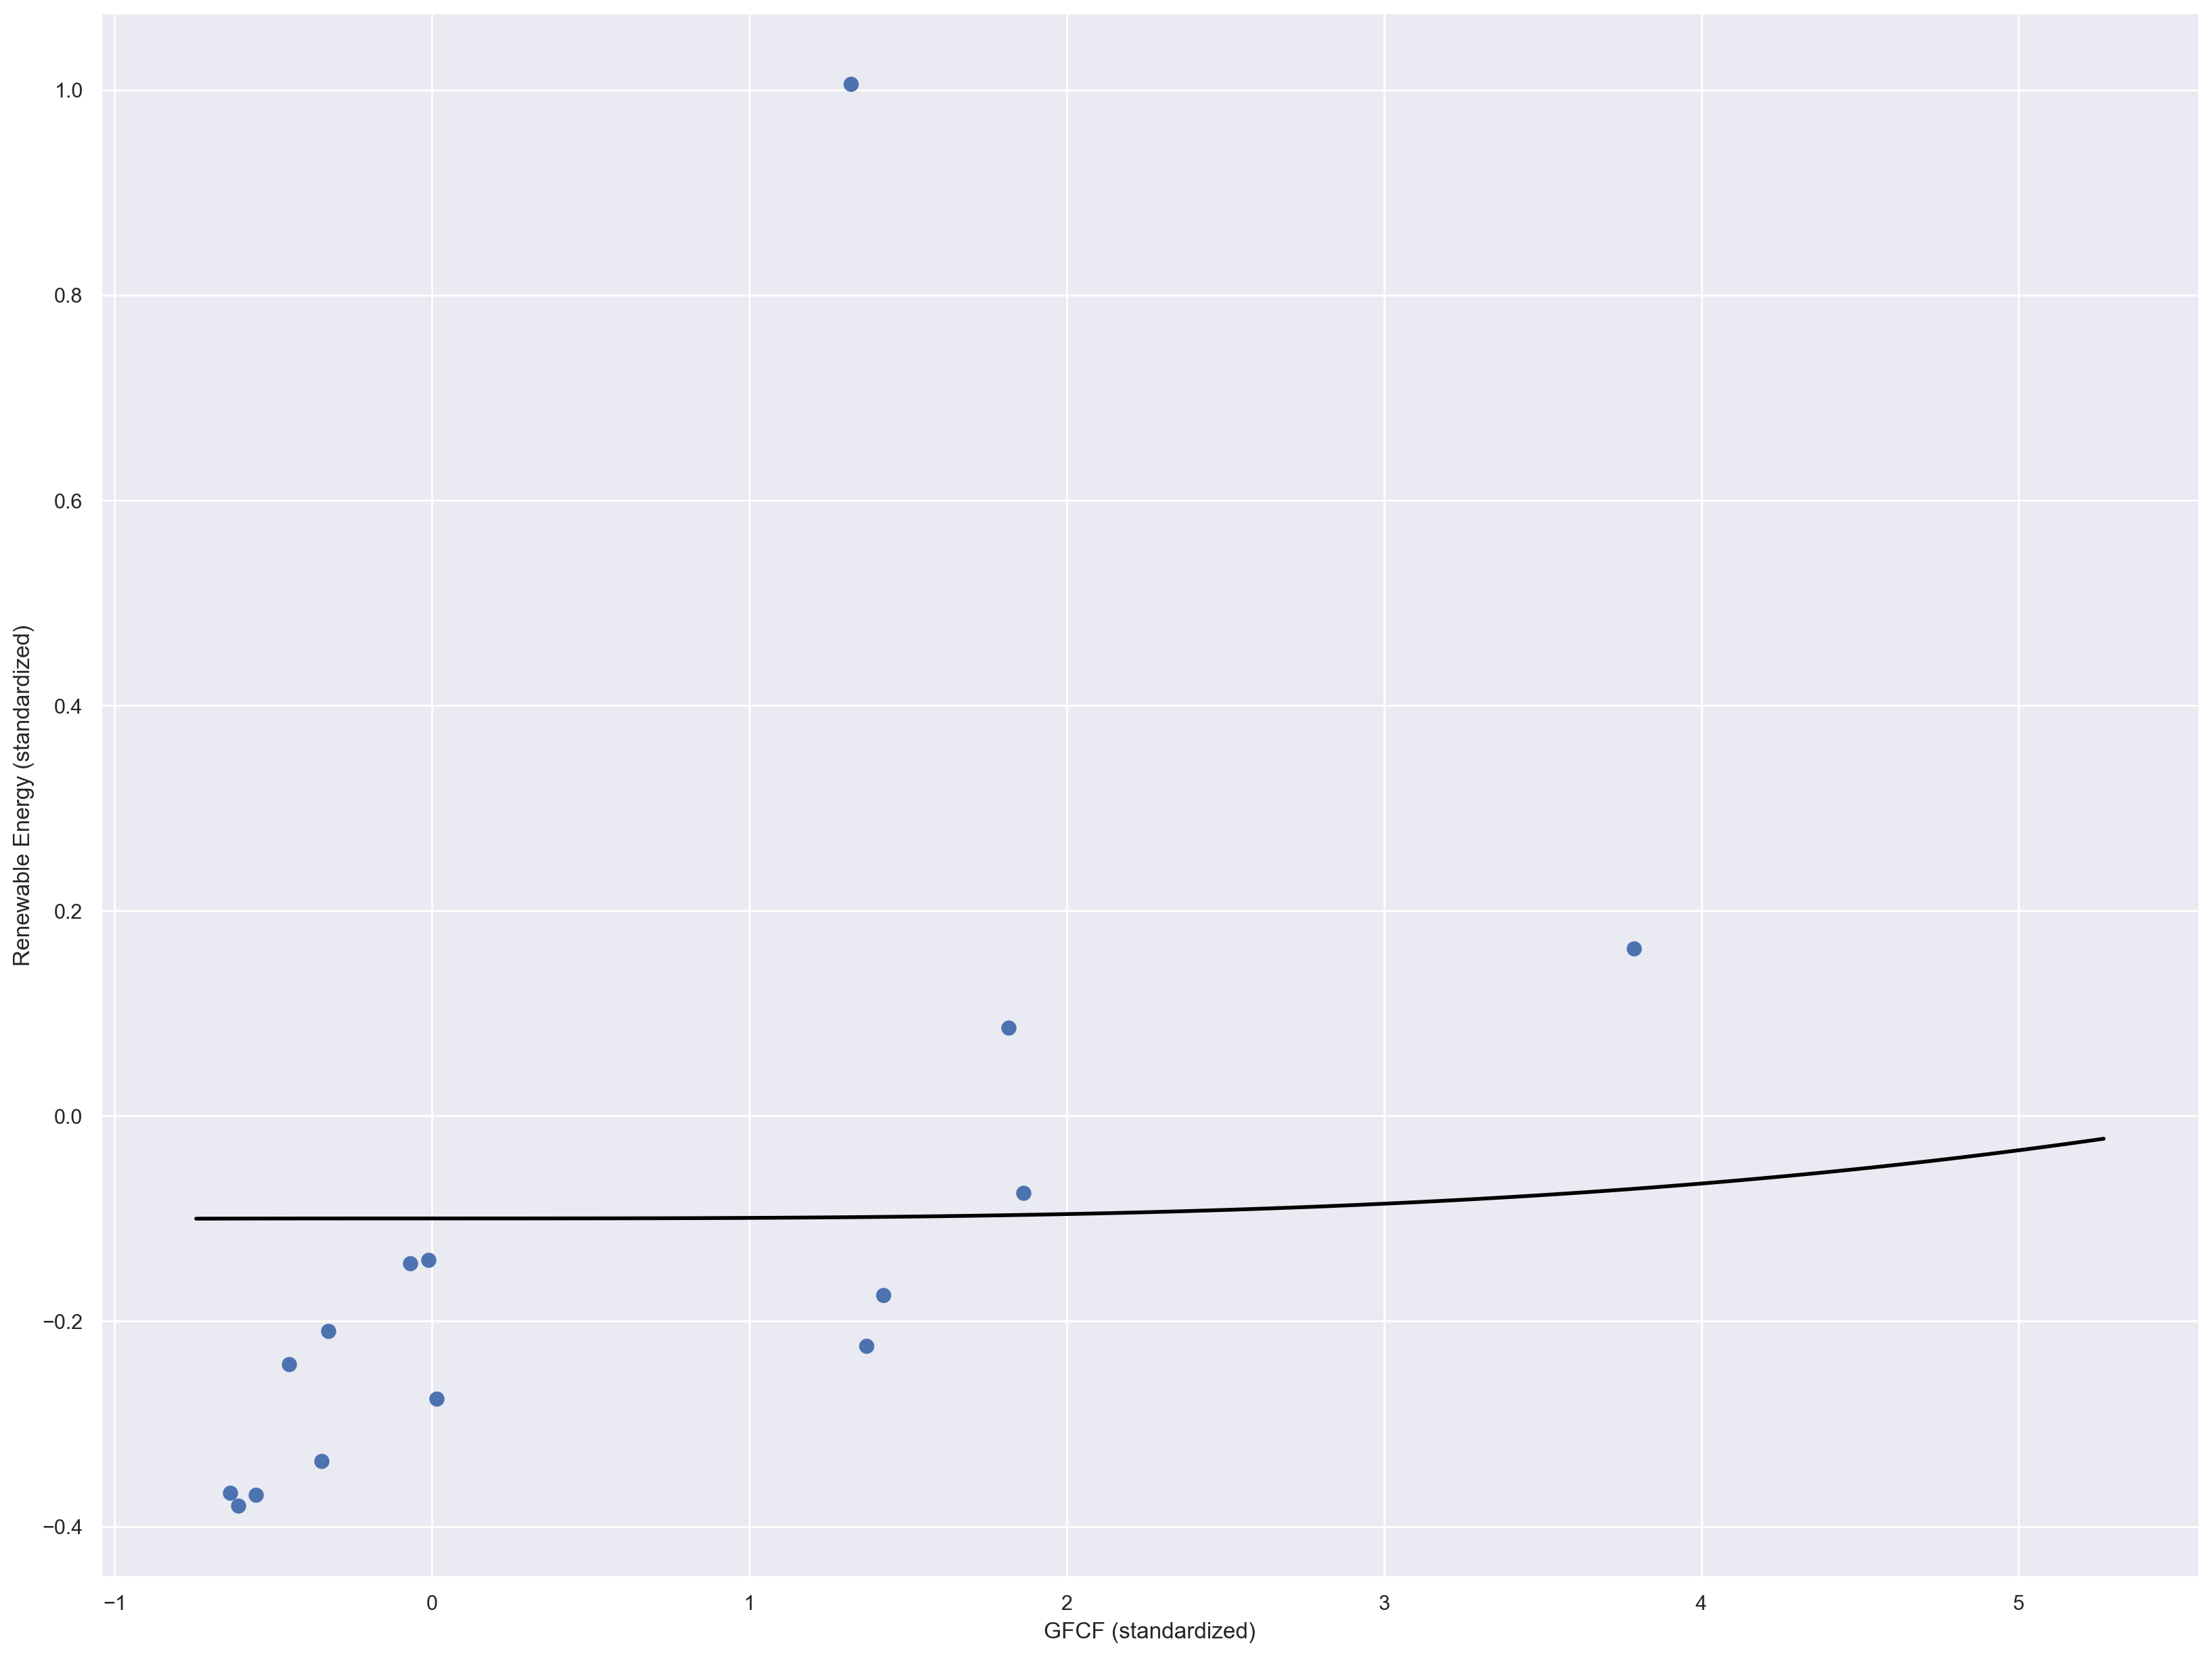

In [148]:
# Find indices of rows with NaN values in ytest_std
nan_indices_poly = np.isnan(ytest_std)

# Remove corresponding rows from Xtest_std and ytest_std
Xtest_std_filtered_poly = Xtest_std[~nan_indices_poly]
ytest_std_filtered_poly = ytest_std[~nan_indices_poly]

# Model with new hyperparameter(s)
model_poly = SVR(kernel='poly')

# Fit it to the training data
model_poly.fit(Xtrain_std, ytrain_std)

# Apply the fit to the filtered test data
ypred_std_filtered_poly = model_poly.predict(Xtest_std_filtered_poly)

# Evaluate the performance on the training data
print(f"R^2 on training data = {model_poly.score(Xtrain_std, ytrain_std):.2f}")

# Evaluate the performance on the filtered test data
print(f"R^2 on filtered test data = {model_poly.score(Xtest_std_filtered_poly, ytest_std_filtered_poly):.2f}")

# Show the fit on the training data
fig = plt.figure();
plt.scatter(Xtrain_std, ytrain_std, s=50);
xVec_poly = np.linspace(Xtrain_std.min(), Xtrain_std.max(), 101)
yVec_poly = model_poly.predict(xVec_poly[:, np.newaxis])
plt.plot(xVec_poly, yVec_poly, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');

# Show the fit on the filtered test data
fig = plt.figure();
plt.scatter(Xtest_std_filtered_poly, ytest_std_filtered_poly, s=50);
plt.plot(xVec_poly, yVec_poly, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');


Using a linear kernel rather than the default RBF one:

R^2 on training data = -0.01
R^2 on filtered test data = 0.04


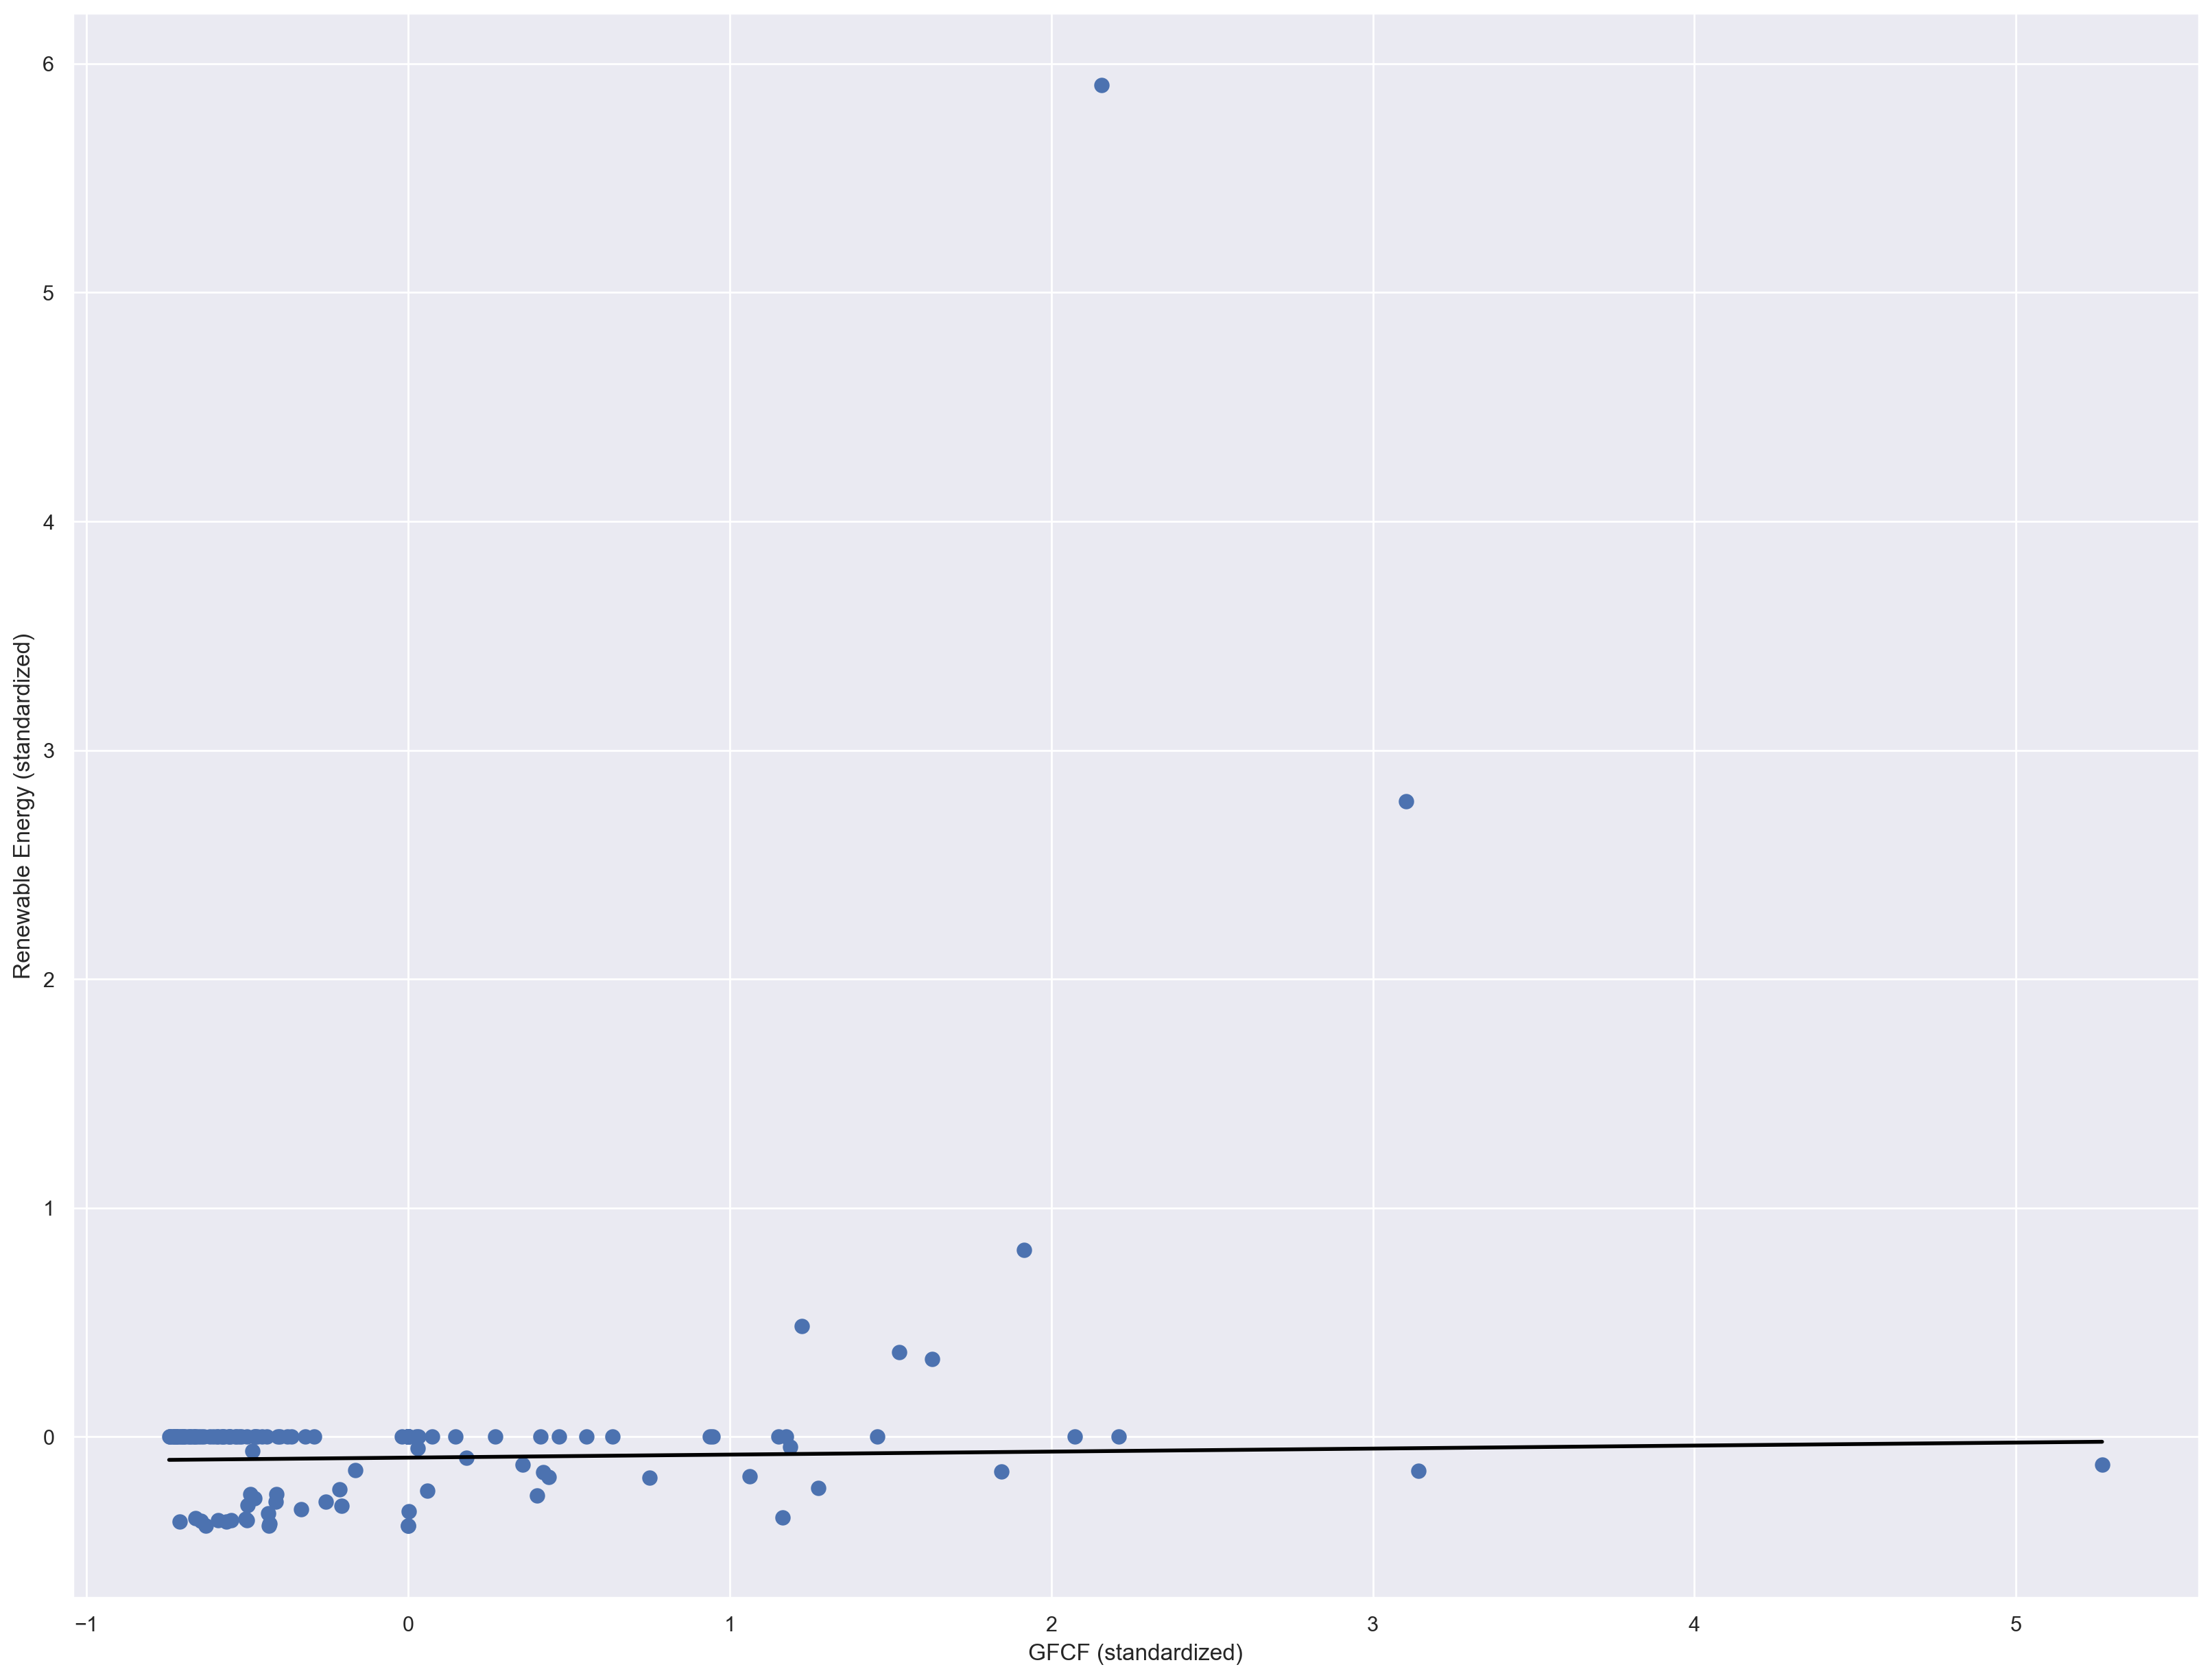

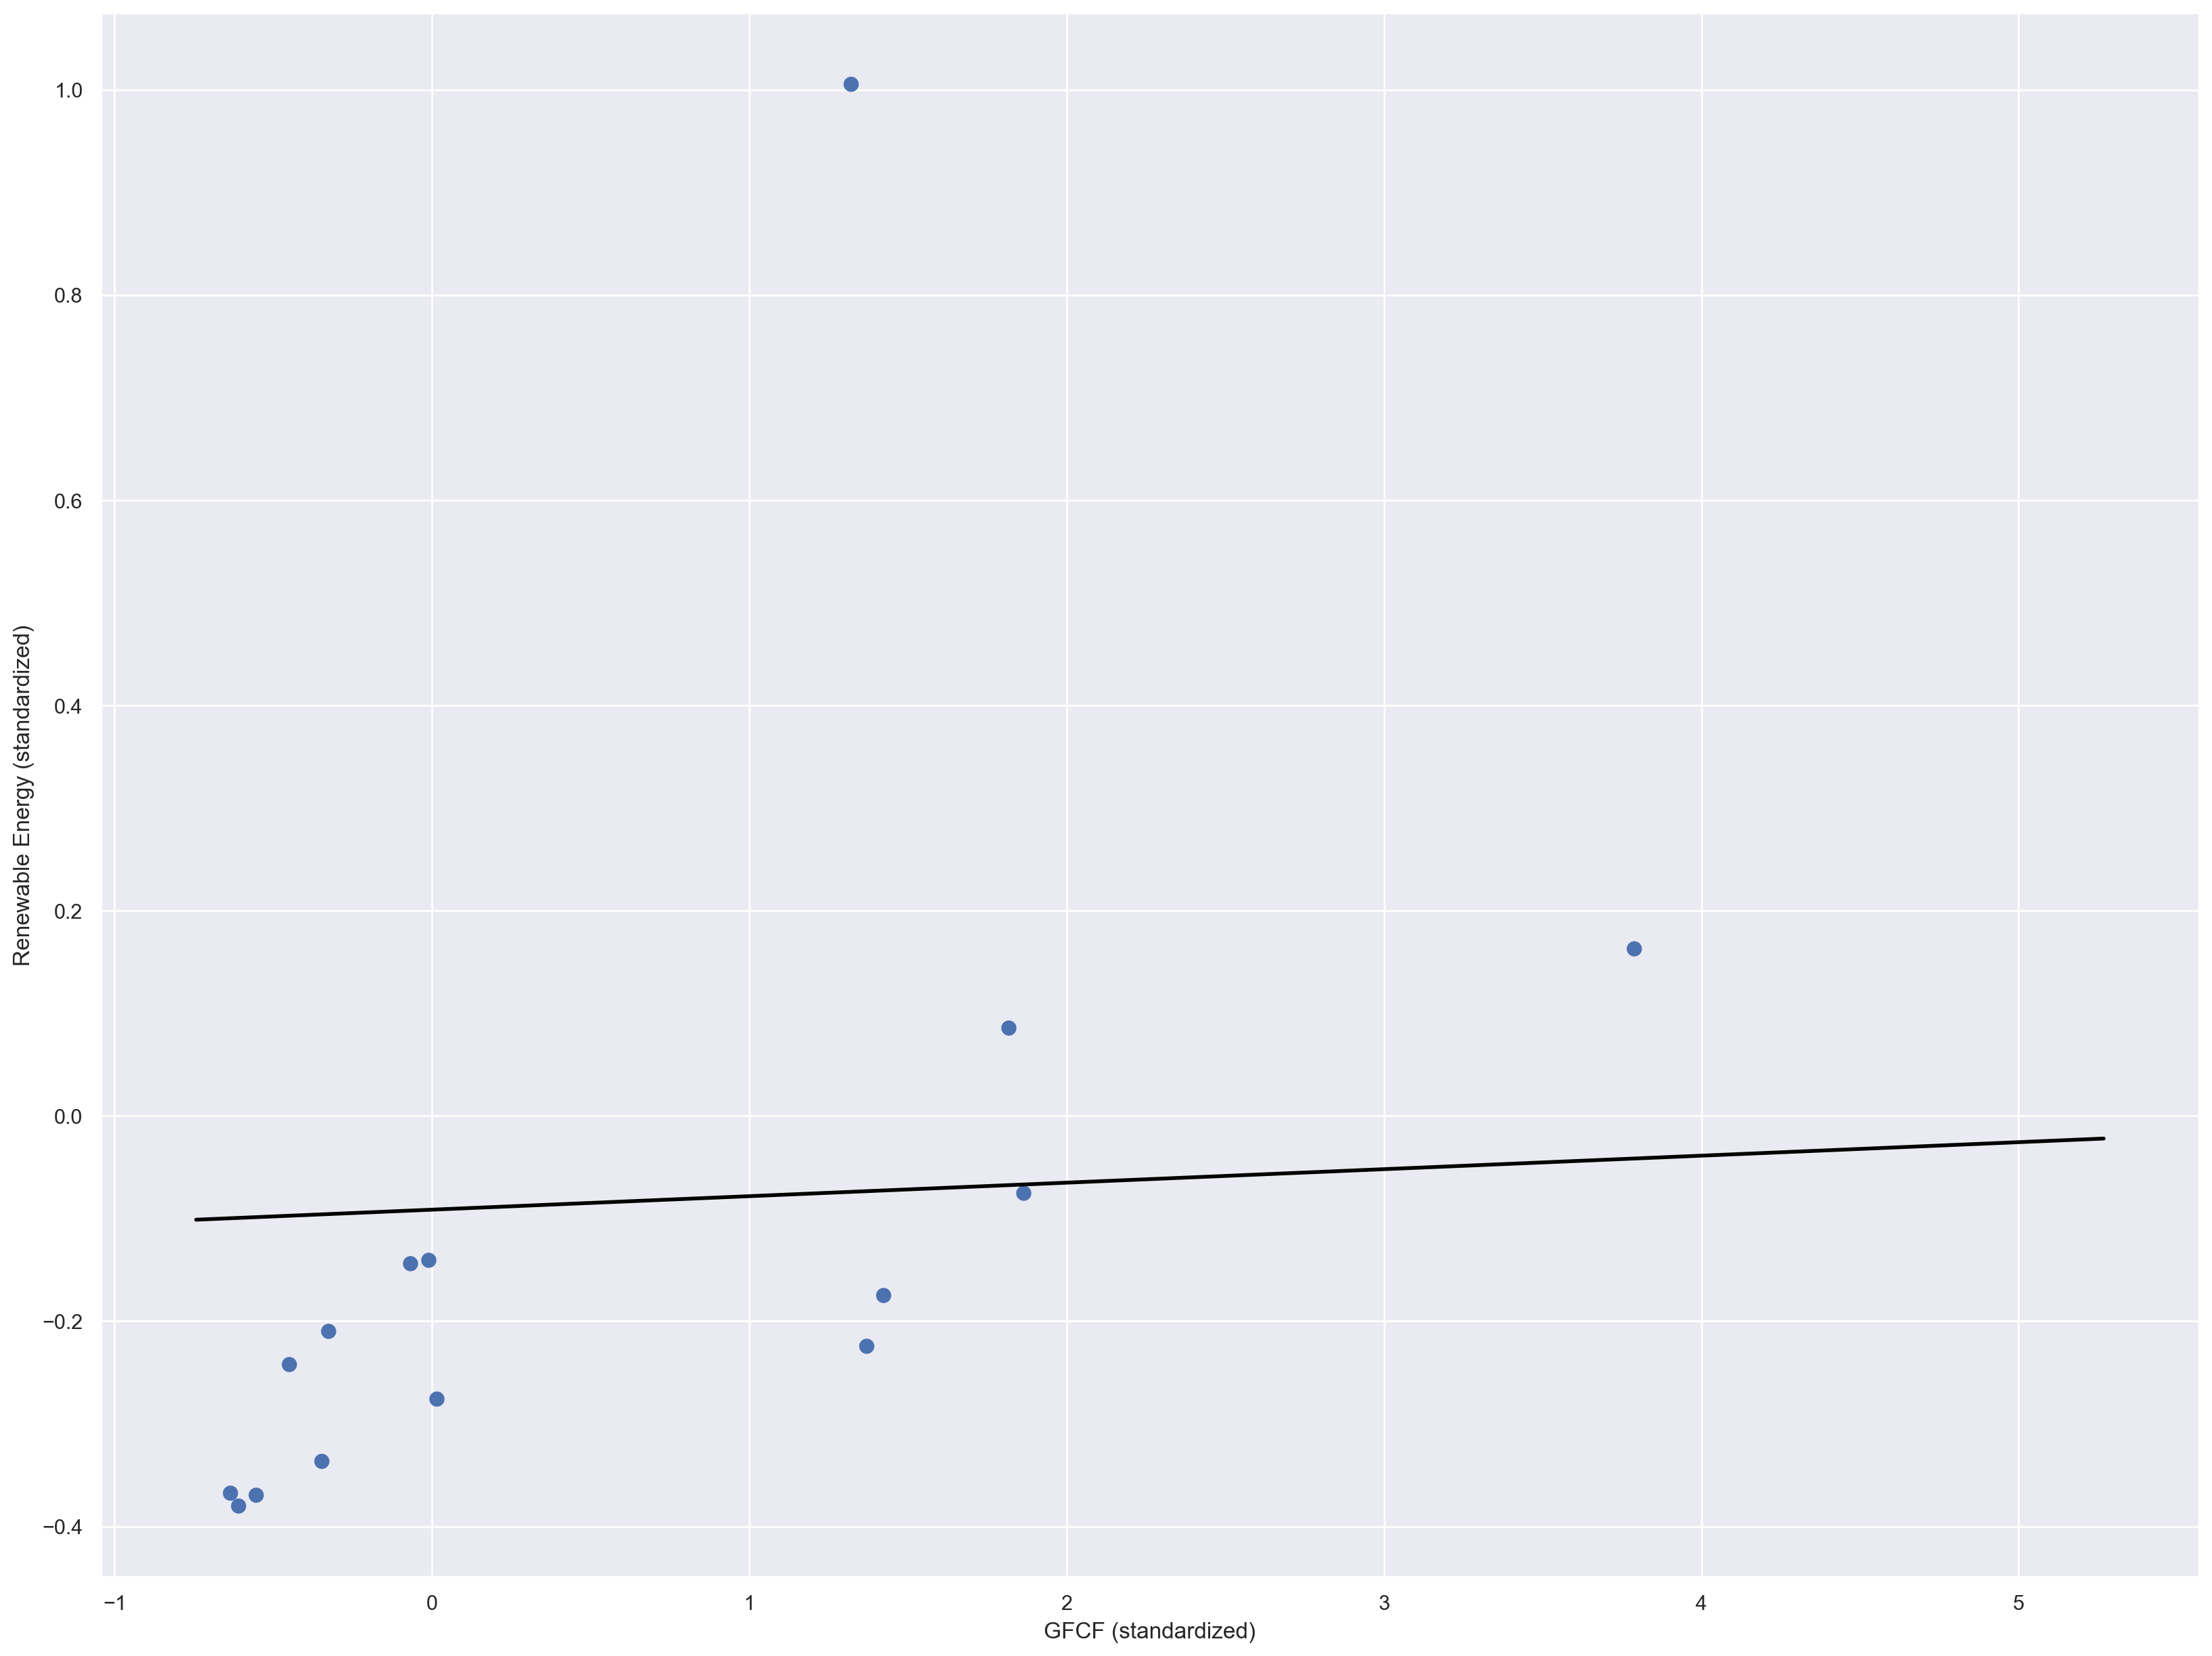

In [149]:
# Find indices of rows with NaN values in ytest_std
nan_indices_linear = np.isnan(ytest_std)

# Remove corresponding rows from Xtest_std and ytest_std
Xtest_std_filtered_linear = Xtest_std[~nan_indices_linear]
ytest_std_filtered_linear = ytest_std[~nan_indices_linear]

# Model with new hyperparameter(s)
model_linear = SVR(kernel='linear')

# Fit it to the training data
model_linear.fit(Xtrain_std, ytrain_std)

# Apply the fit to the filtered test data
ypred_std_filtered_linear = model_linear.predict(Xtest_std_filtered_linear)

# Evaluate the performance on the training data
print(f"R^2 on training data = {model_linear.score(Xtrain_std, ytrain_std):.2f}")

# Evaluate the performance on the filtered test data
print(f"R^2 on filtered test data = {model_linear.score(Xtest_std_filtered_linear, ytest_std_filtered_linear):.2f}")

# Show the fit on the training data
fig = plt.figure();
plt.scatter(Xtrain_std, ytrain_std, s=50);
xVec_linear = np.linspace(Xtrain_std.min(), Xtrain_std.max(), 101)
yVec_linear = model_linear.predict(xVec_linear[:, np.newaxis])
plt.plot(xVec_linear, yVec_linear, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');

# Show the fit on the filtered test data
fig = plt.figure();
plt.scatter(Xtest_std_filtered_linear, ytest_std_filtered_linear, s=50);
plt.plot(xVec_linear, yVec_linear, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');


## Using random-forest regression

R^2 on training data = 0.75
R^2 on filtered test data = -0.10


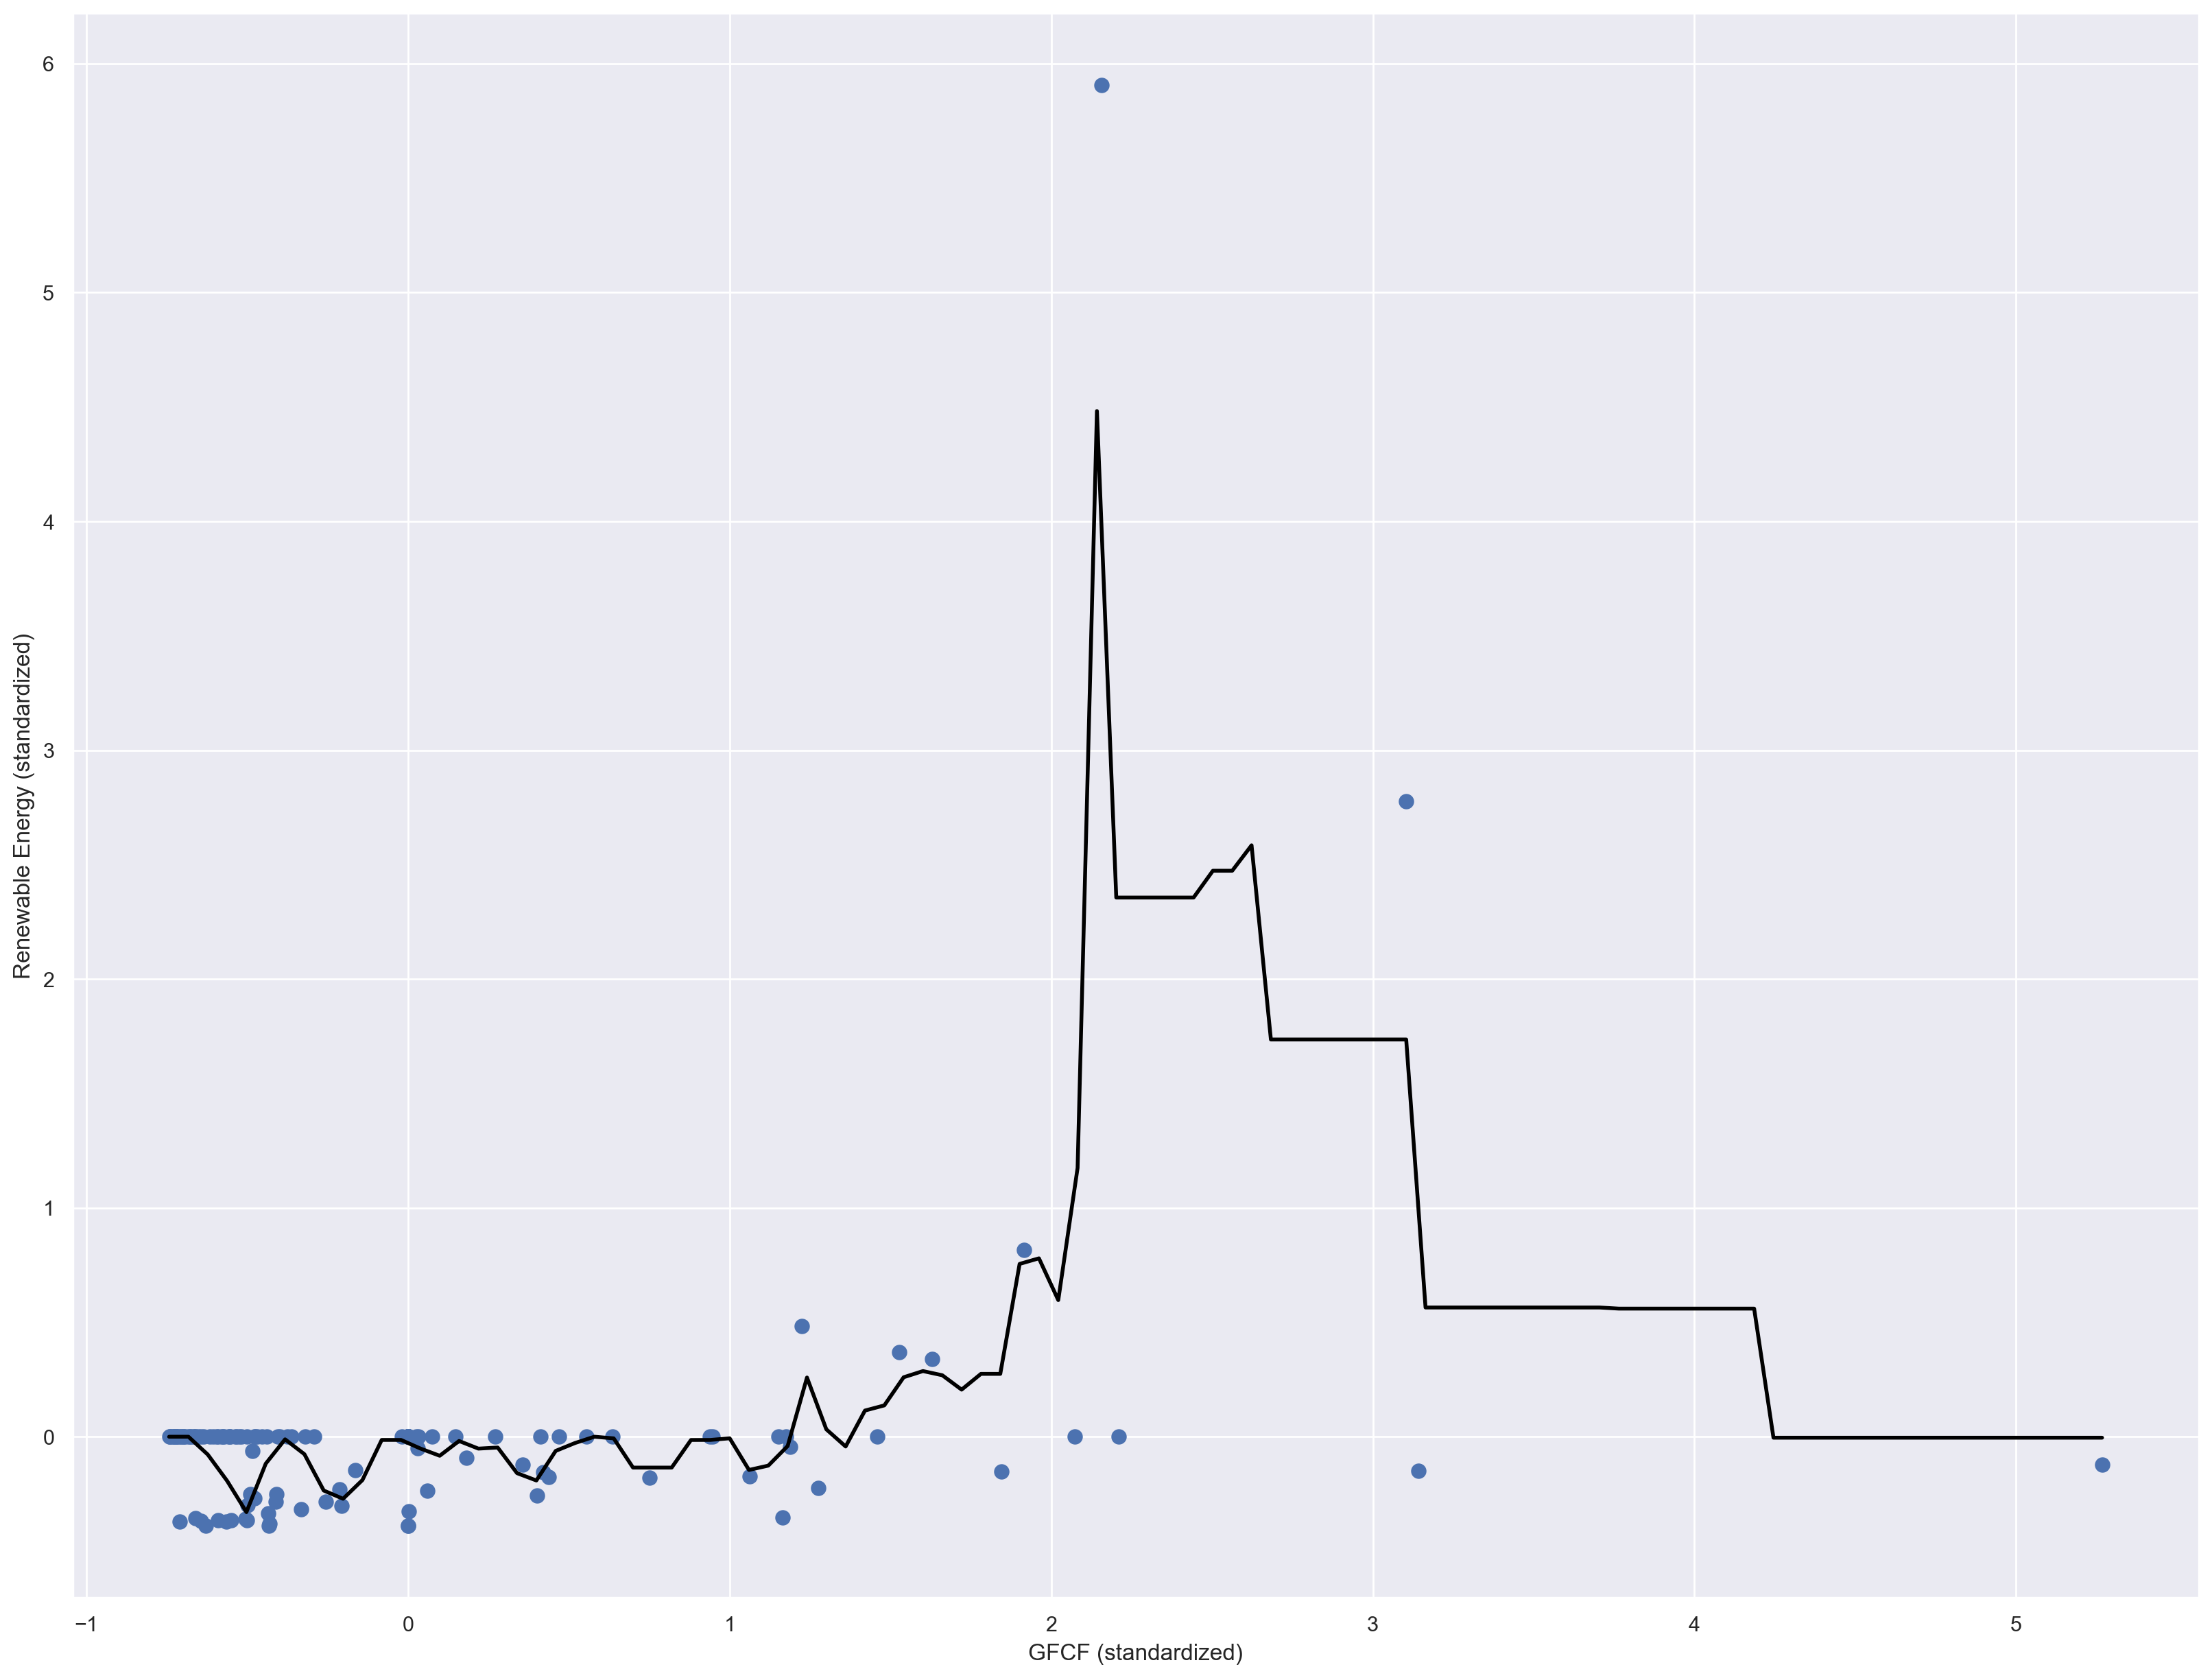

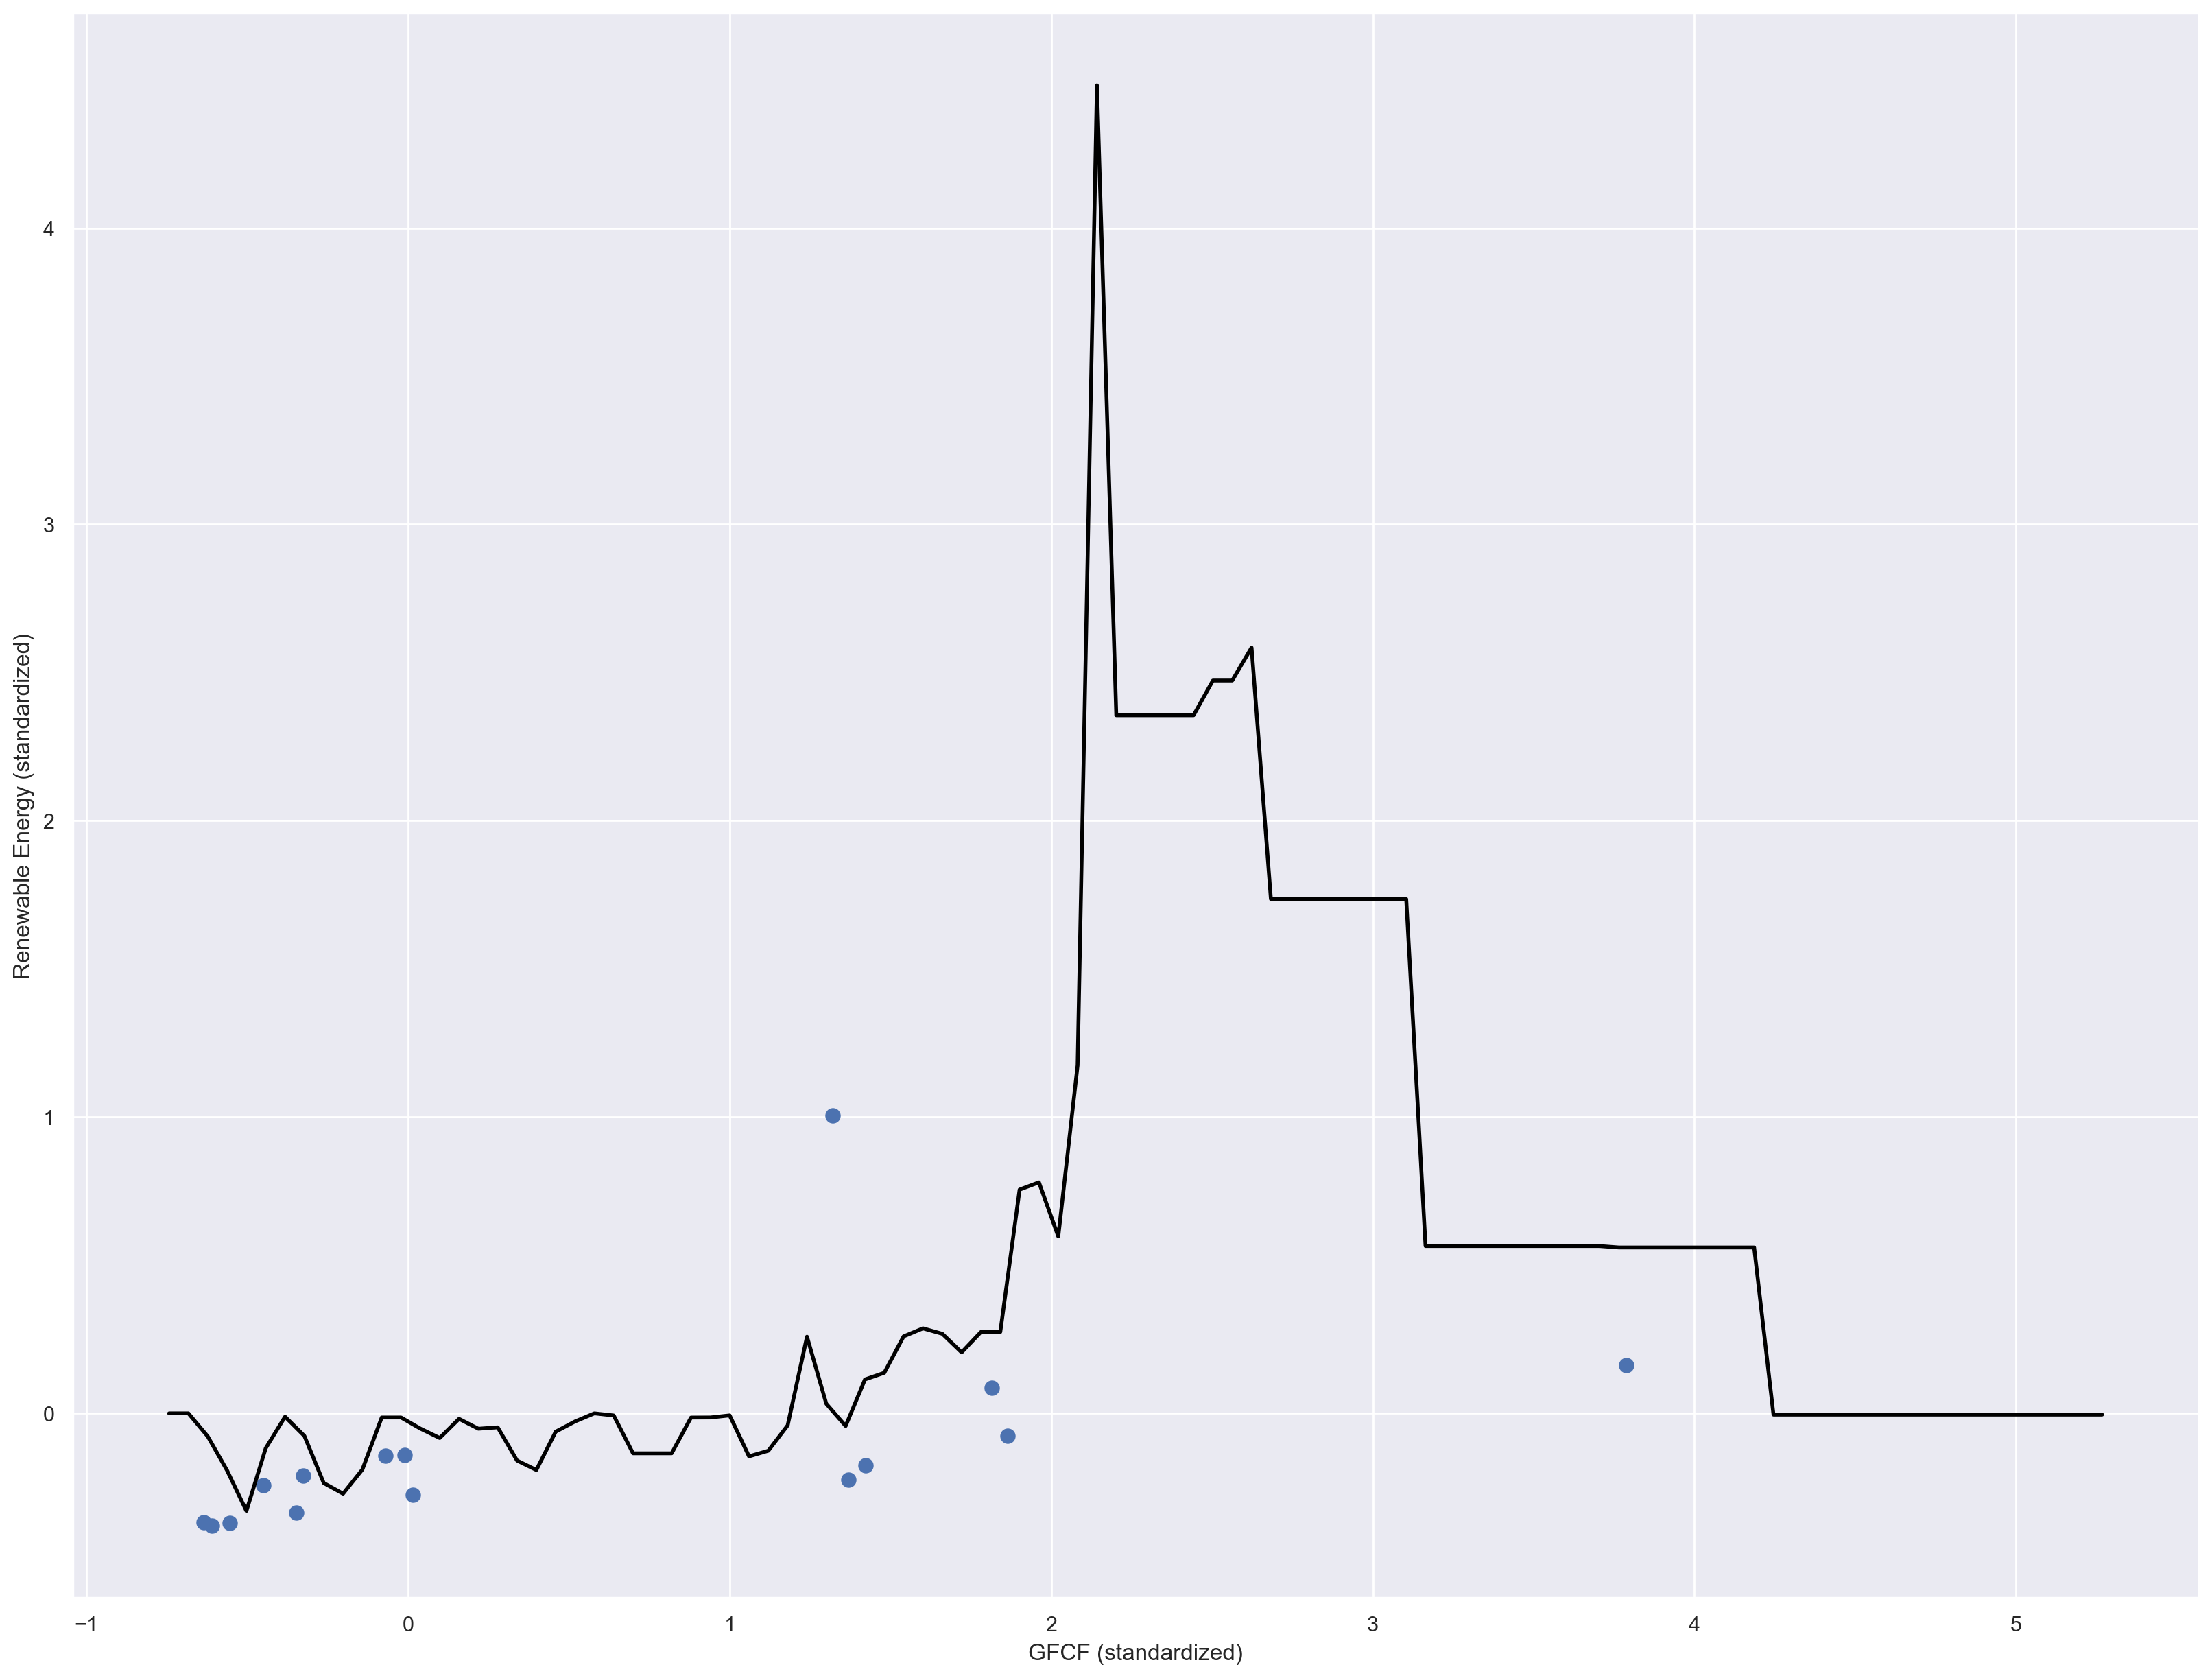

In [150]:
# Find indices of rows with NaN values in ytest_std
nan_indices_rf = np.isnan(ytest_std)

# Remove corresponding rows from Xtest_std and ytest_std
Xtest_std_filtered_rf = Xtest_std[~nan_indices_rf]
ytest_std_filtered_rf = ytest_std[~nan_indices_rf]

# Import the new estimator
from sklearn.ensemble import RandomForestRegressor

# Set its hyperparameters
model_rf = RandomForestRegressor(n_estimators=25)

# Fit it to the training data
model_rf.fit(Xtrain_std, ytrain_std)

# Apply the fit to the filtered test data
ypred_std_filtered_rf = model_rf.predict(Xtest_std_filtered_rf)

# Evaluate the performance on the training data
print(f"R^2 on training data = {model_rf.score(Xtrain_std, ytrain_std):.2f}")

# Evaluate the performance on the filtered test data
print(f"R^2 on filtered test data = {model_rf.score(Xtest_std_filtered_rf, ytest_std_filtered_rf):.2f}")

# Show the fit on the training data
fig = plt.figure();
plt.scatter(Xtrain_std, ytrain_std, s=50);
xVec_rf = np.linspace(Xtrain_std.min(), Xtrain_std.max(), 101)
yVec_rf = model_rf.predict(xVec_rf[:, np.newaxis])
plt.plot(xVec_rf, yVec_rf, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');

# Show the fit on the filtered test data
fig = plt.figure();
plt.scatter(Xtest_std_filtered_rf, ytest_std_filtered_rf, s=50);
plt.plot(xVec_rf, yVec_rf, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');


Reducing the tree complexity to just 2 branches

R^2 on training data = 0.64
R^2 on filtered test data = 0.02


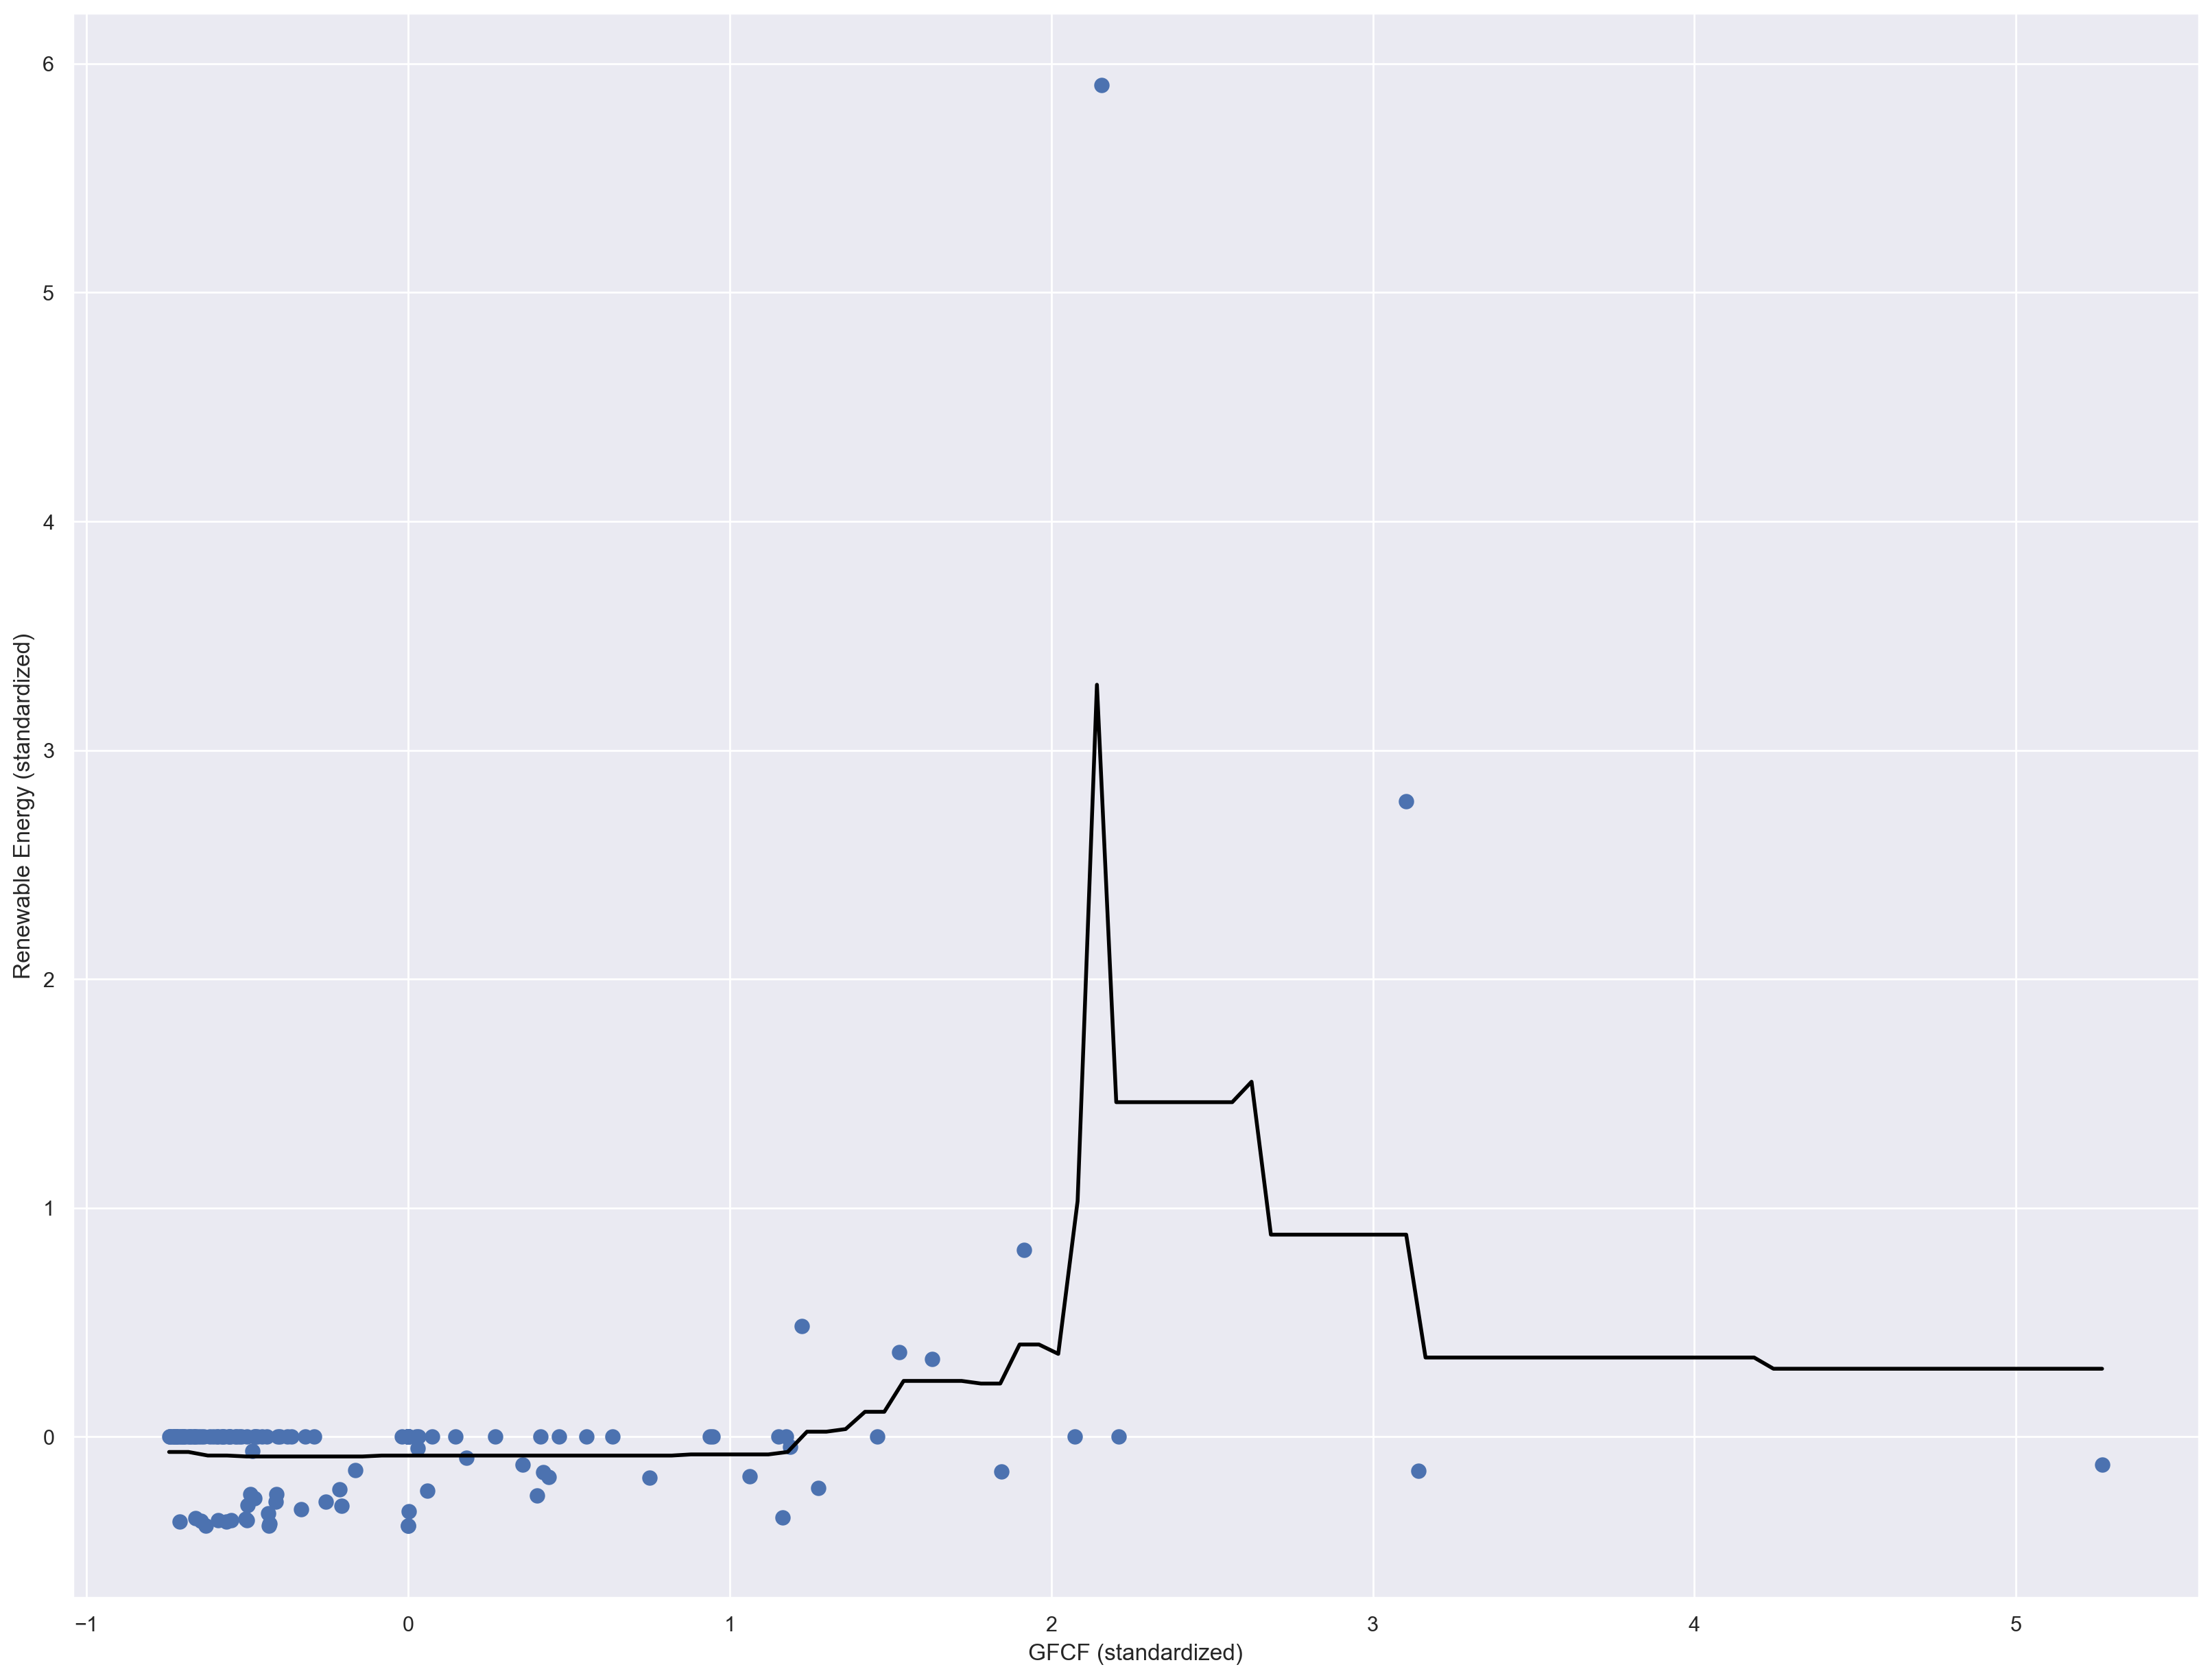

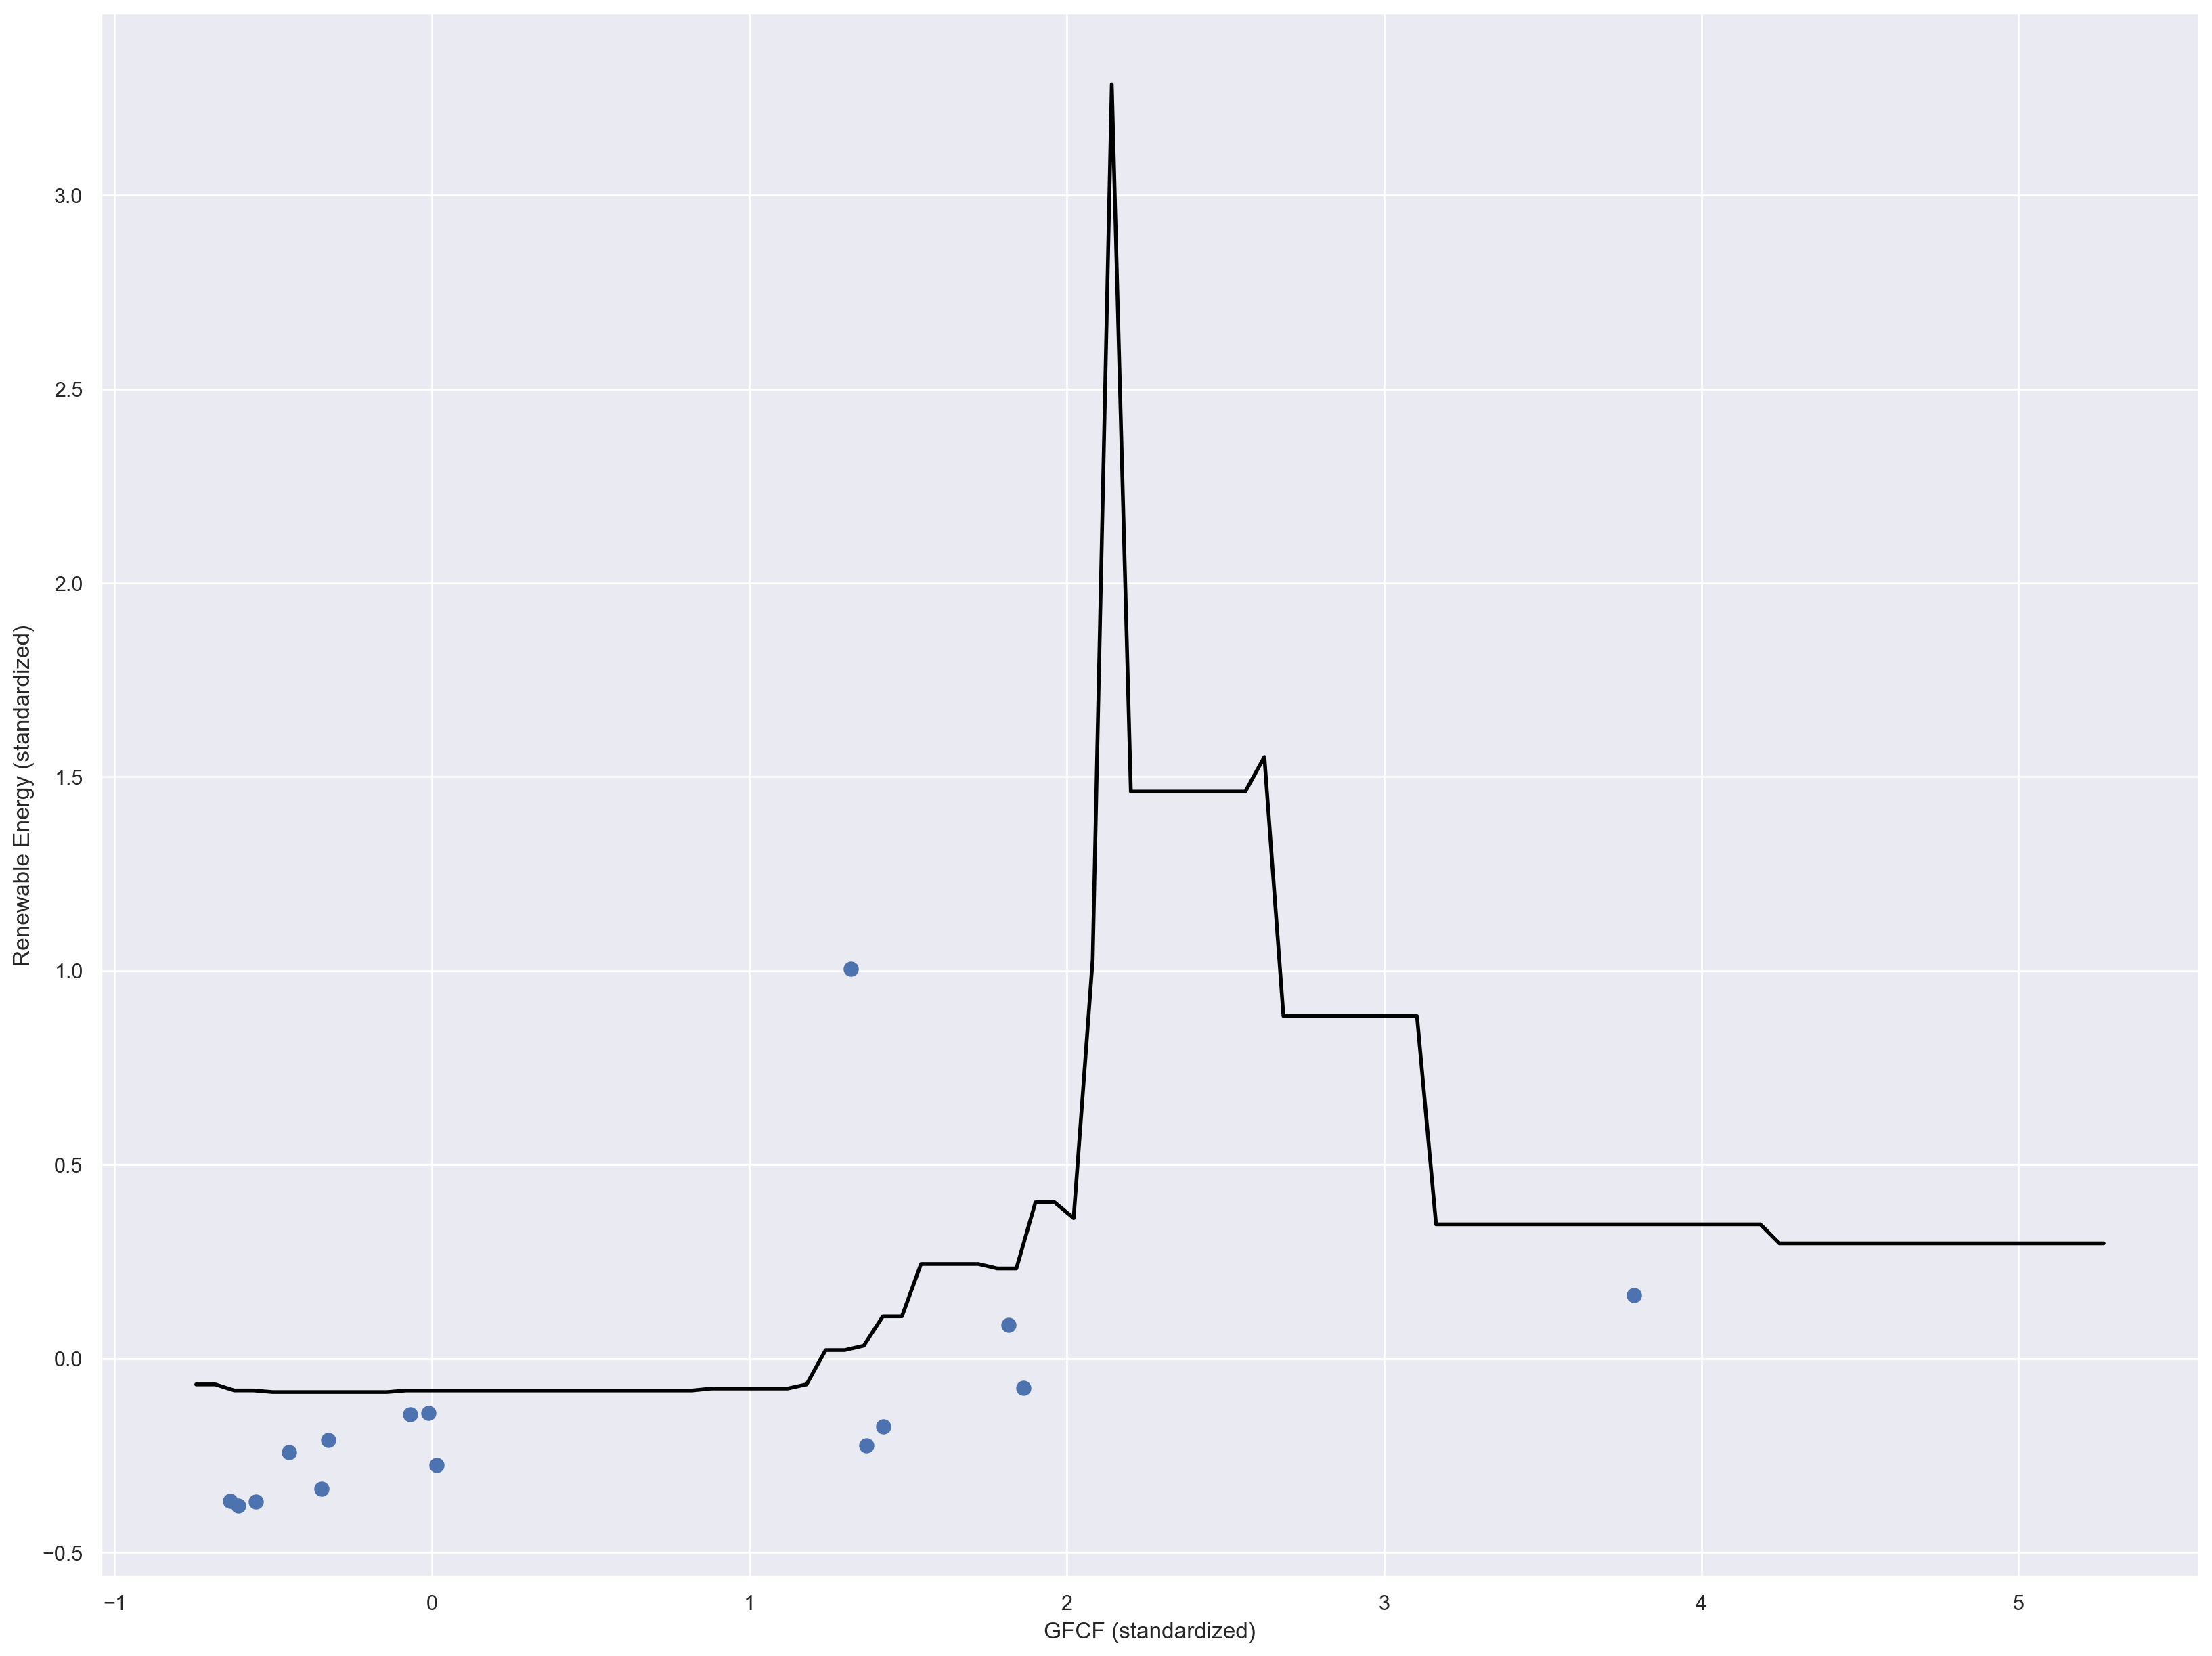

In [151]:
# Find indices of rows with NaN values in ytest_std
nan_indices_rf = np.isnan(ytest_std)

# Remove corresponding rows from Xtest_std and ytest_std
Xtest_std_filtered_rf = Xtest_std[~nan_indices_rf]
ytest_std_filtered_rf = ytest_std[~nan_indices_rf]

# Set new hyperparameters
model_rf = RandomForestRegressor(n_estimators=25, max_depth=2)

# Fit it to the training data
model_rf.fit(Xtrain_std, ytrain_std)

# Apply the fit to the filtered test data
ypred_std_filtered_rf = model_rf.predict(Xtest_std_filtered_rf)

# Evaluate the performance on the training data
print(f"R^2 on training data = {model_rf.score(Xtrain_std, ytrain_std):.2f}")

# Evaluate the performance on the filtered test data
print(f"R^2 on filtered test data = {model_rf.score(Xtest_std_filtered_rf, ytest_std_filtered_rf):.2f}")

# Show the fit on the training data
fig = plt.figure();
plt.scatter(Xtrain_std, ytrain_std, s=50);
xVec_rf = np.linspace(Xtrain_std.min(), Xtrain_std.max(), 101)
yVec_rf = model_rf.predict(xVec_rf[:, np.newaxis])
plt.plot(xVec_rf, yVec_rf, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');

# Show the fit on the filtered test data
fig = plt.figure();
plt.scatter(Xtest_std_filtered_rf, ytest_std_filtered_rf, s=50);
plt.plot(xVec_rf, yVec_rf, c='black', lw=2);
plt.xlabel('GFCF (standardized)');
plt.ylabel('Renewable Energy (standardized)');


# Unsupervised Technique 

## Applying K-Means Clustering

Applying elbow method to get optimal number of cluster(k)

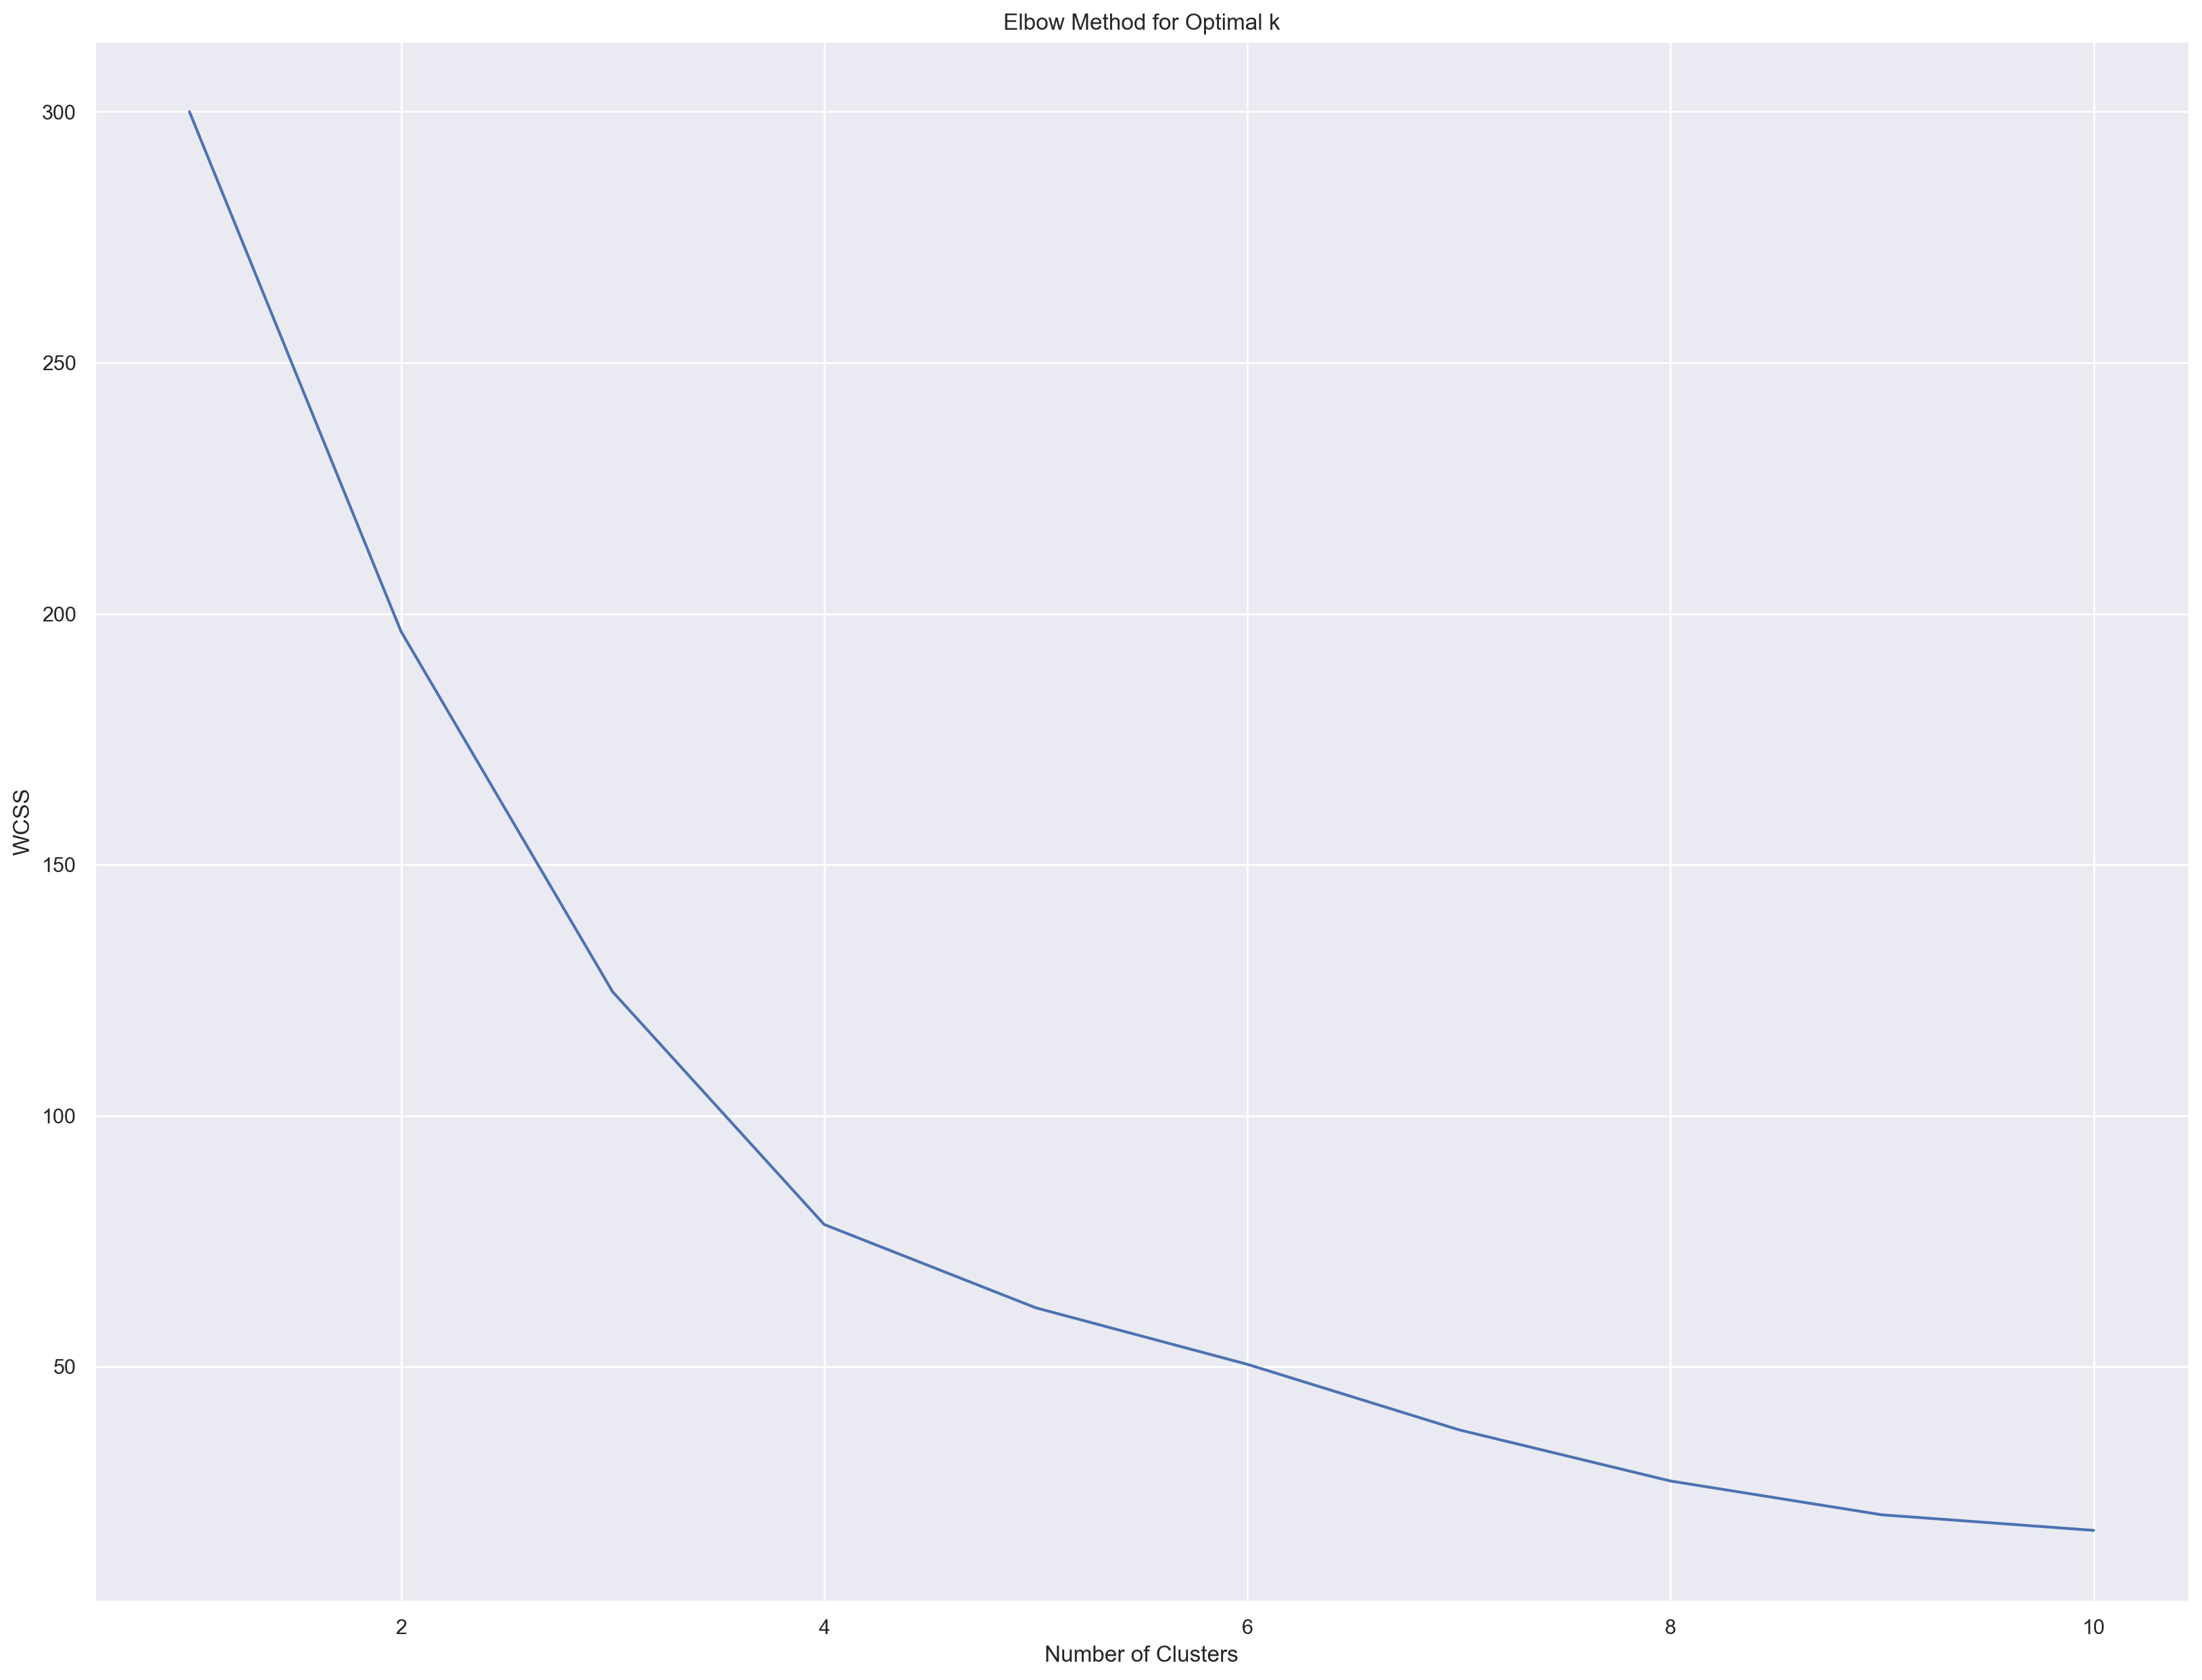

In [153]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features_for_clustering = ['RE_pc', 'GFCF_pc', 'NRE_pc', 'AE_pc', 'ED_ÎœW_PC']  # Update the column name
data_for_clustering = Primary_variables[features_for_clustering]

# Drop rows with NaN values
data_for_clustering = data_for_clustering.dropna()

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

# Find optimal number of clusters (K) using the Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


Clusters

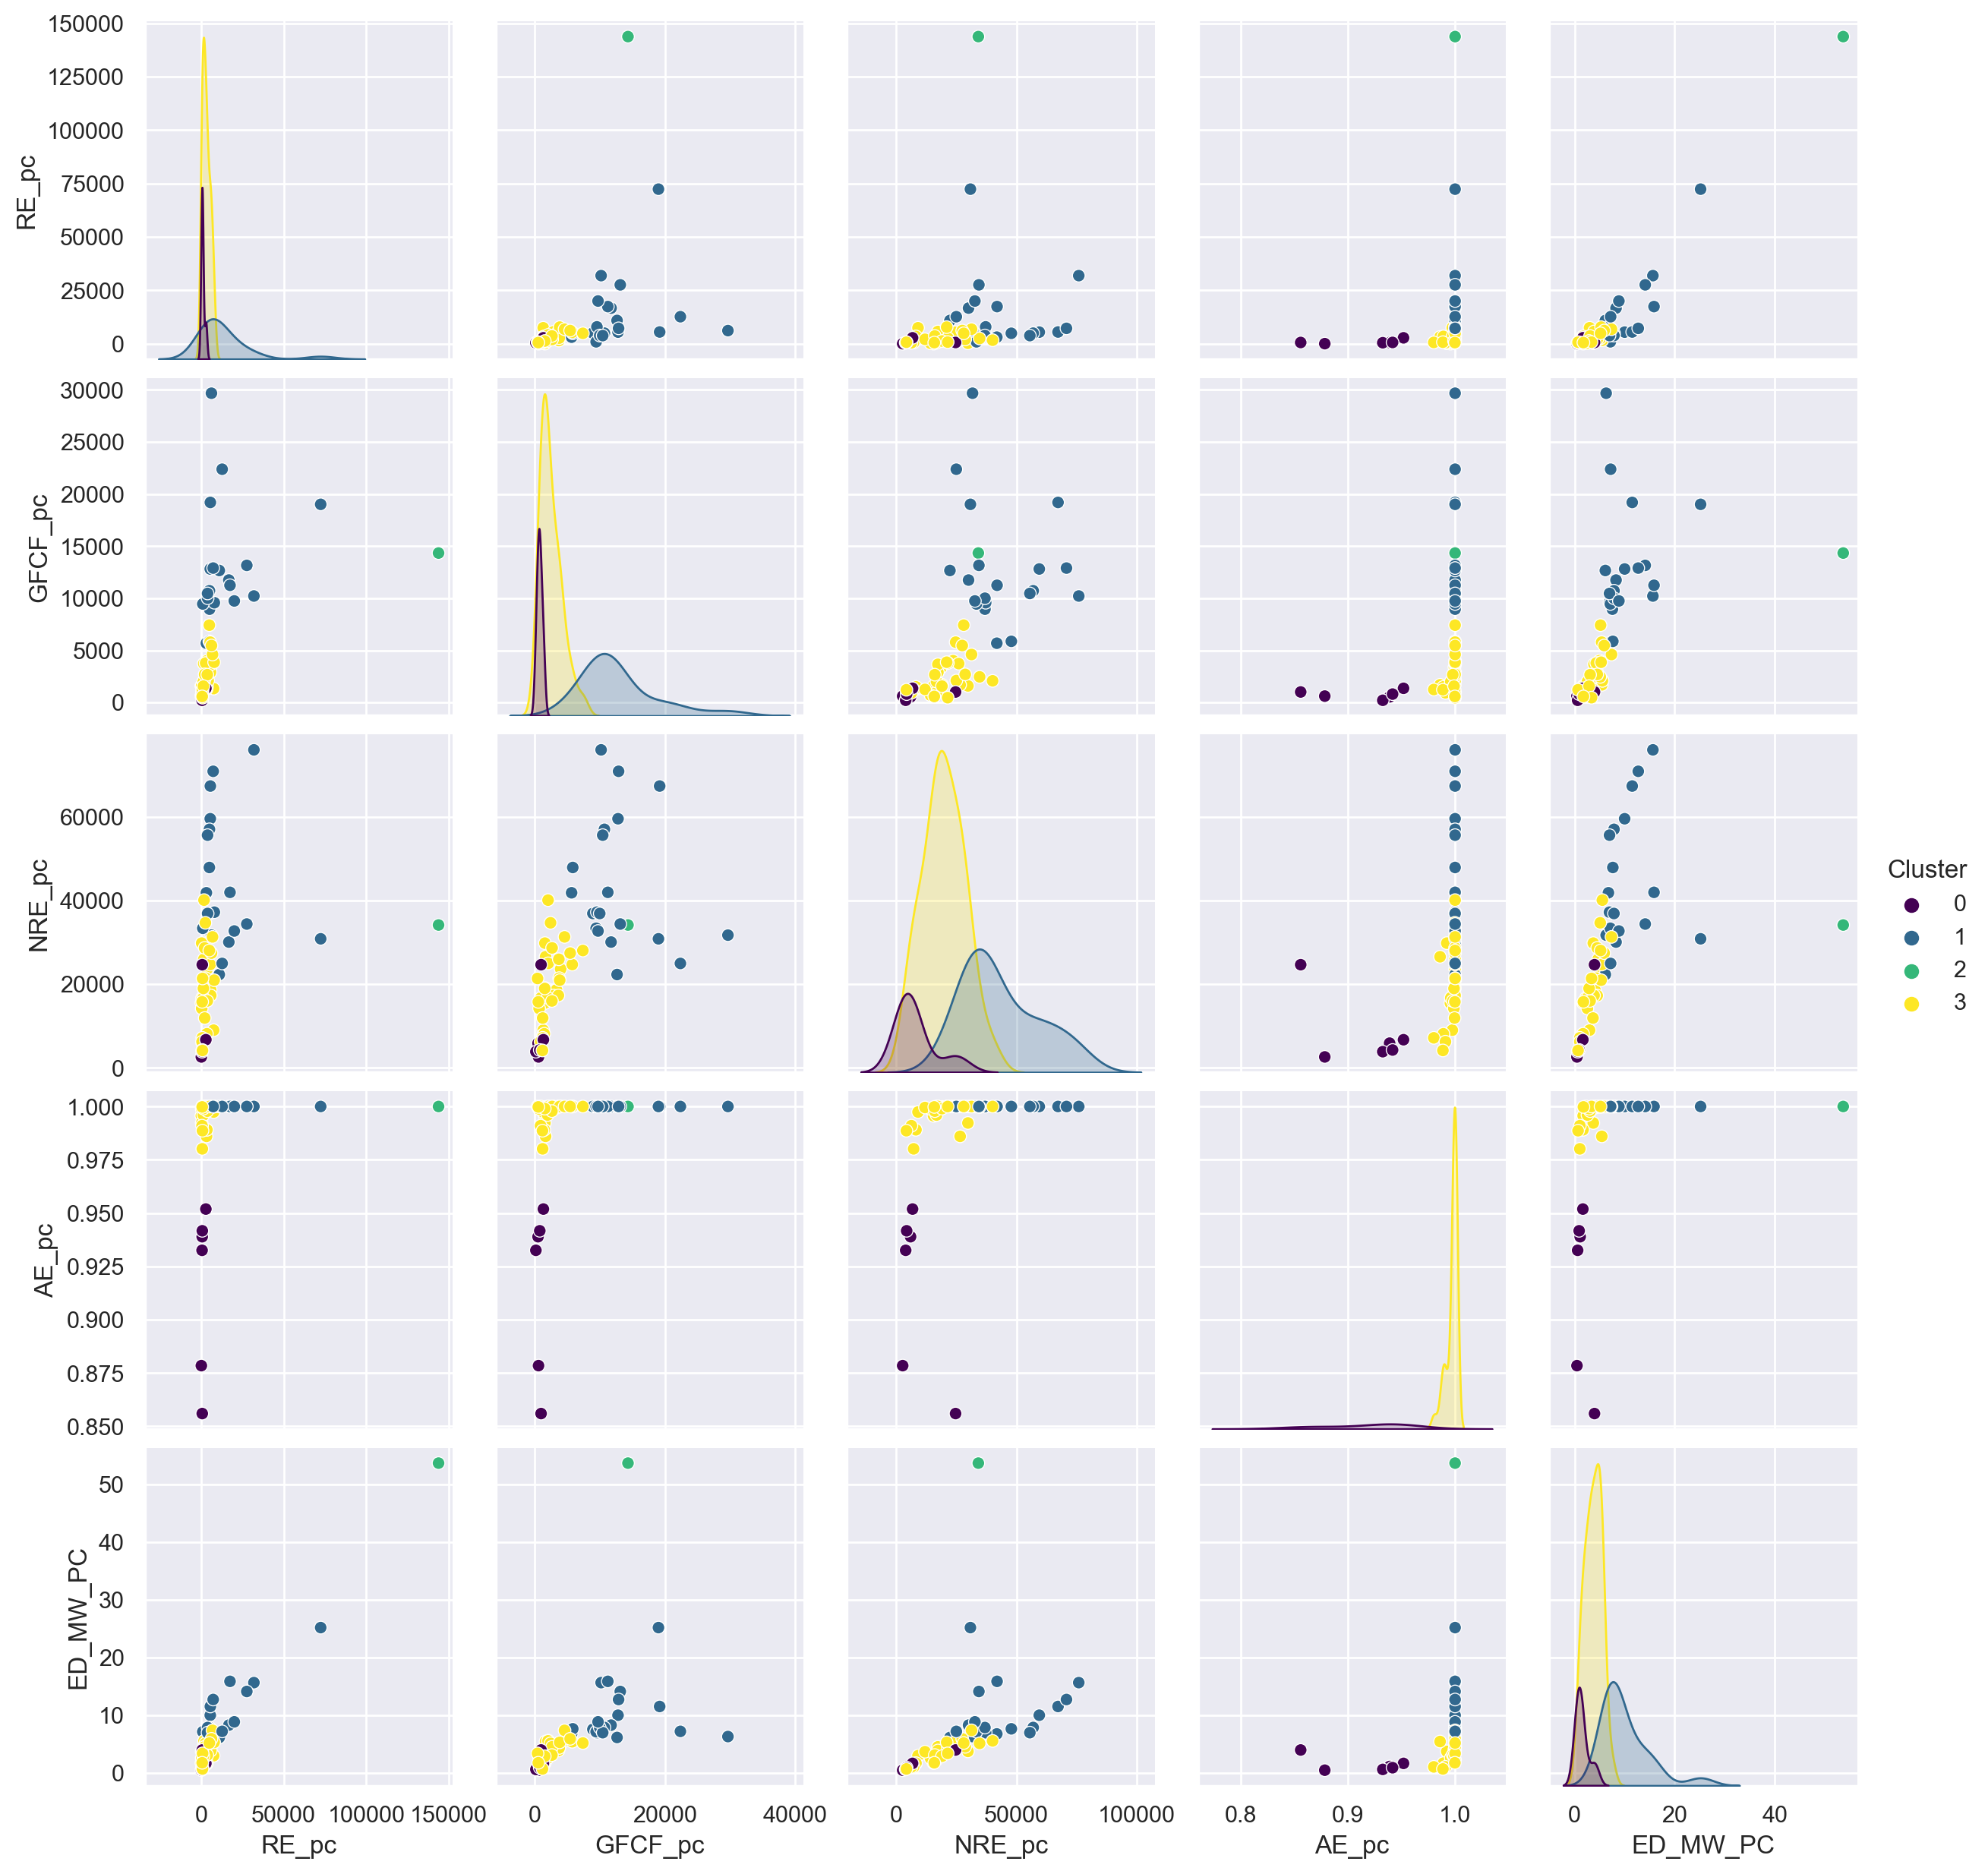

In [154]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features_for_clustering = ['RE_pc', 'GFCF_pc', 'NRE_pc', 'AE_pc', 'ED_ÎœW_PC']  # Update the column name
data_for_clustering = Primary_variables[features_for_clustering]

# Drop rows with NaN values
data_for_clustering = data_for_clustering.dropna()

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)


# Choose the number of clusters (K) based on the "elbow" point
k = 4

# Fit K-Means model
kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to the data
data_for_clustering['Cluster'] = clusters

# Visualize the clusters
sns.pairplot(data_for_clustering, hue='Cluster', vars=features_for_clustering, palette='viridis')
plt.show()
